In [1]:
import streamlit as st
import datetime as dt
from utils.weather import get_weather
from spotify_loader import load_spotify_data
import os
import requests
from dotenv import load_dotenv
import pandas as pd 
import numpy  as np
import matplotlib.pyplot as plt
import statistics as st
import seaborn as sns
# from utils.spotify_data import load_spotify_data, get_today_songs
# from utils.spotify_genre import get_artist_genre


In [2]:
from api_key import Weather_API

In [410]:
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("API_KEY")

In [3]:
# Replace with your actual file path
weather_df = pd.read_csv('merged_weather_data.csv')

In [4]:
print(weather_df['city'].unique())


['Tokyo' 'Lagos' 'New York' 'London' 'Berlin']


In [273]:
weather_df.columns

Index(['city', 'datetime', 'tempmax', 'tempmin', 'temp', 'feelslikemax',
       'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
       'precipcover', 'preciptype', 'snow', 'snowdepth', 'windgust',
       'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility',
       'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'sunrise',
       'sunset', 'moonphase', 'conditions', 'description', 'icon', 'stations',
       'city.1', 'clothing_recommendation', 'season', 'sunrise_hour',
       'sunset_hour', 'datetime_hour', 'month', 'date'],
      dtype='object')

In [274]:
# Assuming the 'date' column exists in the format 'YYYY-MM-DD' or similar
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])  # Convert to datetime if not already
weather_df['month'] = weather_df['datetime'].dt.month_name()  # Extract the month name

# Check the new 'month' column
print(weather_df.head())


    city   datetime  tempmax  tempmin  temp  feelslikemax  feelslikemin  \
0  Tokyo 2023-10-01     83.8     74.4  78.5          90.1          74.4   
1  Tokyo 2023-10-02     79.2     68.8  74.2          79.2          68.8   
2  Tokyo 2023-10-03     79.7     65.2  72.8          79.7          65.2   
3  Tokyo 2023-10-04     72.8     63.8  66.3          72.8          63.8   
4  Tokyo 2023-10-05     77.1     63.1  68.2          77.1          63.1   

   feelslike   dew  humidity  ...               icon  \
0       79.4  71.5      79.5  ...               rain   
1       74.2  58.0      58.4  ...               rain   
2       72.8  53.9      52.4  ...  partly-cloudy-day   
3       66.3  63.8      92.1  ...               rain   
4       68.2  59.8      77.7  ...               rain   

                                            stations   city.1  \
0  47662099999,47670099999,47642043313,4762609999...  Unknown   
1  47662099999,47670099999,47642043313,4768009999...  Unknown   
2  47662099999,47

In [275]:
import pandas as pd
from datetime import timedelta

# Ensure 'datetime' column is in datetime format
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])

# Extract only the date (no time part) into a new column
weather_df['date'] = weather_df['datetime'].dt.date

# Find the most recent date in your dataset
latest_date = weather_df['date'].max()

# Convert to a pandas Timestamp
latest_date = pd.to_datetime(latest_date)

# Find the most recent *full* week ending on Sunday
# If today is not Sunday, roll back to the most recent one
days_since_sunday = (latest_date.weekday() + 1) % 7
last_sunday = latest_date - timedelta(days=days_since_sunday)

# Get Monday of that same week
last_monday = last_sunday - timedelta(days=6)

# Filter the dataframe to that full week
mask = (weather_df['datetime'].dt.date >= last_monday.date()) & \
       (weather_df['datetime'].dt.date <= last_sunday.date())
weather_last_week = weather_df[mask]

print(f"Most recent full week: {last_monday.date()} to {last_sunday.date()}")
print(weather_last_week.head())

Most recent full week: 2025-04-07 to 2025-04-13
       city   datetime  tempmax  tempmin  temp  feelslikemax  feelslikemin  \
2396  Tokyo 2025-04-07     63.7     52.3  57.5          63.7          52.3   
2397  Tokyo 2025-04-08     67.4     48.2  58.7          67.4          47.5   
2398  Tokyo 2025-04-09     72.3     53.8  61.1          72.3          53.8   
2399  Tokyo 2025-04-10     68.5     54.5  60.8          68.5          54.5   
2400  Tokyo 2025-04-11     65.4     57.1  60.9          65.4          57.1   

      feelslike   dew  humidity  ...               icon  \
2396       57.5  46.7      69.1  ...               rain   
2397       58.6  42.5      55.5  ...               rain   
2398       61.1  42.2      54.6  ...  partly-cloudy-day   
2399       60.8  51.8      72.7  ...               rain   
2400       60.9  54.1      78.4  ...               rain   

                      stations   city.1  \
2396  RJTY,RJTI,RJTF,RJTT,RJAA  Unknown   
2397  RJTY,RJTI,RJTF,RJTT,RJAA  Unknown   

In [276]:
# 💾 Save back to CSV
weather_df.to_csv("merged_weather_data.csv", index=False)


In [279]:
spotify_df.to_csv('spotify_streaming_cleaned.csv', index=False)

In [6]:
# Drop the 'name' column if it exists
if 'city.1' in weather_df.columns:
    merged_weather_df = weather_df.drop(columns=['city.1'])
    print("✅ 'city.1' column dropped.")
else:
    print("ℹ️ No 'city.1' column found to drop.")


✅ 'city.1' column dropped.


In [269]:
# Basic info
print("\nℹ️ Data Info:")
print(weather_df.info())


ℹ️ Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2821 entries, 0 to 2820
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   city                     2821 non-null   object        
 1   datetime                 2821 non-null   datetime64[ns]
 2   tempmax                  2821 non-null   float64       
 3   tempmin                  2821 non-null   float64       
 4   temp                     2821 non-null   float64       
 5   feelslikemax             2821 non-null   float64       
 6   feelslikemin             2821 non-null   float64       
 7   feelslike                2821 non-null   float64       
 8   dew                      2821 non-null   float64       
 9   humidity                 2821 non-null   float64       
 10  precip                   2821 non-null   float64       
 11  precipprob               2821 non-null   float64       
 12  precipcover        

In [270]:
# Descriptive statistics
print("\n📊 Summary Stats:")
print(weather_df.describe(include='all'))


📊 Summary Stats:
         city                       datetime      tempmax      tempmin  \
count    2821                           2821  2821.000000  2821.000000   
unique      5                            NaN          NaN          NaN   
top     Tokyo                            NaN          NaN          NaN   
freq      565                            NaN          NaN          NaN   
mean      NaN  2024-07-07 22:59:15.334987520    66.994470    53.845587   
min       NaN            2023-10-01 00:00:00    19.300000    11.300000   
25%       NaN            2024-02-19 00:00:00    52.100000    40.200000   
50%       NaN            2024-07-09 00:00:00    64.100000    51.000000   
75%       NaN            2024-11-25 00:00:00    86.000000    71.900000   
max       NaN            2025-04-15 00:00:00   100.400000    83.400000   
std       NaN                            NaN    18.573272    16.802434   

               temp  feelslikemax  feelslikemin    feelslike          dew  \
count   2821.000

In [271]:
# Step 1: Check for missing values
print("\n❓ Missing Values (Before):")
print(weather_df.isnull().sum())

# Step 2: Fill missing numeric columns with mean
numeric_cols = weather_df.select_dtypes(include='number').columns
weather_df[numeric_cols] = weather_df[numeric_cols].fillna(weather_df[numeric_cols].mean())

# Step 3: Fill missing string/object columns with 'Unknown'
object_cols = weather_df.select_dtypes(include='object').columns
weather_df[object_cols] = weather_df[object_cols].fillna("Unknown")

# Step 4: Re-check for missing values
print("\n✅ Missing Values (After Fill):")
print(weather_df.isnull().sum())


❓ Missing Values (Before):
city                       0
datetime                   0
tempmax                    0
tempmin                    0
temp                       0
feelslikemax               0
feelslikemin               0
feelslike                  0
dew                        0
humidity                   0
precip                     0
precipprob                 0
precipcover                0
preciptype                 0
snow                       0
snowdepth                  0
windgust                   0
windspeed                  0
winddir                    0
sealevelpressure           0
cloudcover                 0
visibility                 0
solarradiation             0
solarenergy                0
uvindex                    0
severerisk                 0
sunrise                    0
sunset                     0
moonphase                  0
conditions                 0
description                0
icon                       0
stations                   0
city.1         

In [ ]:
merged_weather_df[['datetime', 'city', 'temp', 'clothing_recommendation']].head()


,datetime,city,temp,clothing_recommendation
0,2023-10-01,Tokyo,78.5,"🩳 Shorts, tank top, hat, sunglasses ☔ (Umbrell..."
1,2023-10-02,Tokyo,74.2,"🩳 Shorts, tank top, hat, sunglasses ☔ (Umbrell..."
2,2023-10-03,Tokyo,72.8,"👕 T-shirt, jeans/skirt, light sneakers 🕶️ (Sun..."
3,2023-10-04,Tokyo,66.3,"👕 T-shirt, jeans/skirt, light sneakers ☔ (Umbr..."
4,2023-10-05,Tokyo,68.2,"👕 T-shirt, jeans/skirt, light sneakers ☔ (Umbr..."


# Adding Season Column

In [12]:
import pandas as pd

def add_season_column(weather_df, date_column='datetime'):
    """
    Adds a 'season' column based on the month in a datetime column.
    Assumes Northern Hemisphere seasons.
    """
    def get_season(month):
        if month in [12, 1, 2]:
            return "Winter"
        elif month in [3, 4, 5]:
            return "Spring"
        elif month in [6, 7, 8]:
            return "Summer"
        elif month in [9, 10, 11]:
            return "Autumn"

    # Ensure datetime column is in datetime format
    weather_df[date_column] = pd.to_datetime(weather_df[date_column], errors='coerce')

    # Apply the season logic
    weather_df['season'] = weather_df[date_column].dt.month.apply(get_season)

    return weather_df

# 🧠 Load your CSV
weather_df = pd.read_csv("merged_weather_data.csv")

# 🍁 Add season info
weather_df = add_season_column(weather_df)

# 💾 Save back to CSV
weather_df.to_csv("merged_weather_data.csv", index=False)



In [14]:
# Convert sunrise and sunset to datetime.time format if they're strings
weather_df['sunrise'] = pd.to_datetime(weather_df['sunrise'], errors='coerce').dt.time
weather_df['sunset'] = pd.to_datetime(weather_df['sunset'], errors='coerce').dt.time

In [15]:
# Convert time objects to datetime and extract hour
weather_df['sunrise_hour'] = pd.to_datetime(weather_df['sunrise'], format='%H:%M:%S', errors='coerce').dt.hour
weather_df['sunset_hour'] = pd.to_datetime(weather_df['sunset'], format='%H:%M:%S', errors='coerce').dt.hour

In [16]:
weather_df['sunrise_hour'] = weather_df['sunrise'].apply(lambda x: x.hour if pd.notnull(x) else None)
weather_df['sunset_hour'] = weather_df['sunset'].apply(lambda x: x.hour if pd.notnull(x) else None)

In [25]:
# Ensure 'temp' column has valid numeric values
weather_df['temp'] = pd.to_numeric(weather_df['temp'], errors='coerce')

# Drop rows where temp is NaN (optional but helps avoid errors)
weather_df = weather_df.dropna(subset=['temp'])

# Find the hottest day
hottest_day = weather_df.loc[weather_df['temp'].idxmax()]
print("🔥 Hottest Day Overall:")
print(hottest_day)


🔥 Hottest Day Overall:
city                                                                   Lagos
datetime                                                 2024-04-20 00:00:00
tempmax                                                                 95.3
tempmin                                                                 83.4
temp                                                                    88.3
feelslikemax                                                           115.8
feelslikemin                                                            95.6
feelslike                                                              104.1
dew                                                                     79.7
humidity                                                                76.6
precip                                                                   0.0
precipprob                                                               0.0
precipcover                                          

In [26]:
coldest_day = weather_df.loc[weather_df['temp'].idxmin()]
print("❄️ Coldest Day Overall:")
print(coldest_day[['datetime', 'temp', 'city', 'conditions', 'clothing_recommendation']])



❄️ Coldest Day Overall:
datetime                                         2025-01-21 00:00:00
temp                                                            15.9
city                                                        New York
conditions                                          Partially cloudy
clothing_recommendation    🧥 Heavy coat, thermal wear, gloves, boots
Name: 2529, dtype: object


In [27]:
# Filter for Berlin only
berlin_weather = weather_df[weather_df['city'] == 'Berlin']

# Find the row with the lowest temperature
coldest_day = berlin_weather.loc[berlin_weather['temp'].idxmin()]

# Display the result
print("❄️ Coldest Day in Berlin:")
print(coldest_day[['datetime', 'temp', 'conditions', 'description', 'clothing_recommendation']])


❄️ Coldest Day in Berlin:
datetime                                         2024-01-09 00:00:00
temp                                                            18.1
conditions                                                     Clear
description                     Clear conditions throughout the day.
clothing_recommendation    🧥 Heavy coat, thermal wear, gloves, boots
Name: 832, dtype: object


In [28]:
hottest_berlin = weather_df[weather_df['city'] == 'Berlin'].loc[
    weather_df[weather_df['city'] == 'Berlin']['temp'].idxmax()
]

print("🔥 Hottest Day in Berlin:")
print(hottest_berlin[['datetime', 'temp', 'conditions', 'clothing_recommendation']])


🔥 Hottest Day in Berlin:
datetime                                                 2024-08-29 00:00:00
temp                                                                    79.7
conditions                                                             Clear
clothing_recommendation    🩳 Shorts, tank top, hat, sunglasses 🕶️ (Sunscr...
Name: 1865, dtype: object


In [29]:
# Make sure 'precip' is numeric
weather_df['precip'] = pd.to_numeric(weather_df['precip'], errors='coerce')

# Drop rows with NaN in 'precip'
rain_data = weather_df.dropna(subset=['precip'])

# Find the most rainy day
most_rainy_day = rain_data.loc[rain_data['precip'].idxmax()]

# Display result
print("🌧️ Most Rainy Day:")
print(most_rainy_day[['datetime', 'city', 'precip', 'conditions', 'clothing_recommendation']])


🌧️ Most Rainy Day:
datetime                                                 2024-07-03 00:00:00
city                                                                   Lagos
precip                                                                 6.142
conditions                                            Rain, Partially cloudy
clothing_recommendation    🩳 Shorts, tank top, hat, sunglasses ☔ (Umbrell...
Name: 1008, dtype: object


In [30]:
# Ensure 'precip' is numeric
weather_df['precip'] = pd.to_numeric(weather_df['precip'], errors='coerce')

# Filter for Berlin only
berlin_data = weather_df[merged_weather_df['city'].str.lower().str.strip() == 'berlin']

# Drop NaNs in precip
berlin_data = berlin_data.dropna(subset=['precip'])

# Get the most rainy day in Berlin
most_rainy_berlin = berlin_data.loc[berlin_data['precip'].idxmax()]

# Display
print("🌧️ Most Rainy Day in Berlin:")
print(most_rainy_berlin[['datetime', 'precip', 'conditions', 'clothing_recommendation']])


🌧️ Most Rainy Day in Berlin:
datetime                                                 2024-07-28 00:00:00
precip                                                                 1.163
conditions                                            Rain, Partially cloudy
clothing_recommendation    👕 T-shirt, jeans/skirt, light sneakers ☔ (Umbr...
Name: 1833, dtype: object


In [31]:
# Filter Berlin data
berlin_data = weather_df[weather_df['city'].str.lower().str.strip() == 'berlin']

# Ensure 'precip' is numeric
berlin_data['precip'] = pd.to_numeric(berlin_data['precip'], errors='coerce')

# Filter rows with snow in the condition
snow_days = berlin_data[berlin_data['conditions'].str.lower().str.contains('snow', na=False)]

# Drop rows with missing precip
snow_days = snow_days.dropna(subset=['precip'])

# Get the snow day with the highest precipitation
most_snowed_day = snow_days.loc[snow_days['precip'].idxmax()]

# Display
print("❄️ Most Snowed Day in Berlin:")
print(most_snowed_day[['datetime', 'precip', 'conditions', 'clothing_recommendation']])


❄️ Most Snowed Day in Berlin:
datetime                                                 2024-11-19 00:00:00
precip                                                                 0.834
conditions                                              Snow, Rain, Overcast
clothing_recommendation    🧥 Heavy coat, thermal wear, gloves, boots ☔ (U...
Name: 2257, dtype: object


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/9326004.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  berlin_data['precip'] = pd.to_numeric(berlin_data['precip'], errors='coerce')


In [32]:
# Filter Berlin data
berlin_data = weather_df[weather_df['city'].str.lower().str.strip() == 'berlin']

# Ensure windspeed column is numeric
berlin_data['windspeed'] = pd.to_numeric(berlin_data['windspeed'], errors='coerce')

# Drop rows with missing windspeed
berlin_data = berlin_data.dropna(subset=['windspeed'])

# Find the row with the highest windspeed
most_windy_day = berlin_data.loc[berlin_data['windspeed'].idxmax()]

# Display the result
print("💨 Most Windy Day in Berlin:")
print(most_windy_day[['datetime', 'windspeed', 'conditions', 'clothing_recommendation']])


💨 Most Windy Day in Berlin:
datetime                                                 2024-01-24 00:00:00
windspeed                                                               27.3
conditions                                            Rain, Partially cloudy
clothing_recommendation    🧥 Coat or insulated jacket, boots ☔ (Umbrella ...
Name: 847, dtype: object


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/1220974638.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  berlin_data['windspeed'] = pd.to_numeric(berlin_data['windspeed'], errors='coerce')


In [33]:
# Filter lagos data
berlin_data = weather_df[weather_df['city'].str.lower().str.strip() == 'lagos']

# Ensure windspeed column is numeric
berlin_data['windspeed'] = pd.to_numeric(berlin_data['windspeed'], errors='coerce')

# Drop rows with missing windspeed
berlin_data = berlin_data.dropna(subset=['windspeed'])

# Find the row with the highest windspeed
most_windy_day = berlin_data.loc[berlin_data['windspeed'].idxmax()]

# Display the result
print("💨 Most Windy Day in Lagos:")
print(most_windy_day[['datetime', 'windspeed', 'conditions', 'clothing_recommendation']])

💨 Most Windy Day in Lagos:
datetime                                                 2025-02-16 00:00:00
windspeed                                                               86.3
conditions                                            Rain, Partially cloudy
clothing_recommendation    🩳 Sleeveless, linen, sandals, drink water! ☔ (...
Name: 2451, dtype: object


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/1486708637.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  berlin_data['windspeed'] = pd.to_numeric(berlin_data['windspeed'], errors='coerce')


In [34]:
# Ensure datetime is in datetime format
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'], errors='coerce')

# Filter Berlin and summer months (June, July, August)
summer_berlin = weather_df[
    (weather_df['city'].str.lower().str.strip() == 'berlin') &
    (weather_df['datetime'].dt.month.isin([6, 7, 8]))
]

# Get unique clothing recommendations
summer_recommendations = summer_berlin['clothing_recommendation'].dropna().unique()

print("👕 Clothing Recommendations for Summer in Berlin:")
for rec in summer_recommendations:
    print(f"- {rec}")


👕 Clothing Recommendations for Summer in Berlin:
- 👕 T-shirt, jeans/skirt, light sneakers ☔ (Umbrella recommended) 🕶️ (Sunscreen & sunglasses)
- 👕 T-shirt, jeans/skirt, light sneakers 🕶️ (Sunscreen & sunglasses)
- 🧶 Hoodie or light jacket, jeans
- 🧶 Hoodie or light jacket, jeans 🕶️ (Sunscreen & sunglasses)
- 🧶 Hoodie or light jacket, jeans ☔ (Umbrella recommended)
- 🧶 Hoodie or light jacket, jeans ☔ (Umbrella recommended) 🕶️ (Sunscreen & sunglasses)
- 🩳 Shorts, tank top, hat, sunglasses 🕶️ (Sunscreen & sunglasses)
- 🩳 Shorts, tank top, hat, sunglasses ☔ (Umbrella recommended) 🕶️ (Sunscreen & sunglasses)
- 👕 T-shirt, jeans/skirt, light sneakers ☔ (Umbrella recommended)
- 👕 T-shirt, jeans/skirt, light sneakers


In [35]:
# Ensure datetime is in datetime format
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'], errors='coerce')

# Filter Berlin and summer months (June, July, August)
summer_berlin = merged_weather_df[
    (weather_df['city'].str.lower().str.strip() == 'lagos') &
    (weather_df['datetime'].dt.month.isin([6, 7, 8]))
]

# Get unique clothing recommendations
summer_recommendations = summer_berlin['clothing_recommendation'].dropna().unique()

print("👕 Clothing Recommendations for Summer in Lagos:")
for rec in summer_recommendations:
    print(f"- {rec}")

👕 Clothing Recommendations for Summer in Lagos:
- 🩳 Sleeveless, linen, sandals, drink water! 🕶️ (Sunscreen & sunglasses)
- 🩳 Shorts, tank top, hat, sunglasses ☔ (Umbrella recommended)
- 🩳 Sleeveless, linen, sandals, drink water! ☔ (Umbrella recommended) 🕶️ (Sunscreen & sunglasses)
- 🩳 Sleeveless, linen, sandals, drink water! ☔ (Umbrella recommended)
- 🩳 Shorts, tank top, hat, sunglasses ☔ (Umbrella recommended) 🕶️ (Sunscreen & sunglasses)
- 🩳 Shorts, tank top, hat, sunglasses
- 🩳 Shorts, tank top, hat, sunglasses 🕶️ (Sunscreen & sunglasses)


In [36]:
# Ensure datetime column is in datetime format
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'], errors='coerce')

# Filter for Berlin in spring months: March, April, May
spring_berlin = weather_df[
    (weather_df['city'].str.lower().str.strip() == 'berlin') &
    (weather_df['datetime'].dt.month.isin([3, 4, 5]))
]

# Drop missing clothing recommendations
spring_recommendations = spring_berlin['clothing_recommendation'].dropna().unique()

# Display
print("🌸 Clothing Recommendations for Spring in Berlin:")
for rec in spring_recommendations:
    print(f"- {rec}")


🌸 Clothing Recommendations for Spring in Berlin:
- 🧥 Coat or insulated jacket, boots
- 🧥 Coat or insulated jacket, boots ☔ (Umbrella recommended)
- 🧶 Hoodie or light jacket, jeans
- 🧥 Coat or insulated jacket, boots 🕶️ (Sunscreen & sunglasses)
- 🧥 Heavy coat, thermal wear, gloves, boots 🕶️ (Sunscreen & sunglasses)
- 🧶 Hoodie or light jacket, jeans ☔ (Umbrella recommended) 🕶️ (Sunscreen & sunglasses)
- 🧶 Hoodie or light jacket, jeans 🕶️ (Sunscreen & sunglasses)
- 🧥 Coat or insulated jacket, boots ☔ (Umbrella recommended) 🕶️ (Sunscreen & sunglasses)
- 🧥 Heavy coat, thermal wear, gloves, boots ☔ (Umbrella recommended)
- 🧶 Hoodie or light jacket, jeans ☔ (Umbrella recommended)
- 👕 T-shirt, jeans/skirt, light sneakers 🕶️ (Sunscreen & sunglasses)
- 👕 T-shirt, jeans/skirt, light sneakers ☔ (Umbrella recommended) 🕶️ (Sunscreen & sunglasses)
- 🧥 Heavy coat, thermal wear, gloves, boots
- 🧥 Heavy coat, thermal wear, gloves, boots ☔ (Umbrella recommended) 🕶️ (Sunscreen & sunglasses)


In [37]:
# Ensure datetime column is in datetime format
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'], errors='coerce')

# Filter for Lagos in spring months: March, April, May
spring_berlin = weather_df[
    (weather_df['city'].str.lower().str.strip() == 'lagos') &
    (weather_df['datetime'].dt.month.isin([3, 4, 5]))
]

# Drop missing clothing recommendations
spring_recommendations = spring_berlin['clothing_recommendation'].dropna().unique()

# Display
print("🌸 Clothing Recommendations for Spring in Lagos:")
for rec in spring_recommendations:
    print(f"- {rec}")

🌸 Clothing Recommendations for Spring in Lagos:
- 🩳 Sleeveless, linen, sandals, drink water! ☔ (Umbrella recommended)
- 🩳 Sleeveless, linen, sandals, drink water! 🕶️ (Sunscreen & sunglasses)
- 🩳 Sleeveless, linen, sandals, drink water! ☔ (Umbrella recommended) 🕶️ (Sunscreen & sunglasses)
- 🩳 Shorts, tank top, hat, sunglasses ☔ (Umbrella recommended)


In [38]:
# Ensure datetime column is in datetime format
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'], errors='coerce')

# Filter for Tokyo in spring months: March, April, May
spring_berlin = weather_df[
    (weather_df['city'].str.lower().str.strip() == 'tokyo') &
    (weather_df['datetime'].dt.month.isin([3, 4, 5]))
]

# Drop missing clothing recommendations
spring_recommendations = spring_berlin['clothing_recommendation'].dropna().unique()

# Display
print("🌸 Clothing Recommendations for Spring in Tokyo:")
for rec in spring_recommendations:
    print(f"- {rec}")

🌸 Clothing Recommendations for Spring in Tokyo:
- 🧥 Coat or insulated jacket, boots ☔ (Umbrella recommended) 🕶️ (Sunscreen & sunglasses)
- 🧥 Coat or insulated jacket, boots
- 🧥 Coat or insulated jacket, boots 🕶️ (Sunscreen & sunglasses)
- 🧥 Coat or insulated jacket, boots ☔ (Umbrella recommended)
- 🧥 Heavy coat, thermal wear, gloves, boots ☔ (Umbrella recommended) ❄️ (Snow boots suggested) 🕶️ (Sunscreen & sunglasses)
- 🧶 Hoodie or light jacket, jeans 🕶️ (Sunscreen & sunglasses)
- 🧶 Hoodie or light jacket, jeans ☔ (Umbrella recommended)
- 👕 T-shirt, jeans/skirt, light sneakers 🕶️ (Sunscreen & sunglasses)
- 🩳 Shorts, tank top, hat, sunglasses ☔ (Umbrella recommended) 🕶️ (Sunscreen & sunglasses)
- 🩳 Sleeveless, linen, sandals, drink water! ☔ (Umbrella recommended) 🕶️ (Sunscreen & sunglasses)
- 🩳 Sleeveless, linen, sandals, drink water! 🕶️ (Sunscreen & sunglasses)
- 🩳 Shorts, tank top, hat, sunglasses 🕶️ (Sunscreen & sunglasses)
- 🩳 Shorts, tank top, hat, sunglasses ☔ (Umbrella recommended

In [39]:
# Convert datetime if needed
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'], errors='coerce')

# Filter windy days in Berlin (e.g., windspeed > 20)
windy_berlin = weather_df[
    (weather_df['city'].str.lower().str.strip() == 'berlin') &
    (weather_df.get('windspeed', 0) > 20)
]

# Get unique clothing recommendations
windy_recommendations = windy_berlin['clothing_recommendation'].dropna().unique()

# Display recommendations
print("💨 Clothing Recommendations for Windy Days in Berlin:")
for rec in windy_recommendations:
    print(f"- {rec}")


💨 Clothing Recommendations for Windy Days in Berlin:
- 🧥 Coat or insulated jacket, boots ☔ (Umbrella recommended) ❄️ (Snow boots suggested)
- 🧥 Heavy coat, thermal wear, gloves, boots ☔ (Umbrella recommended) ❄️ (Snow boots suggested)
- 🧥 Coat or insulated jacket, boots ☔ (Umbrella recommended)
- 🧥 Heavy coat, thermal wear, gloves, boots
- 🧥 Heavy coat, thermal wear, gloves, boots ☔ (Umbrella recommended)
- 🧥 Coat or insulated jacket, boots
- 🧥 Coat or insulated jacket, boots ☔ (Umbrella recommended) 🕶️ (Sunscreen & sunglasses)
- 👕 T-shirt, jeans/skirt, light sneakers 🕶️ (Sunscreen & sunglasses)
- 🩳 Shorts, tank top, hat, sunglasses 🕶️ (Sunscreen & sunglasses)
- 🧶 Hoodie or light jacket, jeans 🕶️ (Sunscreen & sunglasses)
- 🧶 Hoodie or light jacket, jeans ☔ (Umbrella recommended)
- 🧥 Coat or insulated jacket, boots 🕶️ (Sunscreen & sunglasses)


In [40]:
# Convert datetime if needed
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'], errors='coerce')

# Filter windy days in Lagos (e.g., windspeed > 20)
windy_berlin = weather_df[
    (weather_df['city'].str.lower().str.strip() == 'lagos') &
    (weather_df.get('windspeed', 0) > 20)
]

# Get unique clothing recommendations
windy_recommendations = windy_berlin['clothing_recommendation'].dropna().unique()

# Display recommendations
print("💨 Clothing Recommendations for Windy Days in Lagos:")
for rec in windy_recommendations:
    print(f"- {rec}")


💨 Clothing Recommendations for Windy Days in Lagos:
- 🩳 Sleeveless, linen, sandals, drink water! ☔ (Umbrella recommended) 🕶️ (Sunscreen & sunglasses)
- 🩳 Sleeveless, linen, sandals, drink water! 🕶️ (Sunscreen & sunglasses)
- 🩳 Shorts, tank top, hat, sunglasses ☔ (Umbrella recommended)
- 🩳 Sleeveless, linen, sandals, drink water! ☔ (Umbrella recommended)
- 🩳 Shorts, tank top, hat, sunglasses ☔ (Umbrella recommended) 🕶️ (Sunscreen & sunglasses)


In [41]:
# Make sure windspeed column exists and is numeric
weather_df['windspeed'] = pd.to_numeric(weather_df.get('windspeed', 0), errors='coerce')

# Group by city and calculate max windspeed per city
max_wind_by_city = weather_df.groupby('city')['windspeed'].max().sort_values(ascending=False)

# Get the city with the highest recorded windspeed
most_windy_city = max_wind_by_city.idxmax()
max_wind_speed = max_wind_by_city.max()

print(f"🌬️ Most Windy City: {most_windy_city} with windspeed of {max_wind_speed} km/h")


🌬️ Most Windy City: Lagos with windspeed of 86.3 km/h


In [42]:
import pandas as pd

# Ensure windspeed is numeric and datetime is in datetime format
weather_df['windspeed'] = pd.to_numeric(weather_df['windspeed'], errors='coerce')
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])

# Filter for Berlin
berlin_data = weather_df[weather_df['city'].str.strip().str.lower() == 'berlin']

# Drop any rows with NaN windspeed
berlin_data = berlin_data.dropna(subset=['windspeed'])

# Find the most windy day
most_windy_day = berlin_data.loc[berlin_data['windspeed'].idxmax()]

# Display key information
print("🌬️ Most Windy Day in Berlin:")
print(most_windy_day[['datetime', 'windspeed', 'temp', 'conditions', 'clothing_recommendation']])


🌬️ Most Windy Day in Berlin:
datetime                                                 2024-01-24 00:00:00
windspeed                                                               27.3
temp                                                                    47.9
conditions                                            Rain, Partially cloudy
clothing_recommendation    🧥 Coat or insulated jacket, boots ☔ (Umbrella ...
Name: 847, dtype: object


In [43]:
# Convert 'conditions' to lowercase for consistent comparison
weather_df['conditions'] = weather_df['conditions'].str.lower()

# Filter for snow-related conditions
snow_data = weather_df[weather_df['conditions'].str.contains('snow', na=False)]

# Count snow events per city
most_snowing_city = snow_data['city'].value_counts().idxmax()
snow_count = snow_data['city'].value_counts().max()

print(f"❄️ Most Snowing City: {most_snowing_city} with {snow_count} snow-related entries")


❄️ Most Snowing City: Berlin with 47 snow-related entries


In [44]:
import pandas as pd

# Ensure datetime column is in datetime format
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])

# Filter for Berlin and snow conditions
berlin_snow = weather_df[
    (weather_df['city'].str.lower().str.strip() == 'berlin') &
    (weather_df['conditions'].str.lower().str.contains('snow', na=False))
]

# Extract date from datetime
berlin_snow['date'] = berlin_snow['datetime'].dt.date

# Option 1: Count number of snow entries per day
snowiest_day = berlin_snow['date'].value_counts().idxmax()
entries = berlin_snow['date'].value_counts().max()

# Option 2 (if you have precip column): Total snowfall per day
# snowiest_day = berlin_snow.groupby('date')['precip'].sum().idxmax()
# total_snow = berlin_snow.groupby('date')['precip'].sum().max()

print(f"❄️ Most Snowing Day in Berlin: {snowiest_day} with {entries} snow records")


❄️ Most Snowing Day in Berlin: 2023-11-23 with 1 snow records


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2771638951.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  berlin_snow['date'] = berlin_snow['datetime'].dt.date


In [45]:
# Filter for Berlin on snowing days
berlin_snow = weather_df[
    (weather_df['city'].str.lower().str.strip() == 'berlin') &
    (weather_df['conditions'].str.lower().str.contains('snow', na=False))
]

# Show unique clothing recommendations on snow days
snow_clothing_recommendations = berlin_snow['clothing_recommendation'].value_counts()

print("🧣 Clothing Recommendations on Snowing Days in Berlin:")
print(snow_clothing_recommendations)


🧣 Clothing Recommendations on Snowing Days in Berlin:
clothing_recommendation
🧥 Heavy coat, thermal wear, gloves, boots ☔ (Umbrella recommended) ❄️ (Snow boots suggested)    43
🧥 Coat or insulated jacket, boots ☔ (Umbrella recommended) ❄️ (Snow boots suggested)             3
🧥 Heavy coat, thermal wear, gloves, boots ❄️ (Snow boots suggested)                              1
Name: count, dtype: int64


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/3431864150.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=min_temp_by_city, x='city', y='temp', palette="Blues")


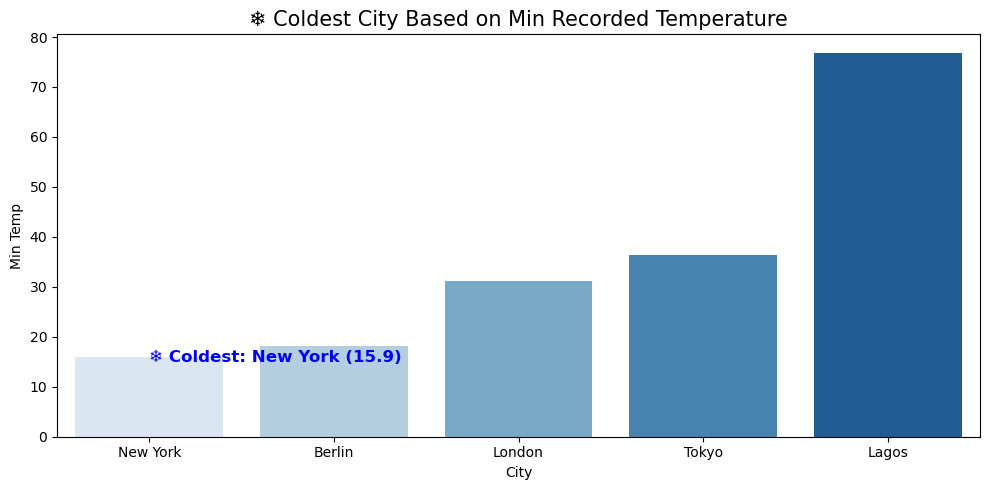

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Step 1: Get the min temperature per city across all days
min_temp_by_city = weather_df.groupby('city')['temp'].min().reset_index()

# Step 2: Sort to find the coldest
min_temp_by_city = min_temp_by_city.sort_values(by='temp')

# Step 3: Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=min_temp_by_city, x='city', y='temp', palette="Blues")

# Step 4: Highlight the coldest one
coldest = min_temp_by_city.iloc[0]
plt.text(
    x=0,
    y=coldest['temp'] - 1,
    s=f"❄️ Coldest: {coldest['city']} ({coldest['temp']})",
    fontsize=12,
    color='blue',
    weight='bold'
)

# Final touches
plt.title("❄️ Coldest City Based on Min Recorded Temperature", fontsize=15)
plt.ylabel("Min Temp")
plt.xlabel("City")
plt.tight_layout()
plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/3047573643.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=max_temp_by_city, x='city', y='temp', palette="Reds")
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/3047573643.py:29: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


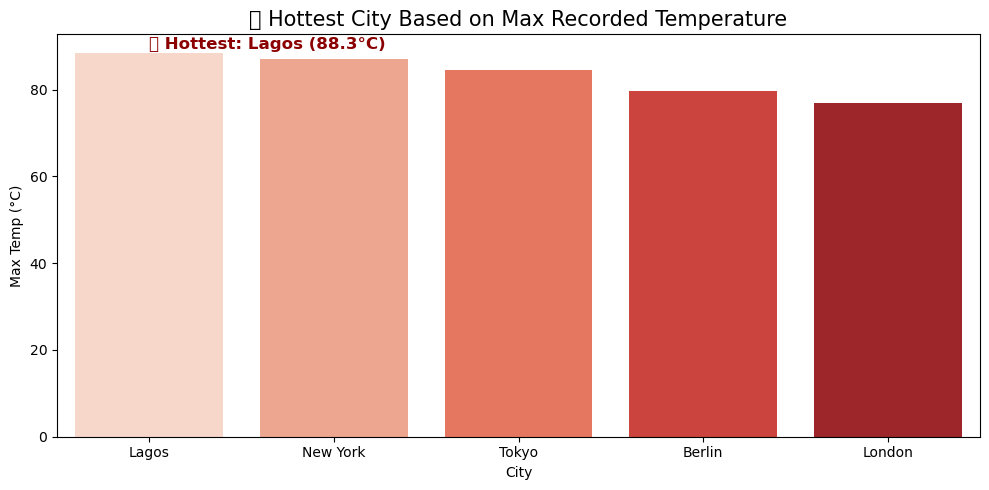

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Get the max temperature per city across all days
max_temp_by_city = weather_df.groupby('city')['temp'].max().reset_index()

# Step 2: Sort to find the hottest
max_temp_by_city = max_temp_by_city.sort_values(by='temp', ascending=False)

# Step 3: Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=max_temp_by_city, x='city', y='temp', palette="Reds")

# Step 4: Highlight the hottest one
hottest = max_temp_by_city.iloc[0]
plt.text(
    x=0,
    y=hottest['temp'] + 1,
    s=f"🔥 Hottest: {hottest['city']} ({hottest['temp']}°C)",
    fontsize=12,
    color='darkred',
    weight='bold'
)

# Final touches
plt.title("🔥 Hottest City Based on Max Recorded Temperature", fontsize=15)
plt.ylabel("Max Temp (°C)")
plt.xlabel("City")
plt.tight_layout()
plt.show()


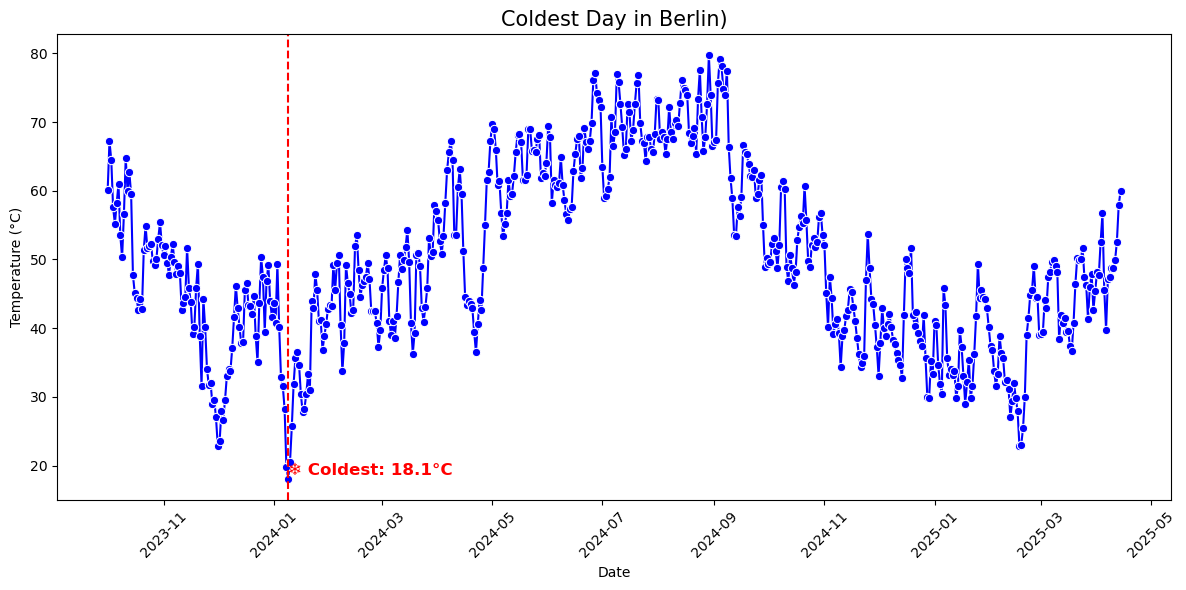

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Filter for Lagos
lagos_df = weather_df[merged_weather_df['city'] == 'Berlin']

# Find the coldest day
coldest_day = lagos_df.loc[lagos_df['temp'].idxmin()]

# Plot all 14 days for Lagos
plt.figure(figsize=(12, 6))
sns.lineplot(data=lagos_df, x='datetime', y='temp', marker='o', color='blue')

# Annotate the coldest day
plt.axvline(x=coldest_day['datetime'], color='red', linestyle='--')
plt.text(
    coldest_day['datetime'],
    coldest_day['temp'] + 0.5,
    f"❄️ Coldest: {coldest_day['temp']}°C",
    color='red',
    fontsize=12,
    weight='bold'
)

# Final touches
plt.title("Coldest Day in Berlin)", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/492472045.py:29: UserWarning: Glyph 127780 (\N{WHITE SUN WITH SMALL CLOUD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127780 (\N{WHITE SUN WITH SMALL CLOUD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


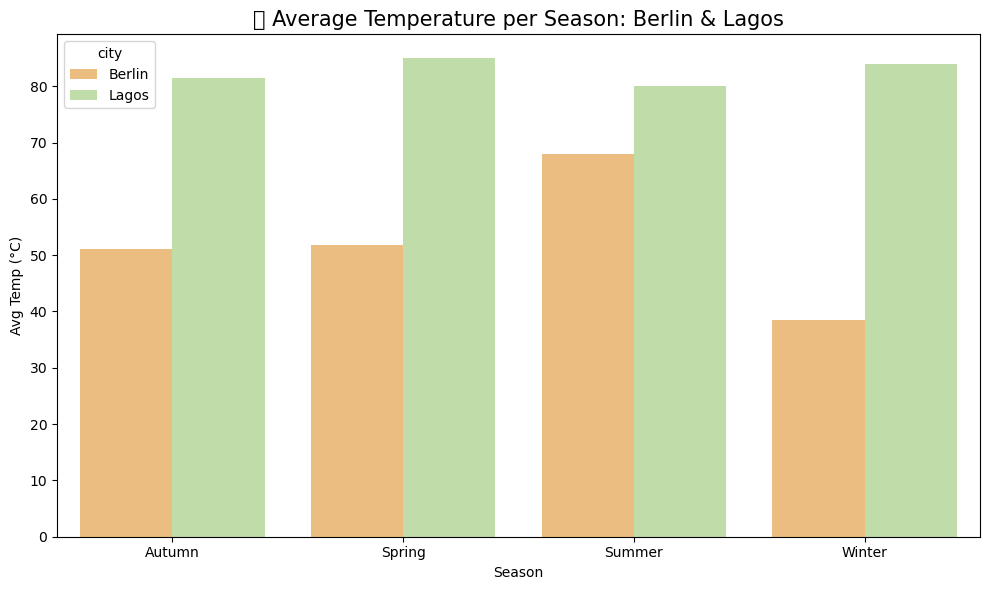

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Filter for Berlin and Lagos
berlin_lagos_seasonal = weather_df[weather_df['city'].isin(['Berlin', 'Lagos'])]

# Group by city and season, then calculate average temperature
season_avg_temp = (
    berlin_lagos_seasonal
    .groupby(['city', 'season'])['temp']  # Make sure this matches your actual temp column
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=season_avg_temp,
    x='season',
    y='temp',
    hue='city',
    palette='Spectral'
)

plt.title("🌤️ Average Temperature per Season: Berlin & Lagos", fontsize=15)
plt.xlabel("Season")
plt.ylabel("Avg Temp (°C)")
plt.tight_layout()
plt.show()



/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/3673194318.py:28: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


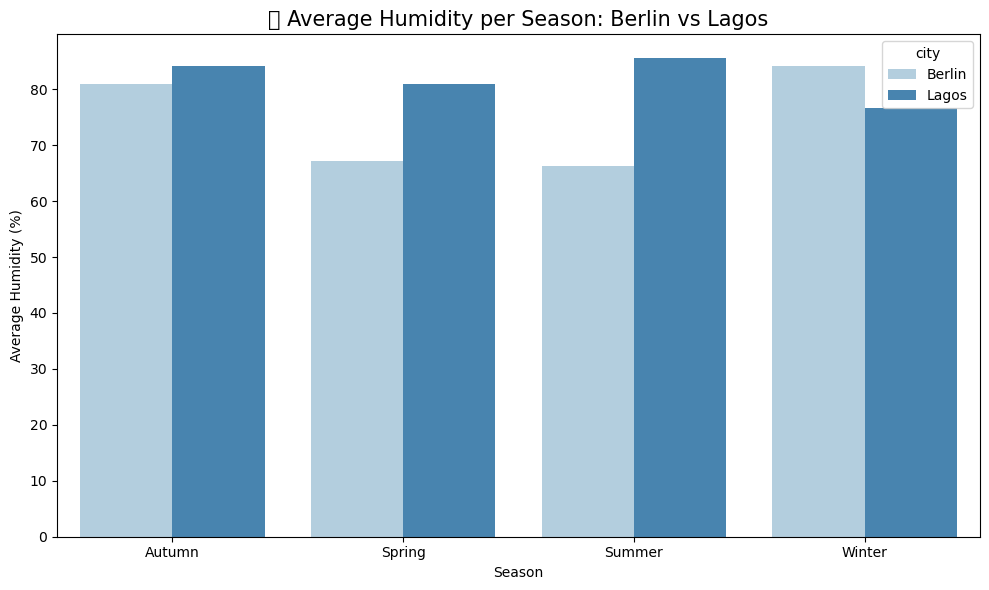

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter only Berlin and Lagos
berlin_lagos = weather_df[weather_df['city'].isin(['Berlin', 'Lagos'])]

# Group by city and season, then compute average humidity
season_avg_humidity = (
    berlin_lagos
    .groupby(['city', 'season'])['humidity']
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=season_avg_humidity,
    x='season',
    y='humidity',
    hue='city',
    palette='Blues'
)

plt.title("💧 Average Humidity per Season: Berlin vs Lagos", fontsize=15)
plt.xlabel("Season")
plt.ylabel("Average Humidity (%)")
plt.tight_layout()
plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2073819012.py:34: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2073819012.py:34: UserWarning: Glyph 129651 (\N{SHORTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2073819012.py:34: UserWarning: Glyph 128374 (\N{DARK SUNGLASSES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129651 (\N{SHORTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/alexnnadi/anaconda3/envs/Exp/lib/

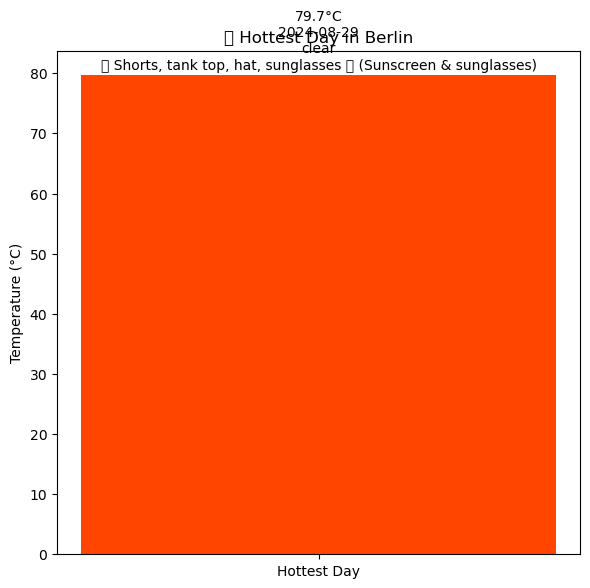

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime column is in proper format
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'])

# Filter Berlin data
berlin_data = weather_df[weather_df['city'].str.lower().str.strip() == 'berlin']

# Handle case when no data for Berlin
if berlin_data.empty:
    print("No weather data available for Berlin.")
else:
    # Find the hottest day
    hottest_day_row = berlin_data.loc[berlin_data['temp'].idxmax()]

    # Extract details safely
    #temp = hottest_day_row['temp']
    #date = hottest_day_row['datetime'].date()
    condition = hottest_day_row.get('conditions', 'Unknown')
    recommendation = hottest_day_row.get('clothing_recommendation', 'No data')

    # Create a simple bar chart
    plt.figure(figsize=(6, 6))
    plt.bar("Hottest Day", temp, color="orangered")

    # Annotate with clothing advice
    plt.text(0, temp + 1,
             f"{temp:.1f}°C\n{date}\n{condition}\n{recommendation}",
             ha='center', fontsize=10)

    plt.title("🔥 Hottest Day in Berlin")
    plt.ylabel("Temperature (°C)")
    plt.tight_layout()
    plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2757843598.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2757843598.py:33: UserWarning: Glyph 129509 (\N{COAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2757843598.py:33: UserWarning: Glyph 128085 (\N{T-SHIRT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2757843598.py:33: UserWarning: Glyph 128374 (\N{DARK SUNGLASSES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2757843598.py:33: UserWarning: Glyph 129526 (\N{BALL OF YARN}) missing from font(s) DejaVu Sans.
  plt.tight_layout

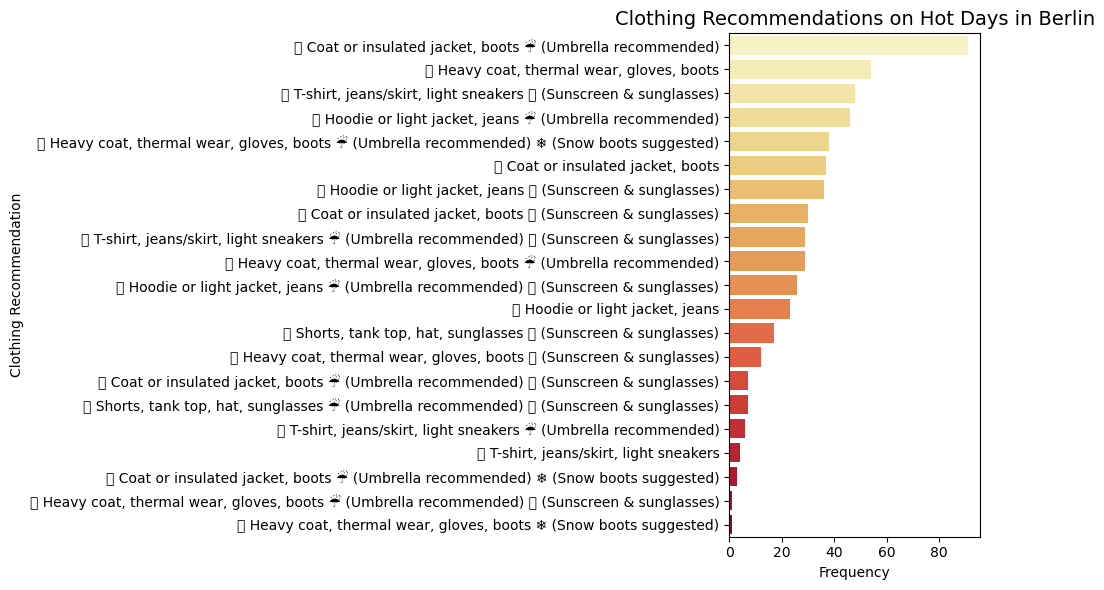

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define threshold for "hot" days (e.g., > 29°C)
hot_threshold = 29

# Filter for hot days in Berlin
hot_berlin = weather_df[
    (weather_df['city'].str.lower().str.strip() == 'berlin') &
    (weather_df['temp'] > hot_threshold)
]

# Group by clothing recommendation and count
hot_recommendations = (
    hot_berlin.groupby('clothing_recommendation')
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=hot_recommendations,
    y='clothing_recommendation',
    x='count',
    palette='YlOrRd'
)

plt.title("Clothing Recommendations on Hot Days in Berlin", fontsize=14)
plt.xlabel("Frequency")
plt.ylabel("Clothing Recommendation")
plt.tight_layout()
plt.show()


In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter only Berlin data
berlin_data = weather_df[weather_df['city'].str.strip().str.lower() == 'berlin']

# Group and count clothing recommendations by season
seasonal_clothing = (
    berlin_data
    .groupby(['season', 'clothing_recommendation'])
    .size()
    .reset_index(name='count')
)


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2538767991.py:16: UserWarning: Glyph 128085 (\N{T-SHIRT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2538767991.py:16: UserWarning: Glyph 128374 (\N{DARK SUNGLASSES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2538767991.py:16: UserWarning: Glyph 129509 (\N{COAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2538767991.py:16: UserWarning: Glyph 129526 (\N{BALL OF YARN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2538767991.py:16: UserWarning: Glyph 129651 (\N{SHORTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: User

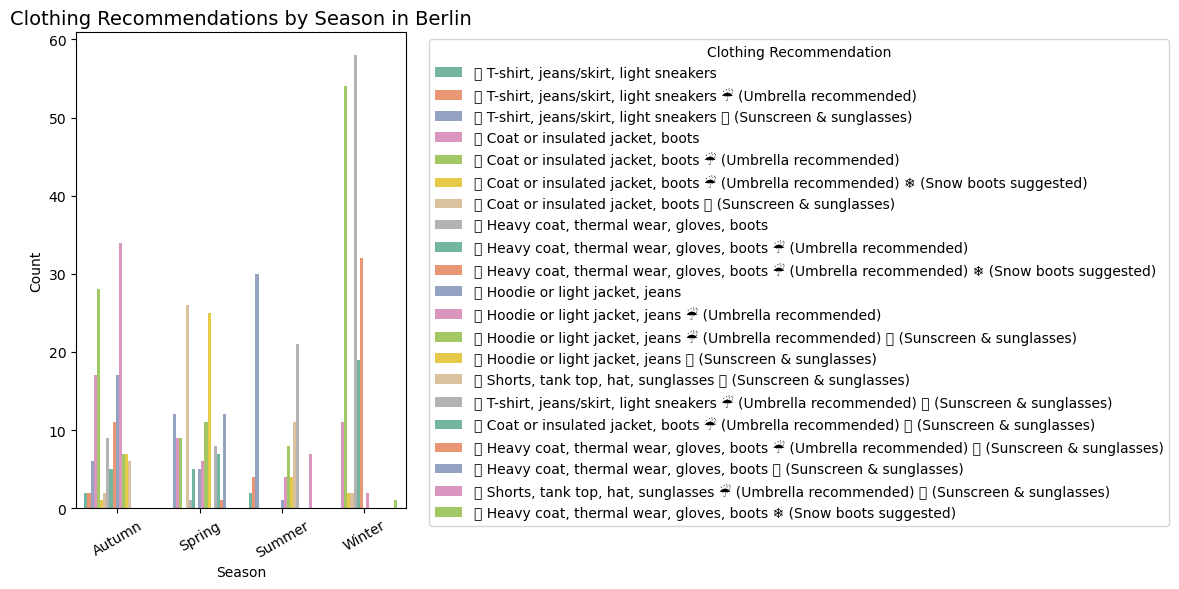

In [59]:
# Plot the grouped clothing recommendation data by season
plt.figure(figsize=(12, 6))
sns.barplot(
    data=seasonal_clothing,
    x='season',
    y='count',
    hue='clothing_recommendation',
    palette='Set2'
)

plt.title("Clothing Recommendations by Season in Berlin", fontsize=14)
plt.xlabel("Season")
plt.ylabel("Count")
plt.legend(title='Clothing Recommendation', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/1937704820.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/1937704820.py:30: UserWarning: Glyph 128085 (\N{T-SHIRT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/1937704820.py:30: UserWarning: Glyph 128374 (\N{DARK SUNGLASSES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/1937704820.py:30: UserWarning: Glyph 129509 (\N{COAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/1937704820.py:30: UserWarning: Glyph 129526 (\N{BALL OF YARN}) missing from font(s) DejaVu Sans.
  plt.tight_layout

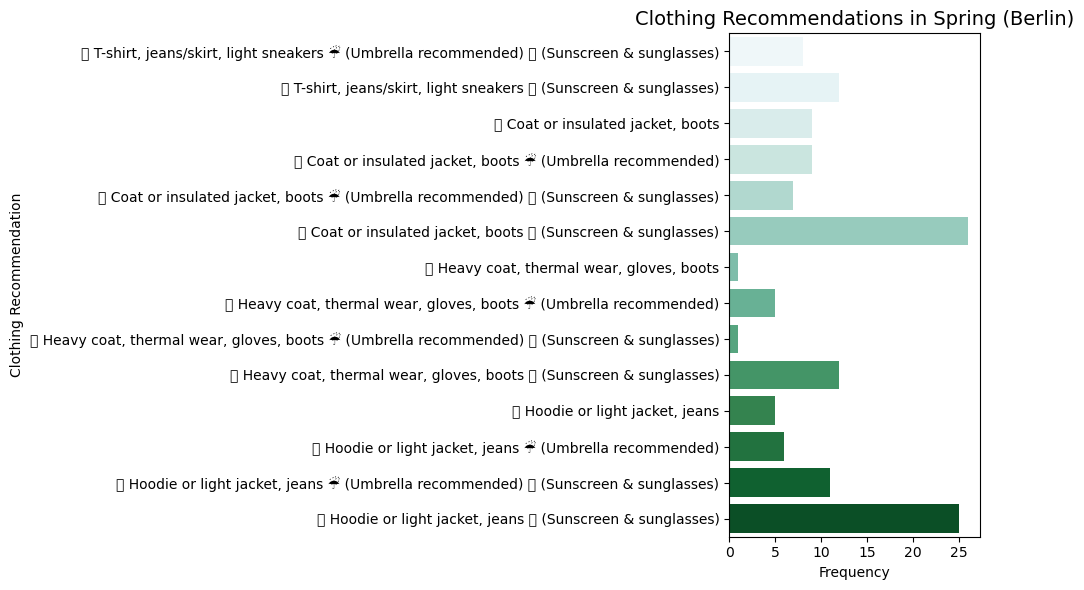

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter Berlin data
berlin_data = weather_df[weather_df['city'].str.strip().str.lower() == 'berlin']

# Group and count clothing recommendations by season
seasonal_clothing = (
    berlin_data
    .groupby(['season', 'clothing_recommendation'])
    .size()
    .reset_index(name='count')
)

# Filter for Spring only
spring_clothing = seasonal_clothing[seasonal_clothing['season'].str.lower() == 'spring']

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=spring_clothing,
    y='clothing_recommendation',
    x='count',
    palette='BuGn'
)

plt.title("Clothing Recommendations in Spring (Berlin)", fontsize=14)
plt.xlabel("Frequency")
plt.ylabel("Clothing Recommendation")
plt.tight_layout()
plt.show()




/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/796001864.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/796001864.py:27: UserWarning: Glyph 128085 (\N{T-SHIRT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/796001864.py:27: UserWarning: Glyph 128374 (\N{DARK SUNGLASSES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/796001864.py:27: UserWarning: Glyph 129526 (\N{BALL OF YARN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/796001864.py:27: UserWarning: Glyph 129651 (\N{SHORTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


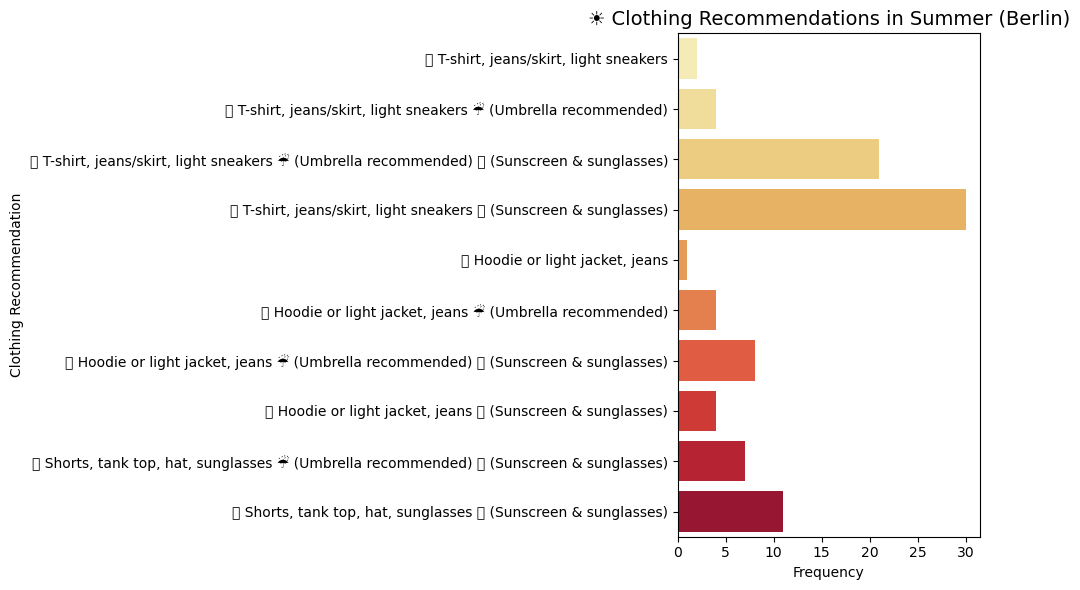

In [62]:
# Filter Berlin data
berlin_data = weather_df[weather_df['city'].str.strip().str.lower() == 'berlin']

# Group and count clothing recommendations by season
seasonal_clothing = (
    berlin_data
    .groupby(['season', 'clothing_recommendation'])
    .size()
    .reset_index(name='count')
)

# Filter for Summer only
summer_clothing = seasonal_clothing[seasonal_clothing['season'].str.lower() == 'summer']

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=summer_clothing,
    y='clothing_recommendation',
    x='count',
    palette='YlOrRd'
)

plt.title("☀️ Clothing Recommendations in Summer (Berlin)", fontsize=14)
plt.xlabel("Frequency")
plt.ylabel("Clothing Recommendation")
plt.tight_layout()
plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/172843951.py:33: UserWarning: Glyph 128085 (\N{T-SHIRT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/172843951.py:33: UserWarning: Glyph 128374 (\N{DARK SUNGLASSES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/172843951.py:33: UserWarning: Glyph 129526 (\N{BALL OF YARN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/172843951.py:33: UserWarning: Glyph 129651 (\N{SHORTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128085 (\N{T-SHIRT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IP

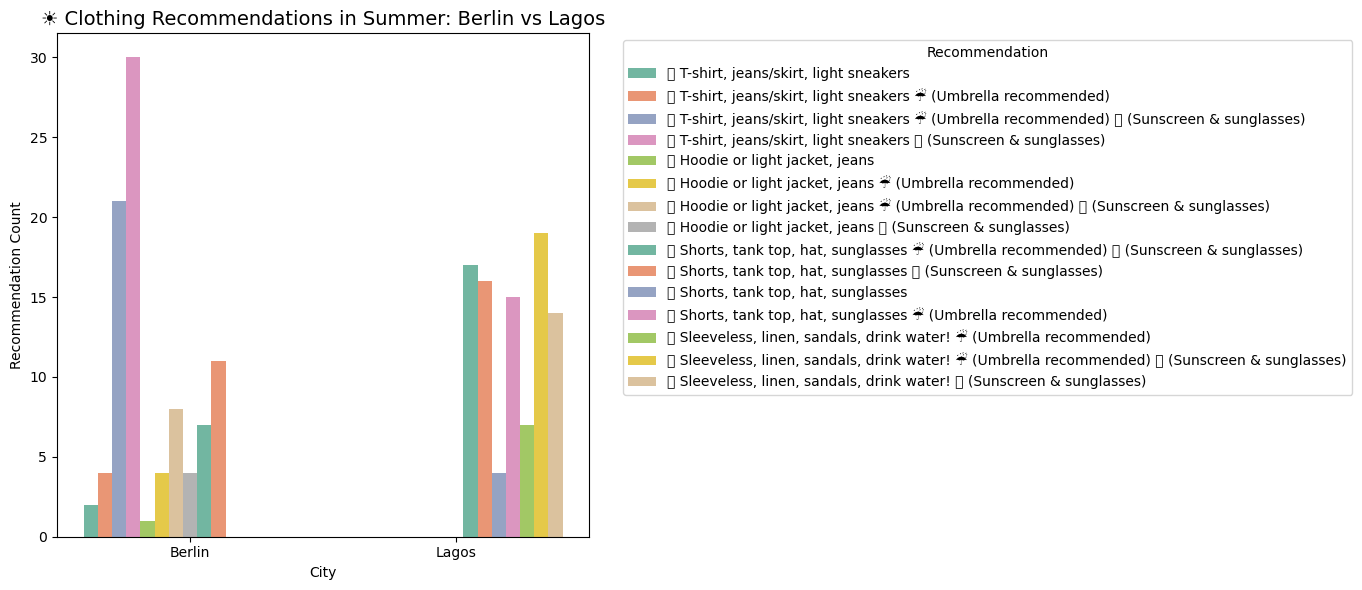

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter only Berlin and Lagos data
berlin_lagos = weather_df[weather_df['city'].isin(['Berlin', 'Lagos'])]

# Group and count clothing recommendations by city and season
seasonal_clothing = (
    berlin_lagos
    .groupby(['season', 'city', 'clothing_recommendation'])
    .size()
    .reset_index(name='count')
)

# Filter for summer only
summer_clothing = seasonal_clothing[seasonal_clothing['season'].str.lower() == 'summer']

# Create combined barplot
plt.figure(figsize=(14, 6))
sns.barplot(
    data=summer_clothing,
    x='city',
    y='count',
    hue='clothing_recommendation',
    palette='Set2',
    dodge=True
)

plt.title("☀️ Clothing Recommendations in Summer: Berlin vs Lagos", fontsize=14)
plt.xlabel("City")
plt.ylabel("Recommendation Count")
plt.legend(title="Recommendation", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/4173555968.py:33: UserWarning: Glyph 128085 (\N{T-SHIRT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/4173555968.py:33: UserWarning: Glyph 128374 (\N{DARK SUNGLASSES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/4173555968.py:33: UserWarning: Glyph 129509 (\N{COAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/4173555968.py:33: UserWarning: Glyph 129526 (\N{BALL OF YARN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/4173555968.py:33: UserWarning: Glyph 129651 (\N{SHORTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: User

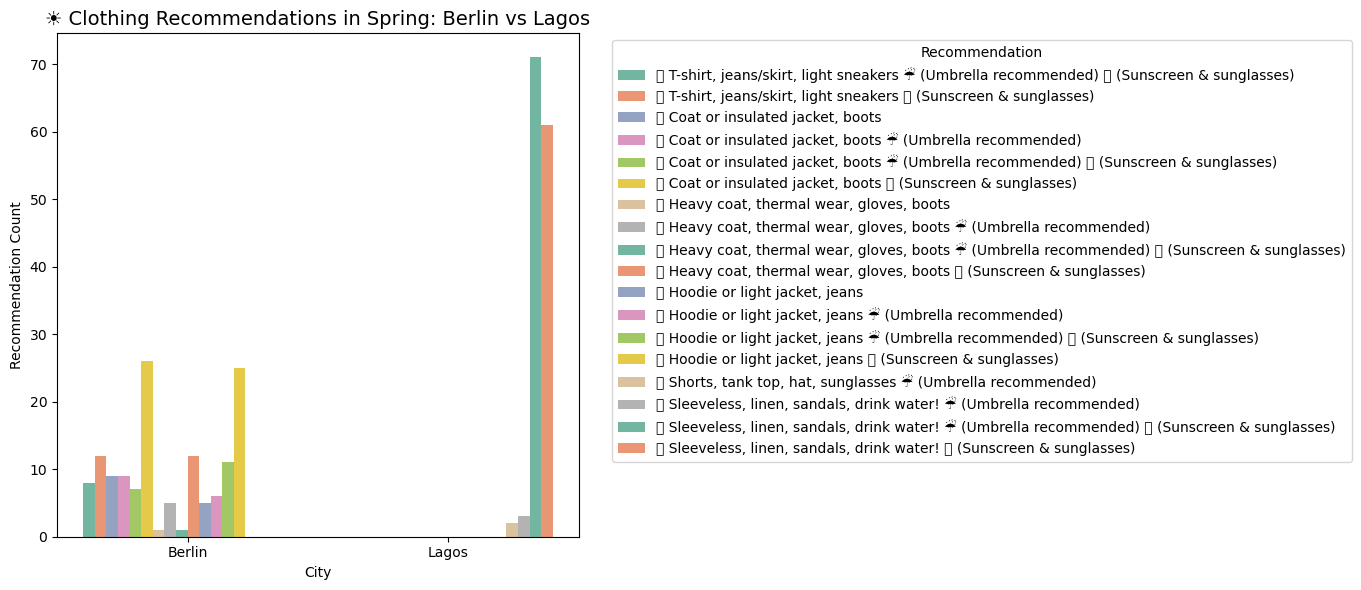

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter only Berlin and Lagos data
berlin_lagos = weather_df[weather_df['city'].isin(['Berlin', 'Lagos'])]

# Group and count clothing recommendations by city and season
seasonal_clothing = (
    berlin_lagos
    .groupby(['season', 'city', 'clothing_recommendation'])
    .size()
    .reset_index(name='count')
)

# Filter for summer only
summer_clothing = seasonal_clothing[seasonal_clothing['season'].str.lower() == 'spring']

# Create combined barplot
plt.figure(figsize=(14, 6))
sns.barplot(
    data=summer_clothing,
    x='city',
    y='count',
    hue='clothing_recommendation',
    palette='Set2',
    dodge=True
)

plt.title("☀️ Clothing Recommendations in Spring: Berlin vs Lagos", fontsize=14)
plt.xlabel("City")
plt.ylabel("Recommendation Count")
plt.legend(title="Recommendation", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2177483365.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2177483365.py:38: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2177483365.py:38: UserWarning: Glyph 128085 (\N{T-SHIRT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2177483365.py:38: UserWarning: Glyph 129651 (\N{SHORTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2177483365.py:38: UserWarning: Glyph 128374 (\N{DARK SUNGLASSES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Us

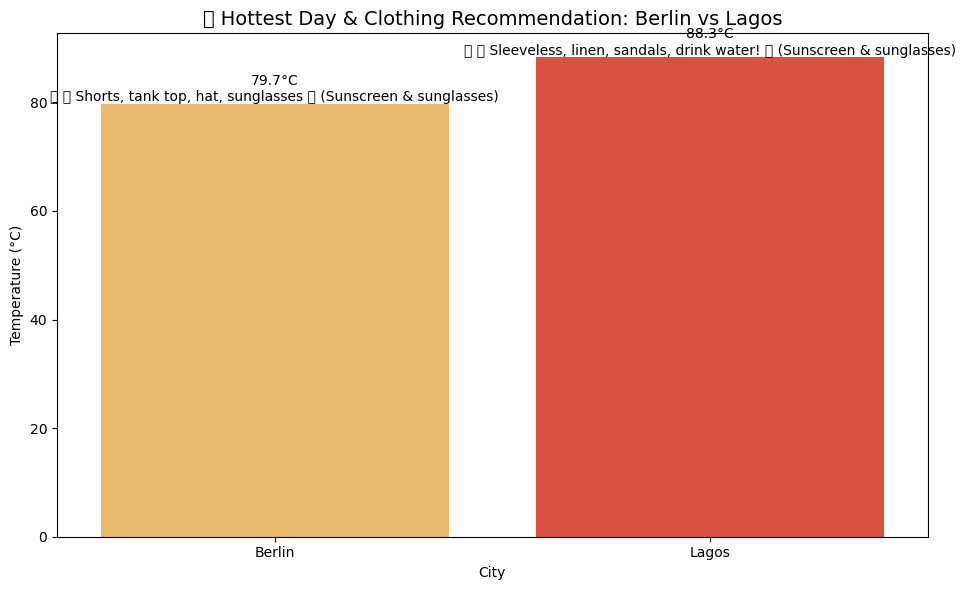

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Filter for Berlin and Lagos
cities = ['Berlin', 'Lagos']
city_data = weather_df[weather_df['city'].isin(cities)]

# Get hottest day per city
hottest_per_city = city_data.loc[city_data.groupby('city')['temp'].idxmax()]

# Reset index for plotting
hottest_per_city = hottest_per_city.reset_index(drop=True)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=hottest_per_city,
    x='city',
    y='temp',
    palette='YlOrRd'
)

# Annotate clothing recommendations
for i, row in hottest_per_city.iterrows():
    plt.text(
        i,
        row['temp'] + 0.5,
        f"{row['temp']}°C\n👕 {row['clothing_recommendation']}",
        ha='center',
        fontsize=10,
        color='black'
    )

plt.title("🔥 Hottest Day & Clothing Recommendation: Berlin vs Lagos", fontsize=14)
plt.xlabel("City")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/312287778.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/312287778.py:34: UserWarning: Glyph 129509 (\N{COAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/312287778.py:34: UserWarning: Glyph 129651 (\N{SHORTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129509 (\N{COAT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129651 (\N{SHORTS}) missing from font(s) Dej

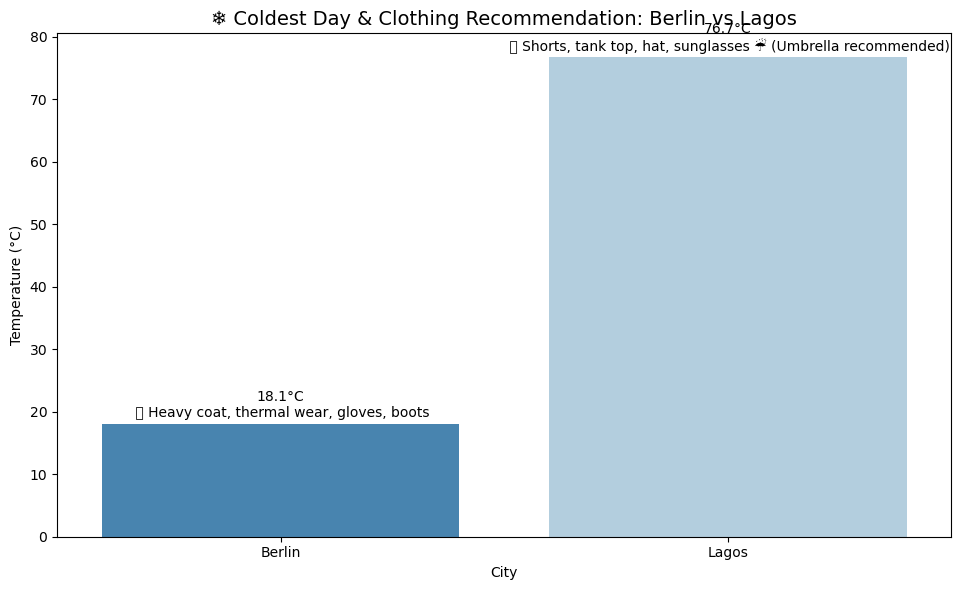

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for Berlin and Lagos
cities = ['Berlin', 'Lagos']
city_dat = weather_df[weather_df['city'].isin(cities)]

# Get coldest day per city
Coldest_per_city = city_dat.loc[city_dat.groupby('city')['temp'].idxmin()].reset_index(drop=True)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=Coldest_per_city,
    x='city',
    y='temp',
    palette='Blues_r'
)

# Annotate clothing recommendations
for i, row in Coldest_per_city.iterrows():
    plt.text(
        i,
        row['temp'] + 1,
        f"{row['temp']}°C\n {row['clothing_recommendation']}",
        ha='center',
        fontsize=10,
        color='black'
    )

plt.title("❄️ Coldest Day & Clothing Recommendation: Berlin vs Lagos", fontsize=14)
plt.xlabel("City")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()


In [67]:
print(weather_df[['sunrise', 'sunrise_hour']].dropna().head(10))


    sunrise  sunrise_hour
0  05:35:04             5
1  05:35:51             5
2  05:36:39             5
3  05:37:27             5
4  05:38:15             5
5  05:39:04             5
6  05:39:52             5
7  05:40:42             5
8  05:41:31             5
9  05:42:21             5


In [68]:
mask = weather_df['datetime'].dt.hour == weather_df['sunrise_hour']
print("Matching rows:", mask.sum())


Matching rows: 0


In [69]:
berlin_sunrise_winter = weather_df[
    weather_df.apply(lambda row: abs(row['datetime'].hour - row['sunrise_hour']) <= 1 if pd.notnull(row['sunrise_hour']) else False, axis=1)
]


In [70]:
print("Records in berlin_sunrise_winter:", len(berlin_sunrise_winter))
print(berlin_sunrise_winter['clothing_recommendation'].value_counts())


Records in berlin_sunrise_winter: 0
Series([], Name: count, dtype: int64)


In [77]:
# Display first 50 non-null rows of 'datetime' and 'sunrise' for debugging
print(weather_df[['datetime', 'sunrise']].dropna().head(10))

    datetime   sunrise
0 2023-10-01  05:35:04
1 2023-10-02  05:35:51
2 2023-10-03  05:36:39
3 2023-10-04  05:37:27
4 2023-10-05  05:38:15
5 2023-10-06  05:39:04
6 2023-10-07  05:39:52
7 2023-10-08  05:40:42
8 2023-10-09  05:41:31
9 2023-10-10  05:42:21


In [78]:
# Show extracted hour alongside original data
print(weather_df[['datetime', 'sunrise', 'sunrise_hour']].dropna().head(10))


    datetime   sunrise  sunrise_hour
0 2023-10-01  05:35:04             5
1 2023-10-02  05:35:51             5
2 2023-10-03  05:36:39             5
3 2023-10-04  05:37:27             5
4 2023-10-05  05:38:15             5
5 2023-10-06  05:39:04             5
6 2023-10-07  05:39:52             5
7 2023-10-08  05:40:42             5
8 2023-10-09  05:41:31             5
9 2023-10-10  05:42:21             5


In [79]:
# Make sure sunrise is parsed as a time (if it's not already)
weather_df['sunrise'] = pd.to_datetime(weather_df['sunrise'], format='%H:%M:%S').dt.time

# Extract the hour from datetime for comparison
weather_df['datetime_hour'] = weather_df['datetime'].dt.hour


In [80]:
# Match rows where the datetime's hour equals the sunrise hour
sunrise_clothing = weather_df[weather_df['datetime_hour'] == weather_df['sunrise_hour']]


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2511790516.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2511790516.py:37: UserWarning: Glyph 129526 (\N{BALL OF YARN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2511790516.py:37: UserWarning: Glyph 128374 (\N{DARK SUNGLASSES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2511790516.py:37: UserWarning: Glyph 129651 (\N{SHORTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129526 (\N{BALL OF YARN}) missing from font(s) DejaVu San

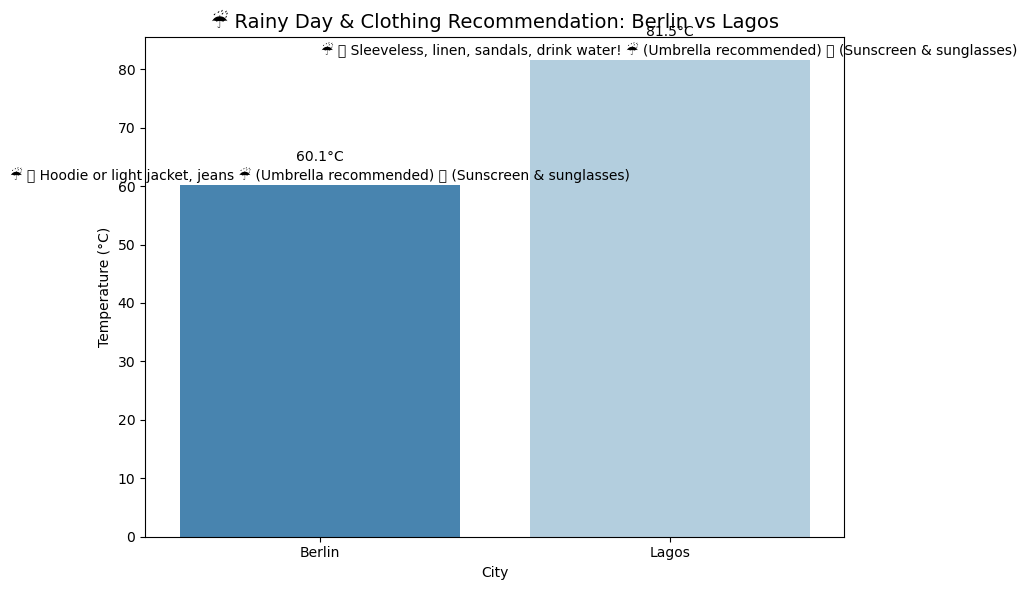

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for Berlin and Lagos
cities = ['Berlin', 'Lagos']
city_data = weather_df[weather_df['city'].isin(cities)]

# Filter for rainy days — adjust depending on your exact column values
rainy_data = city_data[city_data['conditions'].str.lower().str.contains('rain')]

# Get the most rainy day per city (you could also use max precipitation if available)
rainiest_day_per_city = rainy_data.loc[rainy_data.groupby('city')['datetime'].idxmin()].reset_index(drop=True)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=rainiest_day_per_city,
    x='city',
    y='temp',  # or use 'precipitation' if available
    palette='Blues_r'
)

# Annotate clothing recommendations
for i, row in rainiest_day_per_city.iterrows():
    plt.text(
        i,
        row['temp'] + 1,
        f"{row['temp']}°C\n☔ {row['clothing_recommendation']}",
        ha='center',
        fontsize=10,
        color='black'
    )

plt.title("☔ Rainy Day & Clothing Recommendation: Berlin vs Lagos", fontsize=14)
plt.xlabel("City")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/9239495.py:25: UserWarning: Glyph 128085 (\N{T-SHIRT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/9239495.py:25: UserWarning: Glyph 128374 (\N{DARK SUNGLASSES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/9239495.py:25: UserWarning: Glyph 129651 (\N{SHORTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/9239495.py:25: UserWarning: Glyph 129526 (\N{BALL OF YARN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/9239495.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-

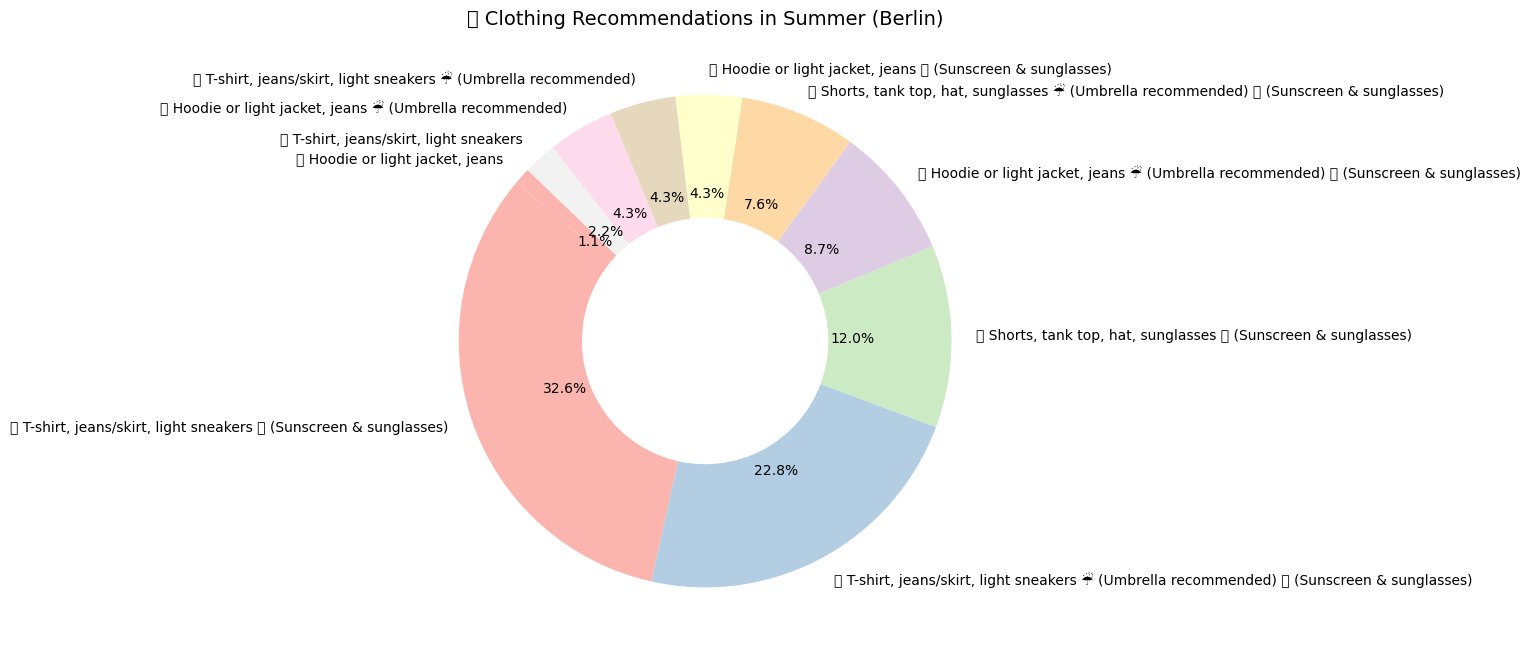

In [82]:
import matplotlib.pyplot as plt

# Filter for Berlin and Summer
berlin_summer = weather_df[
    (weather_df['city'].str.lower().str.strip() == 'berlin') &
    (weather_df['season'].str.lower() == 'summer')
]

# Count clothing recommendations
summer_rec_counts = berlin_summer['clothing_recommendation'].value_counts().reset_index()
summer_rec_counts.columns = ['clothing_recommendation', 'count']

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    summer_rec_counts['count'],
    labels=summer_rec_counts['clothing_recommendation'],
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Pastel1.colors,
    wedgeprops=dict(width=0.5)
)

plt.title("👕 Clothing Recommendations in Summer (Berlin)", fontsize=14)
plt.tight_layout()
plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2509835181.py:25: UserWarning: Glyph 128090 (\N{WOMANS CLOTHES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2509835181.py:25: UserWarning: Glyph 129651 (\N{SHORTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2509835181.py:25: UserWarning: Glyph 128374 (\N{DARK SUNGLASSES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2509835181.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<function matplotlib.pyplot.show(close=None, block=None)>

/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 129651 (\N{SHORTS}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 128374 (\N{DARK SUNGLASSES}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 128090 (\N{WOMANS CLOTHES}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128090 (\N{WOMANS CLOTHES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129651 (\N{SHORTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(

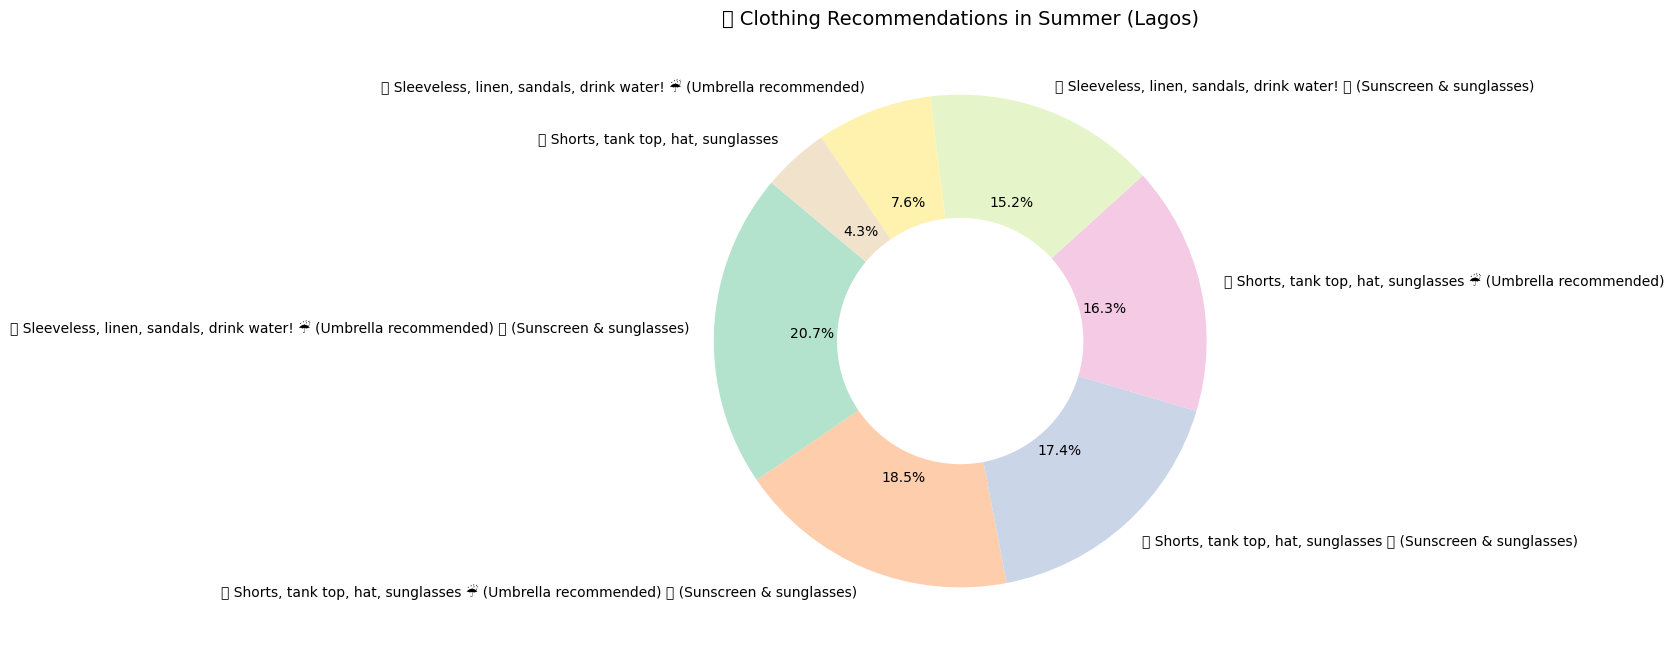

In [83]:
import matplotlib.pyplot as plt

# Filter for Lagos and Summer
lagos_summer = weather_df[
    (weather_df['city'].str.lower().str.strip() == 'lagos') &
    (weather_df['season'].str.lower() == 'summer')
]

# Count clothing recommendations
summer_rec_counts_lagos = lagos_summer['clothing_recommendation'].value_counts().reset_index()
summer_rec_counts_lagos.columns = ['clothing_recommendation', 'count']

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    summer_rec_counts_lagos['count'],
    labels=summer_rec_counts_lagos['clothing_recommendation'],
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Pastel2.colors,
    wedgeprops=dict(width=0.5)
)

plt.title("👚 Clothing Recommendations in Summer (Lagos)", fontsize=14)
plt.tight_layout()
plt.show


# SPOTIFY DATA

In [84]:
import os
import json
import pandas as pd
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

def load_spotify_data(folder_path):
    records = []

    for filename in os.listdir(folder_path):
        if filename.startswith("StreamingHistory_music") and filename.endswith(".json"):
            with open(os.path.join(folder_path, filename), 'r') as f:
                data = json.load(f)
                records.extend(data)

    StreamingMusic = pd.DataFrame(records)
    StreamingMusic['endTime'] = pd.to_datetime(StreamingMusic['endTime'])
    return StreamingMusic

# Replace with your actual folder path
folder_path = "Spotify Account Data"

# Load data
spotify_df = load_spotify_data(folder_path)

# Print the entire DataFrame
print(spotify_df)

# If it’s too big and cuts off:
# Print first few rows
print(spotify_df.head())

# Print DataFrame shape
print("Shape:", spotify_df.shape)

# Print column names
print("Columns:", spotify_df.columns.tolist())

# Optional: Save to CSV to inspect
spotify_df.to_csv("spotify_streaming_cleaned.csv", index=False)


                  endTime             artistName  \
0     2024-09-17 04:50:00             Dhyana Dan   
1     2024-09-17 04:51:00  Spiritual Frequencies   
2     2024-09-17 04:52:00             Dhyana Dan   
3     2024-09-17 04:54:00  Spiritual Frequencies   
4     2024-09-17 04:56:00  Spiritual Frequencies   
...                   ...                    ...   
32632 2025-03-07 23:45:00             Zephyrical   
32633 2025-03-07 23:47:00         Moon Whisperer   
32634 2025-03-08 00:37:00        Ephermal Nights   
32635 2025-03-08 00:40:00         Armonía Astral   
32636 2025-03-08 00:42:00      Kaiser Hulenstadt   

                            trackName  msPlayed  
0               741 Hz Anxiety Relief     73200  
1        417 Hz Clear Negative Energy     85500  
2      741 Hz Positive Transformation     77272  
3             432 Hz Gentle Resonance     98399  
4         852 Hz Spiritual Experience     89552  
...                               ...       ...  
32632                    

In [85]:
spotify_df.head()

,endTime,artistName,trackName,msPlayed
0,2024-09-17 04:50:00,Dhyana Dan,741 Hz Anxiety Relief,73200
1,2024-09-17 04:51:00,Spiritual Frequencies,417 Hz Clear Negative Energy,85500
2,2024-09-17 04:52:00,Dhyana Dan,741 Hz Positive Transformation,77272
3,2024-09-17 04:54:00,Spiritual Frequencies,432 Hz Gentle Resonance,98399
4,2024-09-17 04:56:00,Spiritual Frequencies,852 Hz Spiritual Experience,89552


In [86]:
# Get Artist Genres from Spotify
# -------------------------
def get_artist_genres(spotify_df):
    # Load API credentials
    load_dotenv()
    client_id = os.getenv("SPOTIFY_CLIENT_ID")
    client_secret = os.getenv("SPOTIFY_CLIENT_SECRET")

    # Authenticate
    sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(
        client_id=client_id,
        client_secret=client_secret
    ))

    # Get unique artists
    unique_artists = spotify_df['artistName'].dropna().unique()
    artist_genres = {}

    for artist in unique_artists:
        if artist in artist_genres:
            continue  # skip if already cached
        try:
            result = sp.search(q=f"artist:{artist}", type="artist", limit=1)
            items = result['artists']['items']
            if items:
                artist_genres[artist] = items[0]['genres']
            else:
                artist_genres[artist] = []
            time.sleep(0.1)
        except Exception as e:
            artist_genres[artist] = []
            print(f"Error fetching genre for {artist}: {e}")

    return artist_genres

# -------------------------
# Apply Genre Info to DataFrame
# -------------------------
def assign_genres(spotify_df, artist_genres):
    spotify_df['genre'] = spotify_df['artistName'].map(lambda x: artist_genres.get(x, []))
    spotify_df['main_genre'] = spotify_df['genre'].apply(lambda x: x[0] if x else "Unknown")
    return spotify_df



In [87]:
# -------------------------
# Main Execution
# -------------------------
if __name__ == "__main__":
    folder_path = "Spotify Account Data"
    spotify_df = load_spotify_data(folder_path)
    artist_genres = get_artist_genres(spotify_df)
    spotify_df = assign_genres(spotify_df, artist_genres)
spotify_df



Error fetching genre for Dhyana Dan: name 'time' is not defined
Error fetching genre for Spiritual Frequencies: name 'time' is not defined
Error fetching genre for The Hygrades: name 'time' is not defined
Error fetching genre for Black Savage: name 'time' is not defined
Error fetching genre for Shantala: name 'time' is not defined
Error fetching genre for William Onyeabor: name 'time' is not defined
Error fetching genre for Fela Kuti: name 'time' is not defined
Error fetching genre for Lancelot Layne: name 'time' is not defined
Error fetching genre for Orlando Julius: name 'time' is not defined
Error fetching genre for Ernest Honny: name 'time' is not defined
Error fetching genre for David Walters: name 'time' is not defined
Error fetching genre for The Funkees: name 'time' is not defined
Error fetching genre for Pat Thomas: name 'time' is not defined
Error fetching genre for The Quiet Ones: name 'time' is not defined
Error fetching genre for Balla Et Ses Balladins: name 'time' is not 

,endTime,artistName,trackName,msPlayed,genre,main_genre
0,2024-09-17 04:50:00,Dhyana Dan,741 Hz Anxiety Relief,73200,[],Unknown
1,2024-09-17 04:51:00,Spiritual Frequencies,417 Hz Clear Negative Energy,85500,[],Unknown
2,2024-09-17 04:52:00,Dhyana Dan,741 Hz Positive Transformation,77272,[],Unknown
3,2024-09-17 04:54:00,Spiritual Frequencies,432 Hz Gentle Resonance,98399,[],Unknown
4,2024-09-17 04:56:00,Spiritual Frequencies,852 Hz Spiritual Experience,89552,[],Unknown
...,...,...,...,...,...,...
32632,2025-03-07 23:45:00,Zephyrical,Eternalesque,154662,[],Unknown
32633,2025-03-07 23:47:00,Moon Whisperer,Ember,141000,[],Unknown
32634,2025-03-08 00:37:00,Ephermal Nights,Prism Lights,185851,[],Unknown
32635,2025-03-08 00:40:00,Armonía Astral,Edenora,177600,[],Unknown


In [89]:
    # Preview
print(spotify_df[['artistName', 'trackName', 'main_genre']].head())
print("Shape:", spotify_df.shape)
print("Columns:", spotify_df.columns.tolist())

    # Optional: Save to CSV
spotify_df.to_csv("spotify_streaming_cleaned.csv", index=False)

              artistName                       trackName main_genre
0             Dhyana Dan           741 Hz Anxiety Relief    Unknown
1  Spiritual Frequencies    417 Hz Clear Negative Energy    Unknown
2             Dhyana Dan  741 Hz Positive Transformation    Unknown
3  Spiritual Frequencies         432 Hz Gentle Resonance    Unknown
4  Spiritual Frequencies     852 Hz Spiritual Experience    Unknown
Shape: (32637, 6)
Columns: ['endTime', 'artistName', 'trackName', 'msPlayed', 'genre', 'main_genre']


In [90]:
import os
import json
import time
import pandas as pd
from dotenv import load_dotenv
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

# -------------------------
# Load Spotify Data
# -------------------------
def load_spotify_data(folder_path):
    records = []
    for filename in os.listdir(folder_path):
        if filename.startswith("StreamingHistory_music") and filename.endswith(".json"):
            with open(os.path.join(folder_path, filename), 'r') as f:
                data = json.load(f)
                records.extend(data)
    spotify_df = pd.DataFrame(records)
    spotify_df['endTime'] = pd.to_datetime(spotify_df['endTime'])
    return spotify_df





In [91]:
# -------------------------
# Fetch or Load Artist Genres (with caching)
# -------------------------
def get_artist_genres(spotify_df, cache_file="artist_genres_cache.json"):
    load_dotenv()
    client_id = os.getenv("SPOTIFY_CLIENT_ID")
    client_secret = os.getenv("SPOTIFY_CLIENT_SECRET")

    if not client_id or not client_secret:
        raise ValueError("Missing Spotify API credentials. Check .env file.")

    sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(
        client_id=client_id,
        client_secret=client_secret
    ))

    # Load cached genres if available
    if os.path.exists(cache_file):
        with open(cache_file, "r") as f:
            artist_genres = json.load(f)
    else:
        artist_genres = {}

    unique_artists = spotify_df['artistName'].dropna().unique()

    for artist in unique_artists:
        key = artist.strip().lower()
        if key in artist_genres:
            continue
        try:
            print(f"Searching for: '{artist}'")
            result = sp.search(q=f"artist:{artist.strip()}", type="artist", limit=1)
            items = result['artists']['items']
            if items:
                artist_genres[key] = items[0]['genres']
            else:
                artist_genres[key] = []
            time.sleep(0.1)
        except Exception as e:
            print(f"Error fetching genre for {artist}: {e}")
            artist_genres[key] = []

    # Save cache
    with open(cache_file, "w") as f:
        json.dump(artist_genres, f)

    return artist_genres

In [103]:
# -------------------------
# Assign Genres to DataFrame
# -------------------------
def assign_genres(spotify_df, artist_genres):
    spotify_df['genre'] = spotify_df['artistName'].apply(lambda x: artist_genres.get(str(x).strip().lower(), []))
    spotify_df['main_genre'] = spotify_df['genre'].apply(lambda x: x[0] if x else "Unknown")
    return spotify_df


# -------------------------
# Main Execution
# -------------------------
if __name__ == "__main__":
    folder_path = "Spotify Account Data"
    spotify_df = load_spotify_data(folder_path)

    artist_genres = get_artist_genres(spotify_df)
    spotify_df = assign_genres(spotify_df, artist_genres)

    # Preview
    print(spotify_df[['artistName', 'trackName', 'main_genre']].head())
    print("Shape:", spotify_df.shape)

    # Save cleaned data
    spotify_df.to_csv("spotify_streaming_cleaned.csv", index=False)

              artistName                       trackName main_genre
0             Dhyana Dan           741 Hz Anxiety Relief    Unknown
1  Spiritual Frequencies    417 Hz Clear Negative Energy    Unknown
2             Dhyana Dan  741 Hz Positive Transformation    Unknown
3  Spiritual Frequencies         432 Hz Gentle Resonance    Unknown
4  Spiritual Frequencies     852 Hz Spiritual Experience    Unknown
Shape: (32637, 6)


In [104]:
spotify_df

,endTime,artistName,trackName,msPlayed,genre,main_genre
0,2024-09-17 04:50:00,Dhyana Dan,741 Hz Anxiety Relief,73200,[],Unknown
1,2024-09-17 04:51:00,Spiritual Frequencies,417 Hz Clear Negative Energy,85500,[],Unknown
2,2024-09-17 04:52:00,Dhyana Dan,741 Hz Positive Transformation,77272,[],Unknown
3,2024-09-17 04:54:00,Spiritual Frequencies,432 Hz Gentle Resonance,98399,[],Unknown
4,2024-09-17 04:56:00,Spiritual Frequencies,852 Hz Spiritual Experience,89552,[],Unknown
...,...,...,...,...,...,...
32632,2025-03-07 23:45:00,Zephyrical,Eternalesque,154662,[],Unknown
32633,2025-03-07 23:47:00,Moon Whisperer,Ember,141000,[],Unknown
32634,2025-03-08 00:37:00,Ephermal Nights,Prism Lights,185851,[],Unknown
32635,2025-03-08 00:40:00,Armonía Astral,Edenora,177600,[],Unknown


In [105]:
import pandas as pd

# Assuming your DataFrame is called spotify_df
# Step 1: Convert endTime to datetime
spotify_df['endTime'] = pd.to_datetime(spotify_df['endTime'])

# Step 2: Extract the month
spotify_df['month'] = spotify_df['endTime'].dt.month

# Step 3: Define a function to get season from month
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

# Step 4: Create the season column
spotify_df['season'] = spotify_df['month'].apply(get_season)


# Spotify EDA

In [265]:
# Group by genre and sum msPlayed
genre_playtime = (
    spotify_df.groupby('genre')['msPlayed']
    .sum()
    .reset_index()
    .sort_values(by='msPlayed', ascending=False)
)

# Convert msPlayed to hours (optional, easier to interpret)
genre_playtime['Hours Listened'] = genre_playtime['msPlayed'] / (1000 * 60 * 60)

# Display top genres
print(genre_playtime)


                                                 genre    msPlayed  \
481                                                 []  3634217358   
297                     ['gregorian chant', 'new age']   146902530   
252                                     ['devotional']    82077176   
365                                        ['lullaby']    63162259   
73   ['afrobeats', 'afrobeat', 'afropop', 'afroswin...    50528711   
..                                                 ...         ...   
137           ['afrobeats', 'pop urbaine', 'afrobeat']         743   
3    ['african gospel', 'afrobeats', 'gospel', 'afr...         743   
211                 ['bollywood', 'hindi pop', 'desi']         673   
353                  ['kizomba', 'portuguese hip hop']         510   
128  ['afrobeats', 'azonto', 'afrobeat', 'hiplife',...           0   

     Hours Listened  
481     1009.504822  
297       40.806258  
252       22.799216  
365       17.545072  
73        14.035753  
..              ...  
137  

In [97]:
# If 'genre' is a list, explode it into separate rows
spotify_df = spotify_df.explode('genre')

# Now group by genre and sum playtime
genre_playtime = (
    spotify_df.groupby('genre')['msPlayed']
    .sum()
    .reset_index()
    .sort_values(by='msPlayed', ascending=False)
)

# Convert msPlayed to hours
genre_playtime['Hours Listened'] = genre_playtime['msPlayed'] / (1000 * 60 * 60)

# Display top genres
print(genre_playtime)


                  genre   msPlayed  Hours Listened
8              afrobeat  778998525      216.388479
9             afrobeats  631135165      175.315324
11              afropop  604174966      167.826379
10            afropiano  464247781      128.957717
16                 alté  331453713       92.070476
..                  ...        ...             ...
130              ghazal       1068        0.000297
31           bangla pop       1068        0.000297
221       pinoy hip hop       1023        0.000284
222           pinoy r&b       1023        0.000284
225  portuguese hip hop        510        0.000142

[299 rows x 3 columns]


In [107]:
# Ensure 'genre' column is a string
spotify_df['genre'] = spotify_df['genre'].astype(str)

# Group by genre and sum msPlayed
top_genres = (
    spotify_df.groupby('genre')['msPlayed']
    .sum()
    .reset_index()
    .sort_values(by='msPlayed', ascending=False)
    .head(5)
)

# Convert msPlayed to hours for better understanding
top_genres['Hours Listened'] = top_genres['msPlayed'] / (1000 * 60 * 60)

# Show top 5 genres
print(top_genres[['genre', 'Hours Listened']])


                                                 genre  Hours Listened
481                                                 []     1009.504822
297                     ['gregorian chant', 'new age']       40.806258
252                                     ['devotional']       22.799216
365                                        ['lullaby']       17.545072
73   ['afrobeats', 'afrobeat', 'afropop', 'afroswin...       14.035753


In [108]:
import pandas as pd

# Count how many times each genre appears
genre_counts = spotify_df['genre'].value_counts().reset_index()
genre_counts.columns = ['genre', 'count']

# Show the most listened-to genre
most_listened_genre = genre_counts.iloc[0]
print("🎧 Most listened-to genre:", most_listened_genre['genre'])
print("Play count:", most_listened_genre['count'])

# Optional: Display top 5
print("\n🎶 Top 10 Genres:\n", genre_counts.head())


🎧 Most listened-to genre: []
Play count: 22727

🎶 Top 10 Genres:
                                                genre  count
0                                                 []  22727
1                                        ['lullaby']    530
2                     ['gregorian chant', 'new age']    529
3  ['afrobeats', 'afrobeat', 'afropop', 'afroswin...    302
4  ['afrobeats', 'afrobeat', 'afropop', 'afropian...    261


In [109]:
# Make sure genre column is string and filter devotional songs
spotify_df['genre'] = spotify_df['genre'].astype(str)
devotional_df = spotify_df[spotify_df['genre'].str.lower().str.contains('devotional')]

# Group by song and artist, sum msPlayed
top_devotional_songs = (
    devotional_df
    .groupby(['trackName', 'artistName'])['msPlayed']
    .sum()
    .reset_index()
    .sort_values(by='msPlayed', ascending=False)
    .head(5)
)

# Convert msPlayed to minutes for readability
top_devotional_songs['Minutes Played'] = top_devotional_songs['msPlayed'] / (1000 * 60)

# Show results
print(top_devotional_songs[['trackName', 'artistName', 'Minutes Played']])


                 trackName artistName  Minutes Played
10     Kothbiro-Jaya Radhe   Shantala      367.775467
21               Om Shanti   Edo & Jo      140.689200
18  Om Guru (Trust Within)   Edo & Jo      121.872400
9                  Gayatri   Edo & Jo      104.025000
13               Moon Song   Edo & Jo       77.615200


In [110]:
# Ensure 'genre' column is treated as string
spotify_df['genre'] = spotify_df['genre'].astype(str)

# Print all unique genres
unique_genres = spotify_df['genre'].unique()

# Display
for genre in unique_genres:
    print(genre)

[]
['afrobeat', 'highlife']
['devotional']
['afrobeat']
['afrobeat', 'highlife', 'afropop']
['calypso']
['afrobeat', 'highlife', 'afropop', 'afro soul']
['highlife']
['highlife', 'hiplife', 'afrobeat']
['afrobeat', 'afropop', 'afro soul']
['roots reggae', 'dub', 'rocksteady', 'lovers rock']
['highlife', 'afrobeat']
['disco']
['afrobeat', 'afropop', 'highlife']
['highlife', 'fújì']
['highlife', 'traditional music', 'fújì']
['highlife', 'fújì', 'traditional music']
['taiwanese indie', 'chinese indie', 'bedroom pop']
['afrobeat', 'highlife', 'afro soul']
['blues rock']
['exotica', 'spoken word']
['soul jazz']
['acid rock']
['psychedelic rock', 'psychedelic pop']
['brooklyn drill', 'drill', 'new york drill']
['afrobeats', 'afrobeat', 'afropop', 'afropiano', 'afro soul', 'alté', 'afroswing']
['traditional music']
['alté', 'afrobeats', 'afrobeat', 'afropop', 'afro adura', 'afro soul', 'afropiano']
['afrobeats', 'afrobeat', 'afropop', 'afropiano', 'azonto', 'afro adura', 'afroswing', 'amapian

In [111]:
# Ensure genre and track/artist columns are strings
spotify_df['genre'] = spotify_df['genre'].astype(str)
spotify_df['trackName'] = spotify_df['trackName'].astype(str)
spotify_df['artistName'] = spotify_df['artistName'].astype(str)

# Filter for lullaby-related songs (by genre or name)
lullaby_df = spotify_df[
    spotify_df['genre'].str.lower().str.contains('lullaby') |
    spotify_df['trackName'].str.lower().str.contains('lullaby') |
    spotify_df['artistName'].str.lower().str.contains('lullaby')
]

# Group and sum by track and artist
top_lullabies = (
    lullaby_df
    .groupby(['trackName', 'artistName'])['msPlayed']
    .sum()
    .reset_index()
    .sort_values(by='msPlayed', ascending=False)
    .head(5)
)

# Convert msPlayed to minutes
top_lullabies['Minutes Listened'] = top_lullabies['msPlayed'] / (1000 * 60)

# Display result
print(top_lullabies[['trackName', 'artistName', 'Minutes Listened']])

          trackName    artistName  Minutes Listened
137    Ma's Lullaby   Sam Garrett         33.776000
167  Peaceful Sleep  Lullaby Time         29.228550
32   Brahms Lullaby  Lullaby Time         24.641850
20             Aria  Lullaby Time         21.173333
89       Gymnopédie  Lullaby Time         20.487383


In [112]:
# Replace 'trackName' with the actual column name in your dataset for the song title
most_played = spotify_df['trackName'].value_counts().reset_index()
most_played.columns = ['trackName', 'count']

# Display the top song
top_song = most_played.iloc[0]
print(f"🎶 Most Listened Song: {top_song['trackName']} ({top_song['count']} times)")


🎶 Most Listened Song: 741 Hz DNA Repair (147 times)


In [113]:
print(most_played.head(10))


                         trackName  count
0                741 Hz DNA Repair    147
1            741 Hz Anxiety Relief    146
2             528 Hz In the Moment    145
3        417 Hz Removing Blockages    145
4  417 Hz Clearing Negative Energy    144
5   741 Hz Positive Transformation    143
6           639 Hz Heart Frequency    143
7           528 Hz Great Awareness    143
8      852 Hz Spiritual Experience    142
9   396 Hz Root Chakra Enhancement    141


In [114]:
# Group by season, trackName, and artistName to count plays
seasonal_top_songs = (
    spotify_df.groupby(['season', 'trackName', 'artistName'])
    .size()
    .reset_index(name='count')
)

# Get top song per season
top_per_season = (
    seasonal_top_songs.sort_values('count', ascending=False)
    .groupby('season')
    .first()
    .reset_index()
)

# Display
print(top_per_season)


   season                  trackName      artistName  count
0  Autumn  Wieso tust Du dir das an?      Apache 207     58
1  Spring                       Sing       Gregorian     75
2  Summer          741 Hz DNA Repair      Dhyana Dan    124
3  Winter           Cheri Cheri Lady  Modern Talking     79


In [115]:
import pandas as pd

# Ensure 'endTime' is in datetime format
spotify_df['endTime'] = pd.to_datetime(spotify_df['endTime'])

# Extract just the date
spotify_df['date'] = spotify_df['endTime'].dt.date

# Find the day with the most tracks played
top_day = spotify_df['date'].value_counts().idxmax()
top_day_count = spotify_df['date'].value_counts().max()

print(f"📅 Most listened day: {top_day} with {top_day_count} tracks")

# Filter the DataFrame for that day
top_day_df = spotify_df[spotify_df['date'] == top_day]

# Display track and artist names
most_listened_tracks = top_day_df[['trackName', 'artistName']]

print("\n🎶 Tracks and Artists you listened to the most on that day:\n")
print(most_listened_tracks)


📅 Most listened day: 2024-08-13 with 364 tracks

🎶 Tracks and Artists you listened to the most on that day:

                         trackName             artistName
15447       741 Hz Miracles & Love             Dhyana Dan
15448   396 Hz Finding Inner Peace  Spiritual Frequencies
15449      852 Hz Third Eye Chakra  Spiritual Frequencies
15450    417 Hz Removing Blockages  Spiritual Frequencies
15451      432 Hz Harmonic Balance  Spiritual Frequencies
...                            ...                    ...
15806        741 Hz Love Frequency             Dhyana Dan
15807           528 Hz Love Energy  Spiritual Frequencies
15808  963 Hz Sleep Cycle Enhancer  Spiritual Frequencies
15809   396 Hz Guilt & Fear Relief  Spiritual Frequencies
15810   852 Hz Awakening Intuition  Spiritual Frequencies

[364 rows x 2 columns]


In [116]:
# Convert genre column to string safely
spotify_df['genre'] = spotify_df['genre'].astype(str)

# Now filter for Afrobeat
afrobeat_songs = spotify_df[spotify_df['genre'].str.lower().str.contains('afrobeats')]

# Group and count plays
top_afrobeat = (
    afrobeat_songs
    .groupby(['trackName', 'artistName'])
    .size()
    .reset_index(name='play_count')
    .sort_values(by='play_count', ascending=False)
)

print("🔥 Most Listened Afrobeat Songs:")
print(top_afrobeat.head(10))


🔥 Most Listened Afrobeat Songs:
                        trackName    artistName  play_count
331   FIREGUN (feat. Fireboy DML)  ODUMODUBLVCK          80
1033                       Update     Burna Boy          78
780                         Paris  King Promise          71
189                 Can't Breathe         Llona          69
566                          Laho    Shallipopi          66
201                    Chandelier        Monaky          66
392                     Gimme Lov    J. Martins          65
9                        365 Days     Tml Vibez          59
225                     Comforter         Llona          57
508   Jaga Jaga (with Babyboy AV)       Victony          56


In [117]:
# Ensure endTime is datetime
spotify_df['endTime'] = pd.to_datetime(spotify_df['endTime'])

# Extract hour
spotify_df['hour'] = spotify_df['endTime'].dt.hour

# Filter for late night hours (00:00 - 05:00)
late_night_df = spotify_df[spotify_df['hour'].between(0, 5)]

# Group by track and sum msPlayed
top_late_night_tracks = (
    late_night_df
    .groupby(['trackName', 'artistName'])['msPlayed']
    .sum()
    .reset_index()
    .sort_values(by='msPlayed', ascending=False)
    .head(5)
)

# Convert msPlayed to minutes
top_late_night_tracks['Minutes Listened'] = top_late_night_tracks['msPlayed'] / (1000 * 60)

# Display results
print(top_late_night_tracks[['trackName', 'artistName', 'Minutes Listened']])


                                            trackName          artistName  \
653                                Chakra's Awakening     Kamari & Manvir   
1581                           Metara (Metamorphosis)              Darpan   
2248                              Spiral / I'm In You              Darpan   
1664                                    Native Prayer  Gerhard Fankhauser   
2687  Zen Garden Sleep Talk-Down: A Guided Meditation    Jason Stephenson   

      Minutes Listened  
653         369.170283  
1581        301.002933  
2248        229.326550  
1664        200.660667  
2687        180.140450  


In [118]:
# Make sure endTime is in datetime format
spotify_df['endTime'] = pd.to_datetime(spotify_df['endTime'])

# Extract hour
spotify_df['hour'] = spotify_df['endTime'].dt.hour

# Filter for evening (17:00 to 21:00)
evening_df = spotify_df[spotify_df['hour'].between(17, 21)]

# Group by track and artist, sum msPlayed
top_evening_tracks = (
    evening_df
    .groupby(['trackName', 'artistName'])['msPlayed']
    .sum()
    .reset_index()
    .sort_values(by='msPlayed', ascending=False)
    .head(5)
)

# Convert msPlayed to minutes
top_evening_tracks['Minutes Listened'] = top_evening_tracks['msPlayed'] / (1000 * 60)

# Show result
print(top_evening_tracks[['trackName', 'artistName', 'Minutes Listened']])

                   trackName       artistName  Minutes Listened
362       Chakra's Awakening  Kamari & Manvir        288.521183
1101  Metara (Metamorphosis)           Darpan        151.460417
1026      Losing My Religion        Gregorian        136.224517
1752             Upside Down        Fela Kuti         97.981800
1821          Where Do We Go         MONKYMAN         93.502367


In [119]:
# Ensure 'endTime' is datetime
spotify_df['endTime'] = pd.to_datetime(spotify_df['endTime'])

# Extract the hour
spotify_df['hour'] = spotify_df['endTime'].dt.hour

# Filter for morning hours (6 AM to 11:59 AM)
morning_df = spotify_df[spotify_df['hour'].between(6, 11)]

# Group by track and artist, sum msPlayed
top_morning_tracks = (
    morning_df
    .groupby(['trackName', 'artistName'])['msPlayed']
    .sum()
    .reset_index()
    .sort_values(by='msPlayed', ascending=False)
    .head(5)
)

# Convert msPlayed to minutes
top_morning_tracks['Minutes Listened'] = top_morning_tracks['msPlayed'] / (1000 * 60)

# Show result
print(top_morning_tracks[['trackName', 'artistName', 'Minutes Listened']])


                trackName       artistName  Minutes Listened
1862                 Sing        Gregorian        191.951683
2176          Upside Down        Fela Kuti        188.042150
1170  Kothbiro-Jaya Radhe         Shantala        168.143200
2175               Update        Burna Boy        160.918367
1062         In Existence  Beautiful World        158.363150


In [120]:
# Ensure 'endTime' is datetime
spotify_df['endTime'] = pd.to_datetime(spotify_df['endTime'])

# Extract the hour
spotify_df['hour'] = spotify_df['endTime'].dt.hour

# Filter for afternoon hours (12 PM to 5:59 PM)
afternoon_df = spotify_df[spotify_df['hour'].between(12, 17)]

# Group by track and artist, sum msPlayed
top_afternoon_tracks = (
    afternoon_df
    .groupby(['trackName', 'artistName'])['msPlayed']
    .sum()
    .reset_index()
    .sort_values(by='msPlayed', ascending=False)
    .head(5)
)

# Convert msPlayed to minutes
top_afternoon_tracks['Minutes Listened'] = top_afternoon_tracks['msPlayed'] / (1000 * 60)

# Display result
print(top_afternoon_tracks[['trackName', 'artistName', 'Minutes Listened']])


               trackName artistName  Minutes Listened
800             Ma Baker   Boney M.        211.540833
773   Losing My Religion  Gregorian        166.835150
1415              Why Me     D'banj        157.072117
1189                Sing  Gregorian        134.397650
1422          Without Me     Eminem        116.859383


In [121]:
# Ensure 'endTime' is in datetime format
spotify_df['endTime'] = pd.to_datetime(spotify_df['endTime'])

# Extract hour
spotify_df['hour'] = spotify_df['endTime'].dt.hour

# Filter for night hours (20:00 - 23:59)
night_df = spotify_df[spotify_df['hour'].between(20, 23)]

# Group by track and artist, sum msPlayed
top_night_tracks = (
    night_df
    .groupby(['trackName', 'artistName'])['msPlayed']
    .sum()
    .reset_index()
    .sort_values(by='msPlayed', ascending=False)
    .head(5)
)

# Convert msPlayed to minutes
top_night_tracks['Minutes Listened'] = top_night_tracks['msPlayed'] / (1000 * 60)

# Show results
print(top_night_tracks[['trackName', 'artistName', 'Minutes Listened']])


                        trackName             artistName  Minutes Listened
412            Chakra's Awakening        Kamari & Manvir        613.973433
1168       Metara (Metamorphosis)                 Darpan        549.392883
925                 Ide Were Were            David Lurey        194.783650
799   Guided Meditation for Sleep         Simonette Vaja         90.319650
542                   Devi Prayer  Craig Pruess & Ananda         85.446200


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/496450279.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/496450279.py:15: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


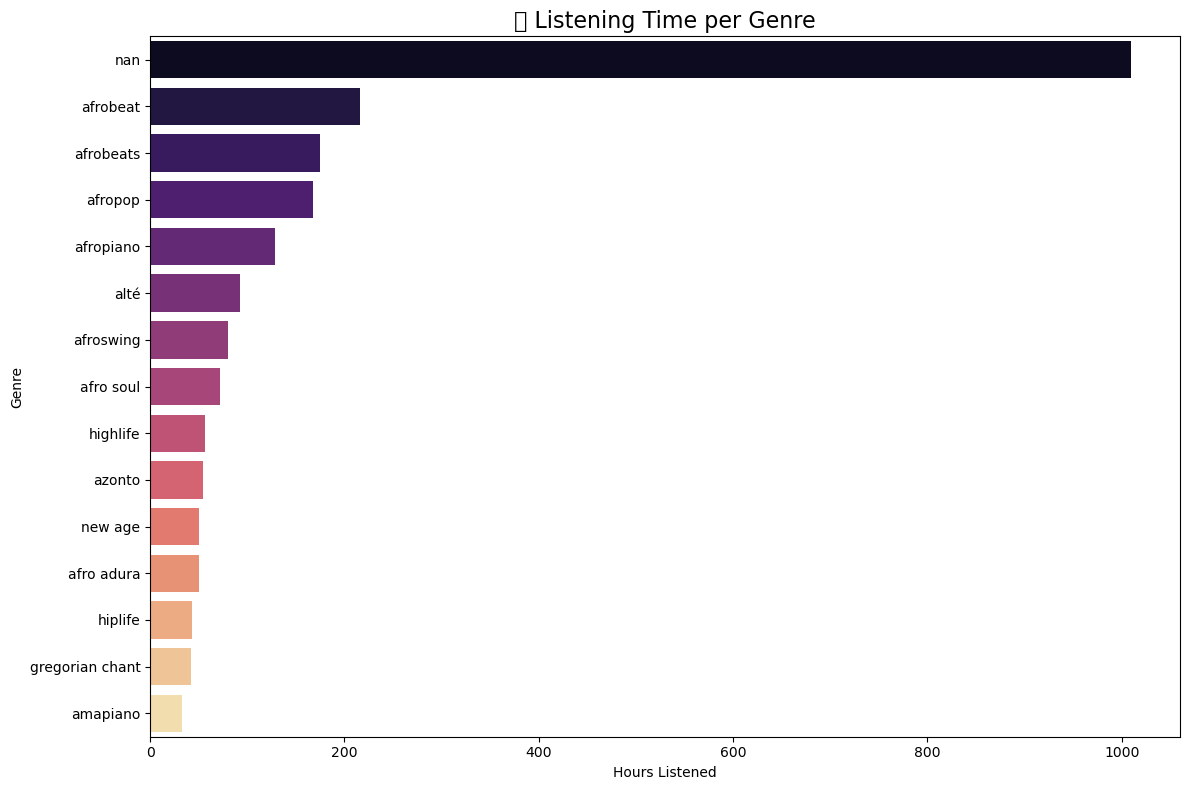

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(
    data=genre_playtime.head(15),  # top 15 for readability
    y='genre',
    x='Hours Listened',
    palette='magma'
)

plt.title("🎧 Listening Time per Genre", fontsize=16)
plt.xlabel("Hours Listened")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/1491373201.py:18: UserWarning: Glyph 128164 (\N{SLEEPING SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128164 (\N{SLEEPING SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


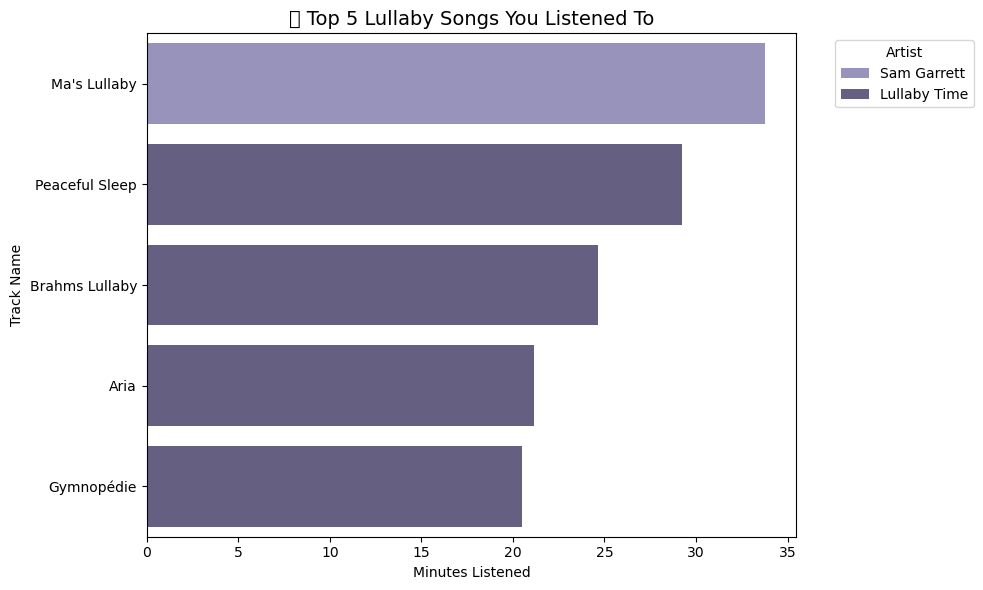

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_lullabies,
    x='Minutes Listened',
    y='trackName',
    hue='artistName',
    palette='Purples_d',
    dodge=False
)

plt.title("💤 Top 5 Lullaby Songs You Listened To", fontsize=14)
plt.xlabel("Minutes Listened")
plt.ylabel("Track Name")
plt.legend(title="Artist", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2955594986.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly_listening, x='hour', y='Hours Listened', palette='viridis')
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/2955594986.py:29: UserWarning: Glyph 127926 (\N{MULTIPLE MUSICAL NOTES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127926 (\N{MULTIPLE MUSICAL NOTES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


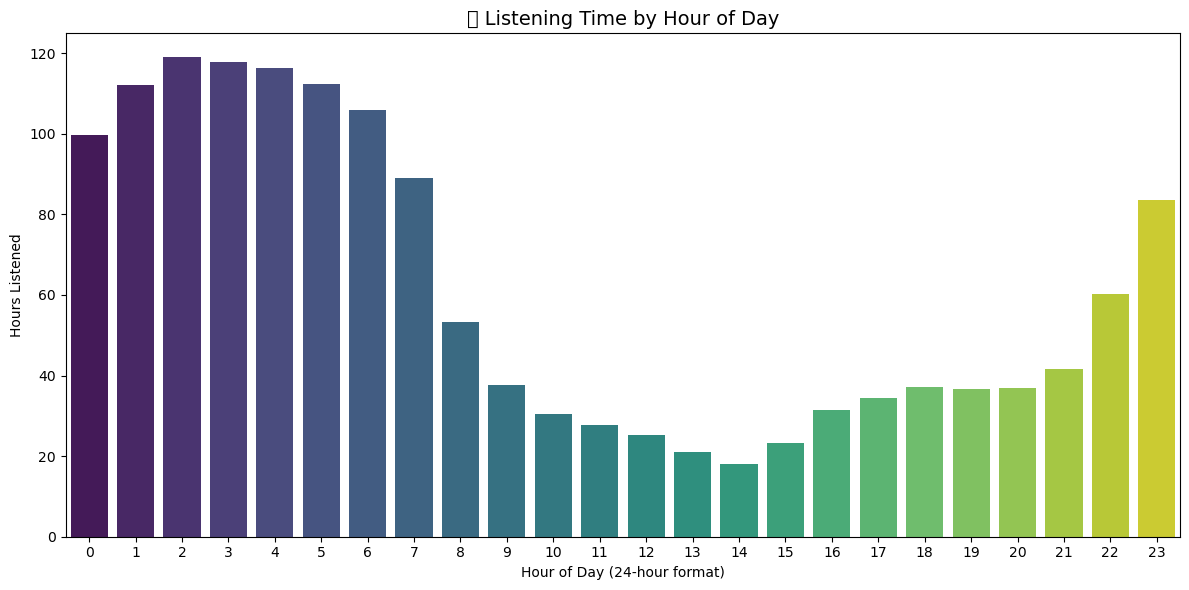

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert endTime to datetime format if not already
spotify_df['endTime'] = pd.to_datetime(spotify_df['endTime'])

# Extract hour from endTime
spotify_df['hour'] = spotify_df['endTime'].dt.hour

# Group by hour and sum msPlayed
hourly_listening = (
    spotify_df.groupby('hour')['msPlayed']
    .sum()
    .reset_index()
)

# Convert msPlayed to hours for readability
hourly_listening['Hours Listened'] = hourly_listening['msPlayed'] / (1000 * 60 * 60)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=hourly_listening, x='hour', y='Hours Listened', palette='viridis')

plt.title("🎶 Listening Time by Hour of Day", fontsize=14)
plt.xlabel("Hour of Day (24-hour format)")
plt.ylabel("Hours Listened")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/3504457555.py:18: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


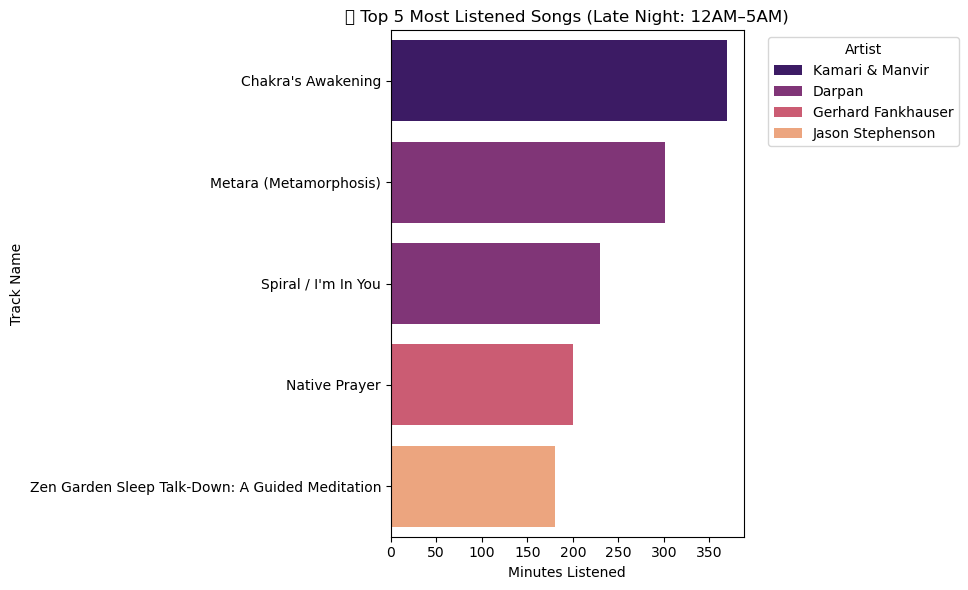

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_late_night_tracks,
    y='trackName',
    x='Minutes Listened',
    hue='artistName',
    dodge=False,
    palette='magma'
)

plt.title("🌙 Top 5 Most Listened Songs (Late Night: 12AM–5AM)")
plt.xlabel("Minutes Listened")
plt.ylabel("Track Name")
plt.legend(title='Artist', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/1266415302.py:18: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


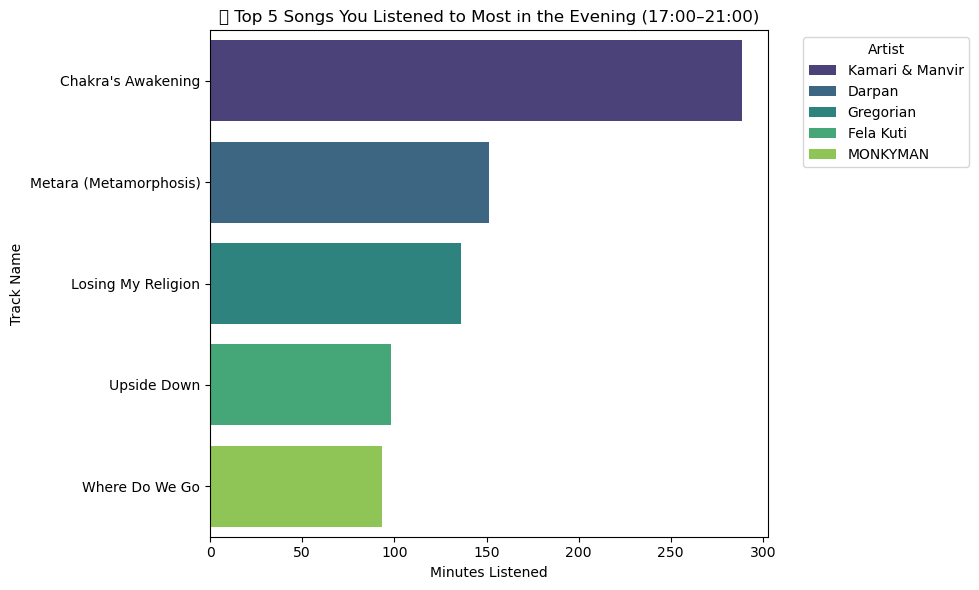

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_evening_tracks,
    x='Minutes Listened',
    y='trackName',
    hue='artistName',
    dodge=False,
    palette='viridis'
)

plt.title("🎧 Top 5 Songs You Listened to Most in the Evening (17:00–21:00)")
plt.xlabel("Minutes Listened")
plt.ylabel("Track Name")
plt.legend(title='Artist', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



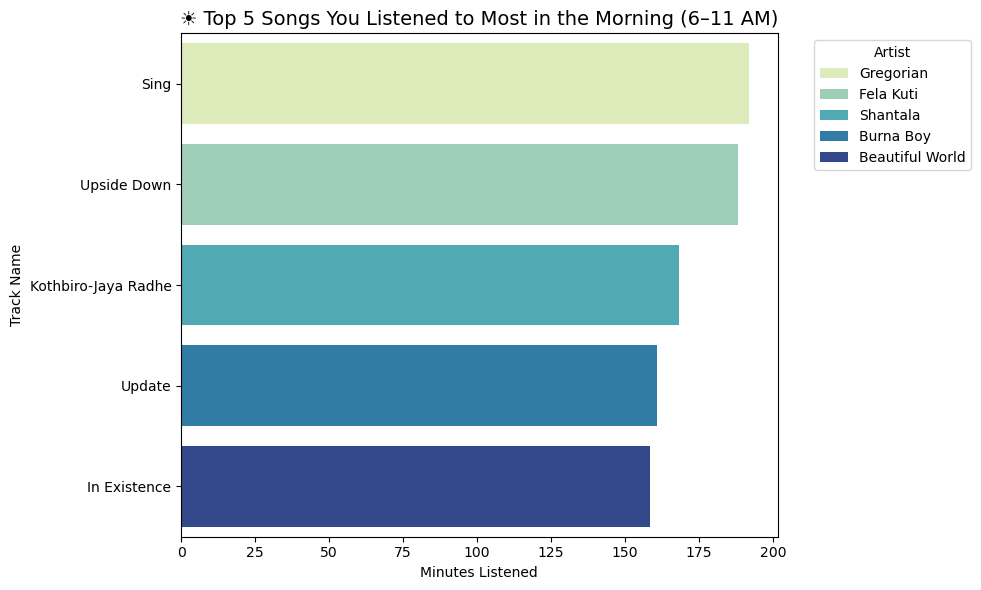

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_morning_tracks,
    x='Minutes Listened',
    y='trackName',
    hue='artistName',
    palette='YlGnBu',
    dodge=False
)

plt.title("☀️ Top 5 Songs You Listened to Most in the Morning (6–11 AM)", fontsize=14)
plt.xlabel("Minutes Listened")
plt.ylabel("Track Name")
plt.legend(title="Artist", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/3185278000.py:18: UserWarning: Glyph 127774 (\N{SUN WITH FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127774 (\N{SUN WITH FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


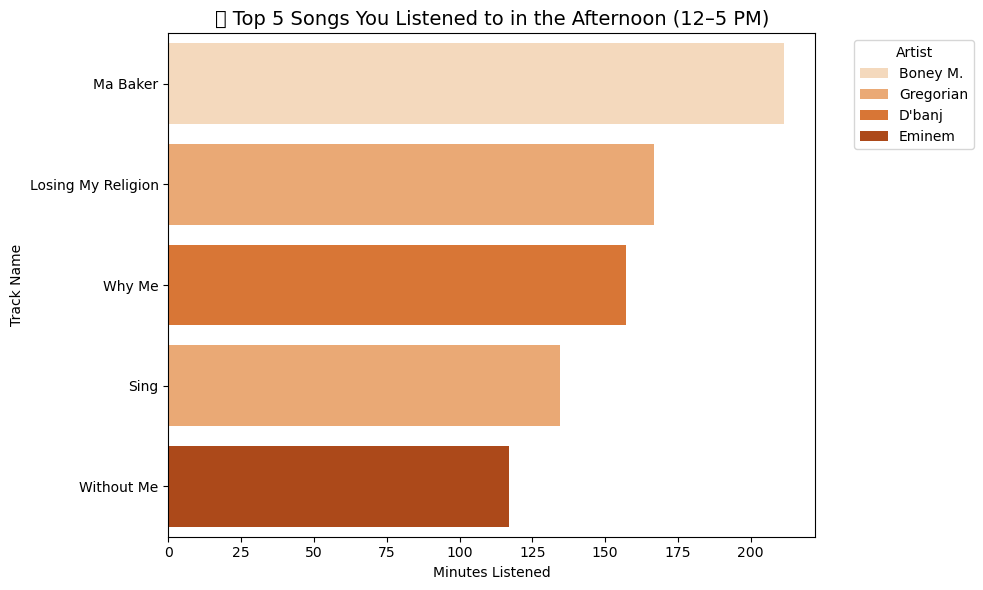

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_afternoon_tracks,
    x='Minutes Listened',
    y='trackName',
    hue='artistName',
    palette='Oranges',
    dodge=False
)

plt.title("🌞 Top 5 Songs You Listened to in the Afternoon (12–5 PM)", fontsize=14)
plt.xlabel("Minutes Listened")
plt.ylabel("Track Name")
plt.legend(title="Artist", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/1995643037.py:18: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


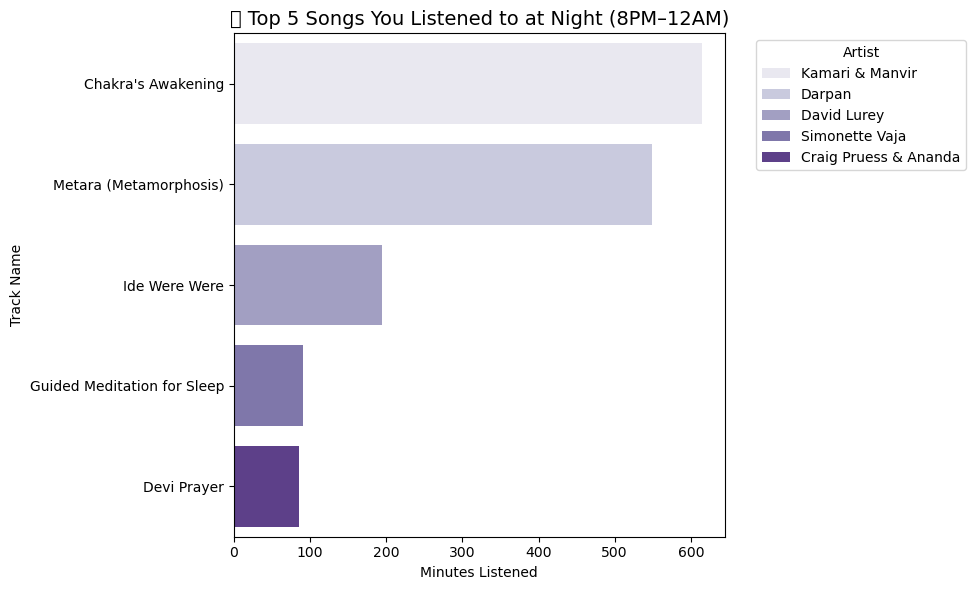

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_night_tracks,
    x='Minutes Listened',
    y='trackName',
    hue='artistName',
    palette='Purples',
    dodge=False
)

plt.title("🌙 Top 5 Songs You Listened to at Night (8PM–12AM)", fontsize=14)
plt.xlabel("Minutes Listened")
plt.ylabel("Track Name")
plt.legend(title="Artist", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [133]:
import pandas as pd

# Make sure timestamp is datetime
spotify_df['endTime'] = pd.to_datetime(spotify_df['endTime'])

# Extract the hour
spotify_df['hour'] = spotify_df['endTime'].dt.hour

# Filter early morning (5AM to 8AM)
early_df = spotify_df[(spotify_df['hour'] >= 5) & (spotify_df['hour'] < 8)]

# Group by track and artist, sum time
top_early_tracks = (
    early_df.groupby(['trackName', 'artistName'])['msPlayed']
    .sum()
    .reset_index()
)

# Convert to minutes
top_early_tracks['Minutes Listened'] = top_early_tracks['msPlayed'] / (1000 * 60)

# Get top 5
top_early_tracks = top_early_tracks.sort_values(by='Minutes Listened', ascending=False).head(5)


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/805726017.py:18: UserWarning: Glyph 127748 (\N{SUNRISE OVER MOUNTAINS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127748 (\N{SUNRISE OVER MOUNTAINS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


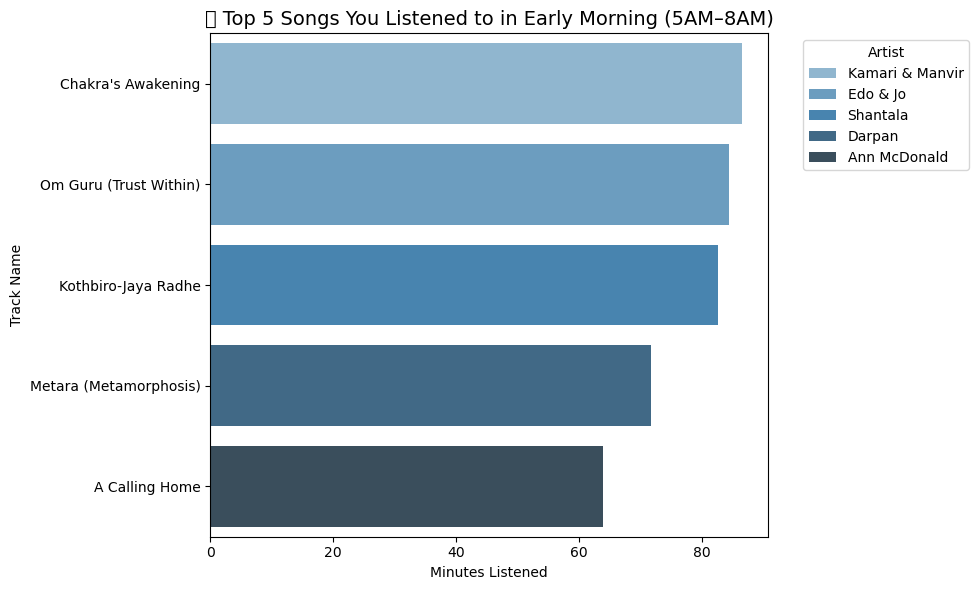

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_early_tracks,
    x='Minutes Listened',
    y='trackName',
    hue='artistName',
    palette='Blues_d',
    dodge=False
)

plt.title("🌄 Top 5 Songs You Listened to in Early Morning (5AM–8AM)", fontsize=14)
plt.xlabel("Minutes Listened")
plt.ylabel("Track Name")
plt.legend(title="Artist", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/139012312.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekday_time, x='weekday', y='Hours Listened', palette='magma')
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/139012312.py:30: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


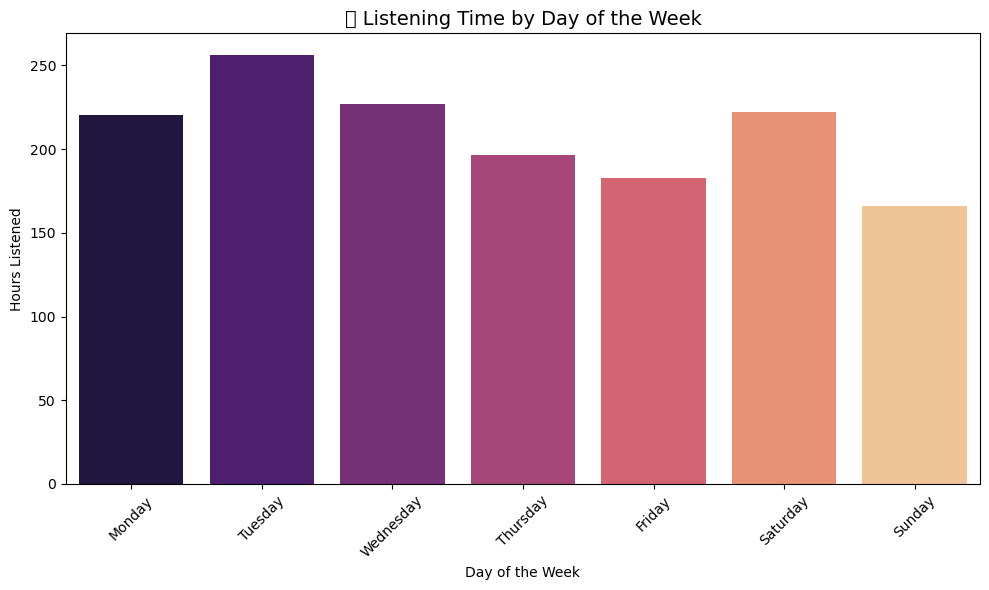

In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'date' column is datetime
spotify_df['date'] = pd.to_datetime(spotify_df['date'])

# Extract weekday name (e.g., Monday, Tuesday)
spotify_df['weekday'] = spotify_df['date'].dt.day_name()

# Group by weekday and sum up msPlayed
weekday_time = (
    spotify_df.groupby('weekday')['msPlayed']
    .sum()
    .reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])  # ordered
    .reset_index()
)

# Convert msPlayed to hours for better readability (optional)
weekday_time['Hours Listened'] = weekday_time['msPlayed'] / (1000 * 60 * 60)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=weekday_time, x='weekday', y='Hours Listened', palette='magma')

plt.title("🎧 Listening Time by Day of the Week", fontsize=14)
plt.xlabel("Day of the Week")
plt.ylabel("Hours Listened")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [138]:
# Ensure timestamp column is datetime
spotify_df['endTime'] = pd.to_datetime(spotify_df['endTime'], errors='coerce')

# Extract month name
spotify_df['month'] = spotify_df['endTime'].dt.month_name()

# Now filter for September
september_tracks = spotify_df[spotify_df['month'].str.lower() == 'september']

# Group by track name and sum msPlayed
top_5_tracks_september = (
    september_tracks.groupby('trackName')['msPlayed']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

# Rename columns
top_5_tracks_september.columns = ['Track Name', 'Total msPlayed']

# Display
print(top_5_tracks_september)


                  Track Name  Total msPlayed
0         Losing My Religion        11788975
1         Chakra's Awakening        11459040
2        Kothbiro-Jaya Radhe         9991092
3  Wieso tust Du dir das an?         8050027
4     Metara (Metamorphosis)         7383979


In [139]:
# Ensure endTime is in datetime format
spotify_df['endTime'] = pd.to_datetime(spotify_df['endTime'])

# Extract hour if not already done
spotify_df['hour'] = spotify_df['endTime'].dt.hour

# Filter for early morning (5AM–7:59AM)
early_morning_df = spotify_df[spotify_df['hour'].between(5, 7)]

# Group by track and artist, sum msPlayed
top_early_tracks = (
    early_morning_df
    .groupby(['trackName', 'artistName'])['msPlayed']
    .sum()
    .reset_index()
    .sort_values(by='msPlayed', ascending=False)
    .head(5)
)

# Convert msPlayed to minutes
top_early_tracks['Minutes Listened'] = top_early_tracks['msPlayed'] / (1000 * 60)

# Display results
print(top_early_tracks[['trackName', 'artistName', 'Minutes Listened']])


                   trackName       artistName  Minutes Listened
427       Chakra's Awakening  Kamari & Manvir         86.509900
1202  Om Guru (Trust Within)         Edo & Jo         84.373200
951      Kothbiro-Jaya Radhe         Shantala         82.625517
1090  Metara (Metamorphosis)           Darpan         71.791567
174           A Calling Home     Ann McDonald         63.900433


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/1063741072.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/1063741072.py:15: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


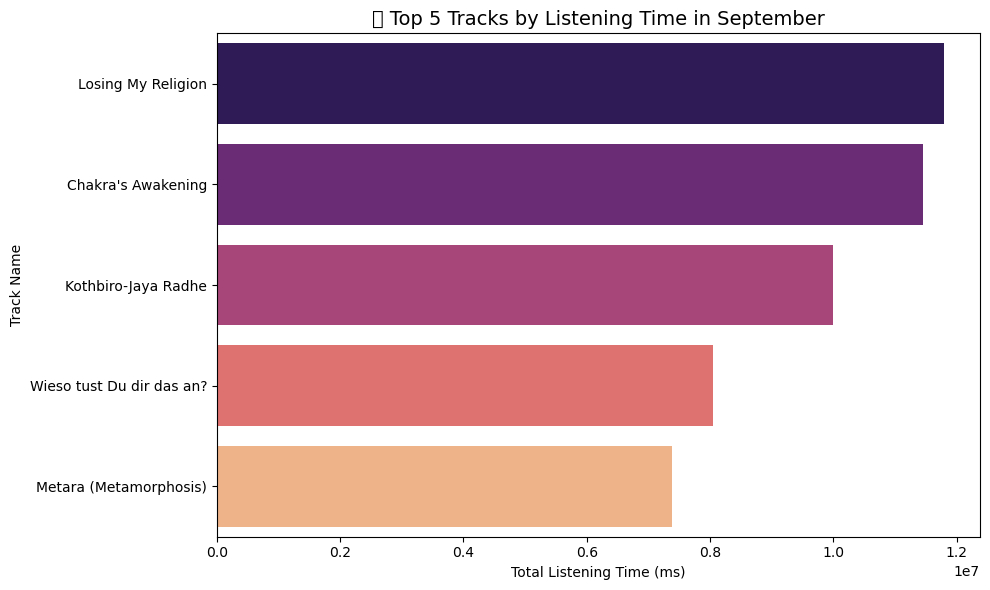

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_5_tracks_september,
    y='Track Name',
    x='Total msPlayed',
    palette='magma'
)

plt.title("🎧 Top 5 Tracks by Listening Time in September", fontsize=14)
plt.xlabel("Total Listening Time (ms)")
plt.ylabel("Track Name")
plt.tight_layout()
plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/1949194861.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/1949194861.py:28: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


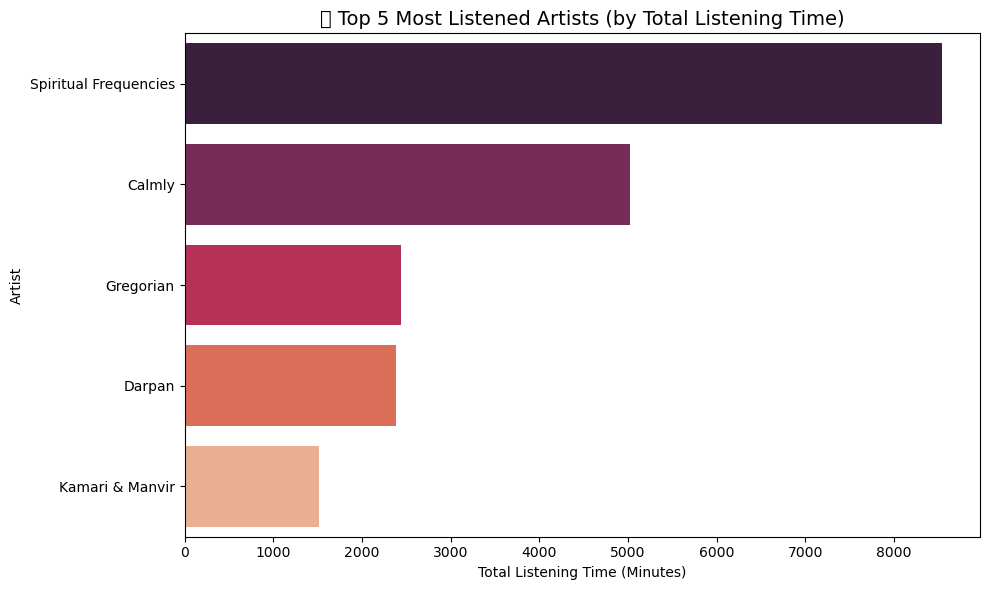

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by artist and sum the total listening time
top_artists_time = (
    spotify_df.groupby('artistName')['msPlayed']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

# Convert msPlayed to hours or minutes if you'd like
top_artists_time['Minutes Played'] = (top_artists_time['msPlayed'] / 60000).round(2)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_artists_time,
    x='Minutes Played',
    y='artistName',
    palette='rocket'
)

plt.title("🎧 Top 5 Most Listened Artists (by Total Listening Time)", fontsize=14)
plt.xlabel("Total Listening Time (Minutes)")
plt.ylabel("Artist")
plt.tight_layout()
plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/4002748510.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


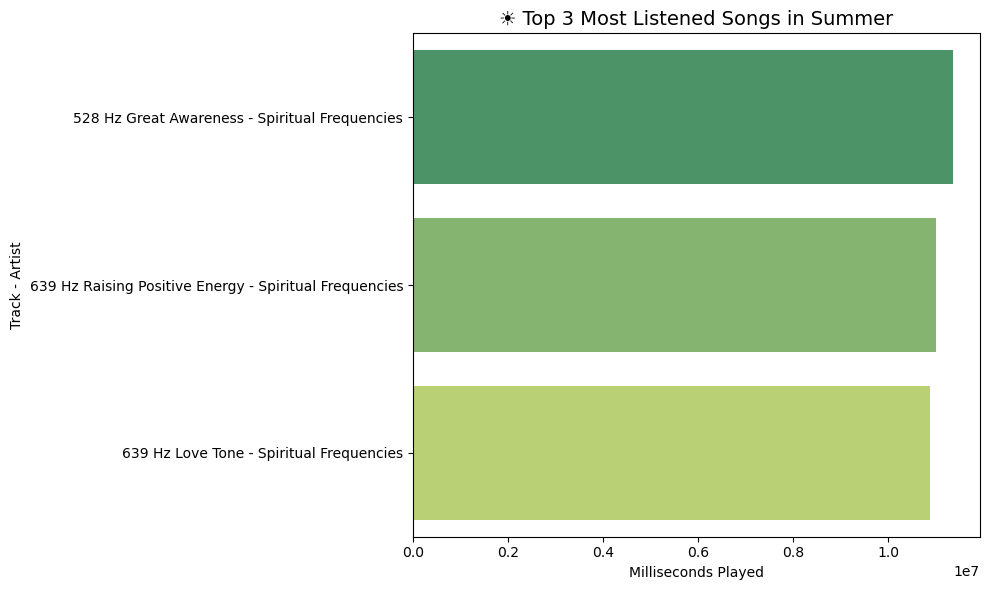

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for summer season
summer_df = spotify_df[spotify_df['season'].str.lower() == 'summer']

# Group by track and artist, sum msPlayed
top_summer_tracks = (
    summer_df.groupby(['trackName', 'artistName'])['msPlayed']
    .sum()
    .reset_index()
    .sort_values(by='msPlayed', ascending=False)
    .head(3)
)

# Combine track and artist for clearer labels
top_summer_tracks['label'] = top_summer_tracks['trackName'] + " - " + top_summer_tracks['artistName']

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_summer_tracks,
    y='label',
    x='msPlayed',
    palette='summer'
)

plt.title("☀️ Top 3 Most Listened Songs in Summer", fontsize=14)
plt.xlabel("Milliseconds Played")
plt.ylabel("Track - Artist")
plt.tight_layout()
plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/1365741981.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


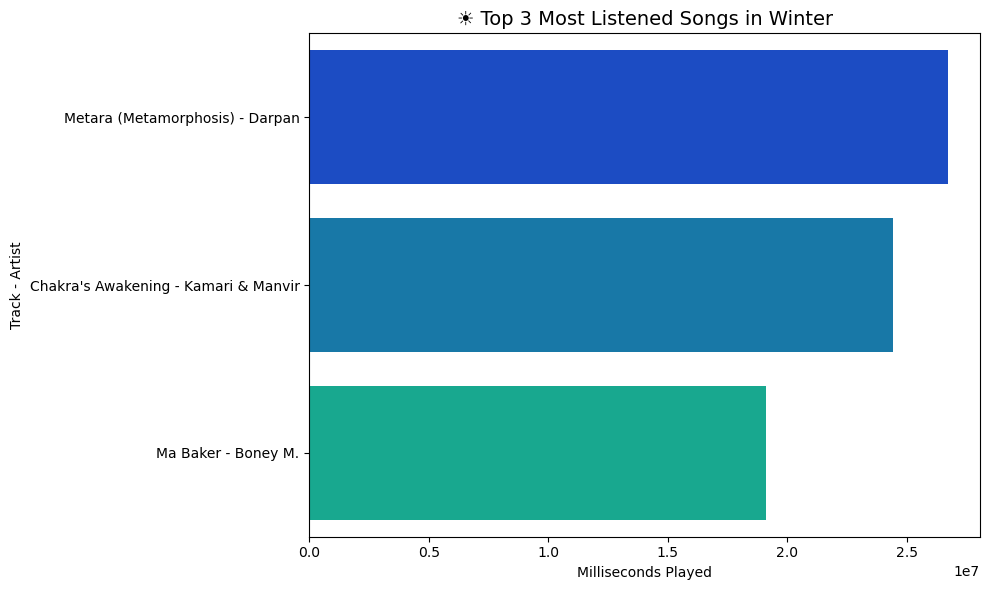

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for summer season
winter_df = spotify_df[spotify_df['season'].str.lower() == 'winter']

# Group by track and artist, sum msPlayed
top_winter_tracks = (
    winter_df.groupby(['trackName', 'artistName'])['msPlayed']
    .sum()
    .reset_index()
    .sort_values(by='msPlayed', ascending=False)
    .head(3)
)

# Combine track and artist for clearer labels
top_winter_tracks['label'] = top_winter_tracks['trackName'] + " - " + top_winter_tracks['artistName']

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_winter_tracks,
    y='label',
    x='msPlayed',
    palette='winter'
)

plt.title("☀️ Top 3 Most Listened Songs in Winter", fontsize=14)
plt.xlabel("Milliseconds Played")
plt.ylabel("Track - Artist")
plt.tight_layout()
plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/1658877941.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


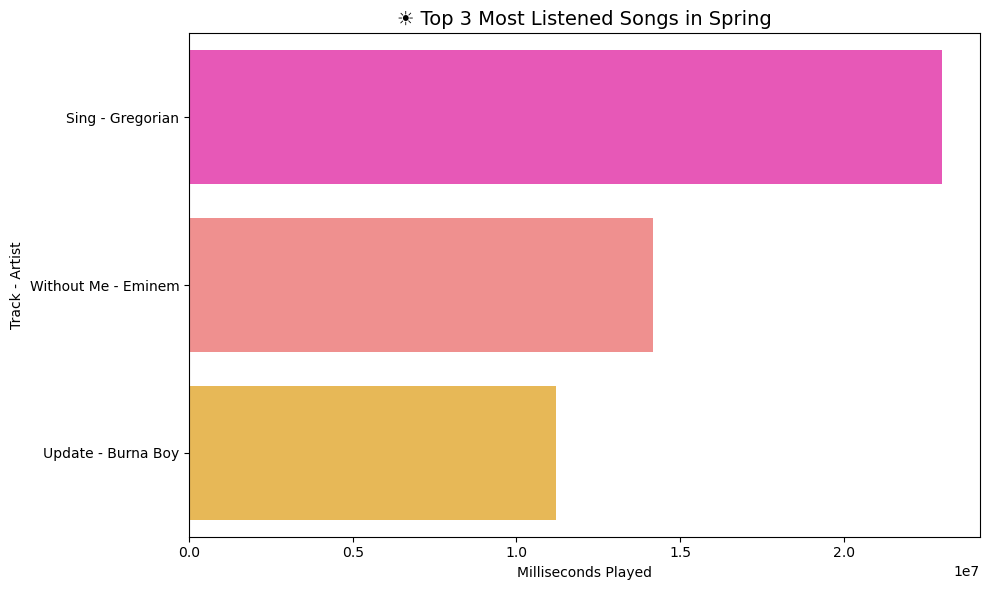

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for summer season
spring_df = spotify_df[spotify_df['season'].str.lower() == 'spring']

# Group by track and artist, sum msPlayed
top_spring_tracks = (
    spring_df.groupby(['trackName', 'artistName'])['msPlayed']
    .sum()
    .reset_index()
    .sort_values(by='msPlayed', ascending=False)
    .head(3)
)

# Combine track and artist for clearer labels
top_spring_tracks['label'] = top_spring_tracks['trackName'] + " - " + top_spring_tracks['artistName']

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_spring_tracks,
    y='label',
    x='msPlayed',
    palette='spring'
)

plt.title("☀️ Top 3 Most Listened Songs in Spring", fontsize=14)
plt.xlabel("Milliseconds Played")
plt.ylabel("Track - Artist")
plt.tight_layout()
plt.show()


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/3297141017.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


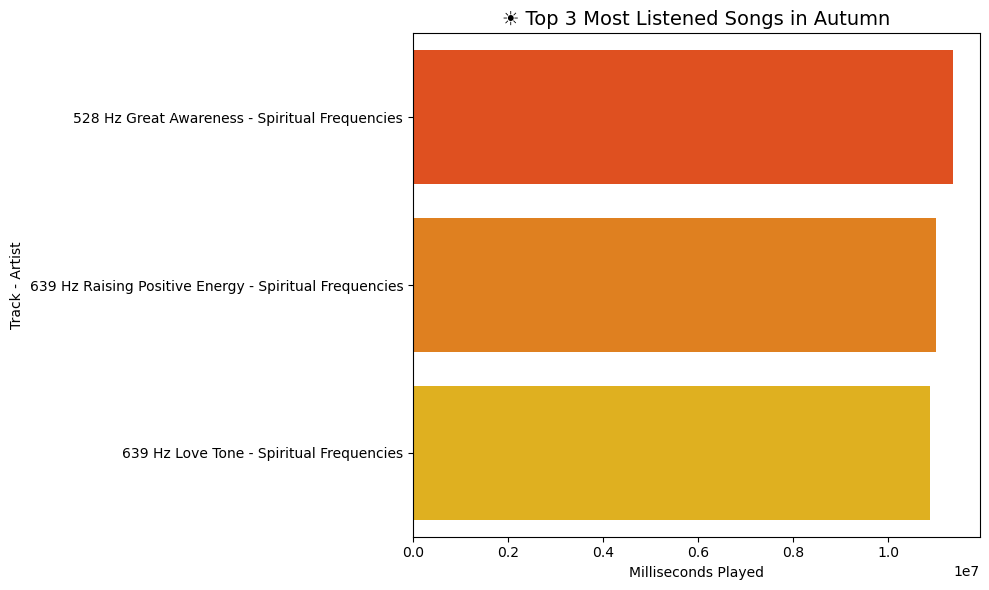

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for summer season
autumn_df = spotify_df[spotify_df['season'].str.lower() == 'autumn']

# Group by track and artist, sum msPlayed
top_autumn_tracks = (
    autumn_df.groupby(['trackName', 'artistName'])['msPlayed']
    .sum()
    .reset_index()
    .sort_values(by='msPlayed', ascending=False)
    .head(3)
)

# Combine track and artist for clearer labels
top_autumn_tracks['label'] = top_autumn_tracks['trackName'] + " - " + top_autumn_tracks['artistName']

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_summer_tracks,
    y='label',
    x='msPlayed',
    palette='autumn'
)

plt.title("☀️ Top 3 Most Listened Songs in Autumn", fontsize=14)
plt.xlabel("Milliseconds Played")
plt.ylabel("Track - Artist")
plt.tight_layout()
plt.show()


🎶 You listened to the most music in **September** with 4474 tracks!


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/747439799.py:26: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


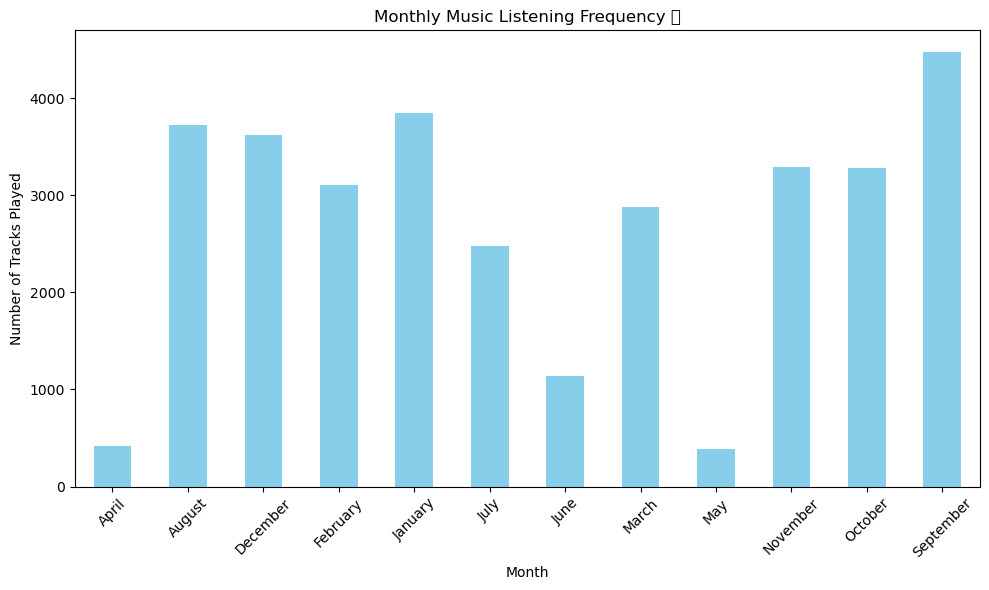

In [146]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure endTime is in datetime format
spotify_df['endTime'] = pd.to_datetime(spotify_df['endTime'])

# Extract month name
spotify_df['month'] = spotify_df['endTime'].dt.month_name()

# Count number of tracks per month
monthly_counts = spotify_df['month'].value_counts().sort_index()

# Display the month you listened the most
most_listened_month = monthly_counts.idxmax()
most_listened_count = monthly_counts.max()

print(f"🎶 You listened to the most music in **{most_listened_month}** with {most_listened_count} tracks!")

# Optional: Plot
plt.figure(figsize=(10, 6))
monthly_counts.plot(kind='bar', color='skyblue')
plt.title("Monthly Music Listening Frequency 🎧")
plt.xlabel("Month")
plt.ylabel("Number of Tracks Played")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


📅 You listened to the most music on **2024-08-13** with 364 tracks!


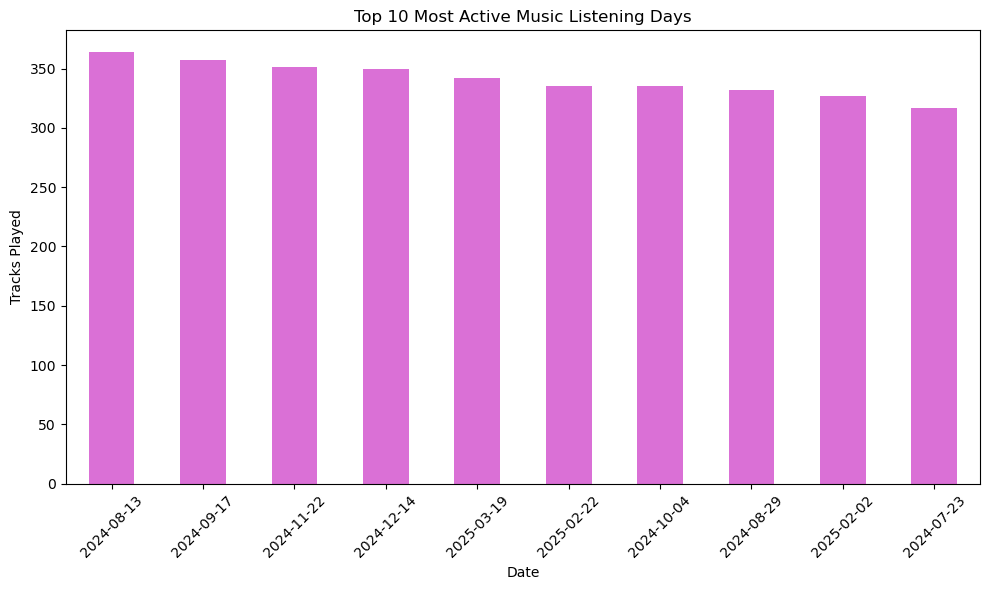

In [147]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure endTime is in datetime format
spotify_df['endTime'] = pd.to_datetime(spotify_df['endTime'])

# Extract date only (no time)
spotify_df['date'] = spotify_df['endTime'].dt.date

# Count tracks played per date
daily_counts = spotify_df['date'].value_counts().sort_index()

# Get the most active day
top_day = daily_counts.idxmax()
top_day_count = daily_counts.max()

print(f"📅 You listened to the most music on **{top_day}** with {top_day_count} tracks!")

# Optional: Plot top 10 most active days
top_10_days = daily_counts.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_10_days.plot(kind='bar', color='orchid')
plt.title("Top 10 Most Active Music Listening Days")
plt.xlabel("Date")
plt.ylabel("Tracks Played")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Convert endTime to datetime if it isn't already
spotify_df['endTime'] = pd.to_datetime(spotify_df['endTime'])

# Extract the date
spotify_df['date'] = spotify_df['endTime'].dt.date

# Find the day with the most listening activity
most_active_day = df['date'].value_counts().idxmax()
print("📅 Most active listening day:", most_active_day)


📅 Most active listening day: 2024-08-13


📅 Most active listening day: 2024-08-13
🎶 Top songs and artists on that day:
                       trackName             artistName  play_count
1     396 Hz Finding Inner Peace  Spiritual Frequencies           8
2     396 Hz Guilt & Fear Relief  Spiritual Frequencies           8
9      417 Hz Removing Blockages  Spiritual Frequencies           8
5  396 Hz Turning Grief Into Joy  Spiritual Frequencies           8
8       417 Hz Facilitate Change  Spiritual Frequencies           8


/var/folders/5d/2f43d6ts64x5bt51z8p0j2dc0000gn/T/ipykernel_17665/741793298.py:42: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


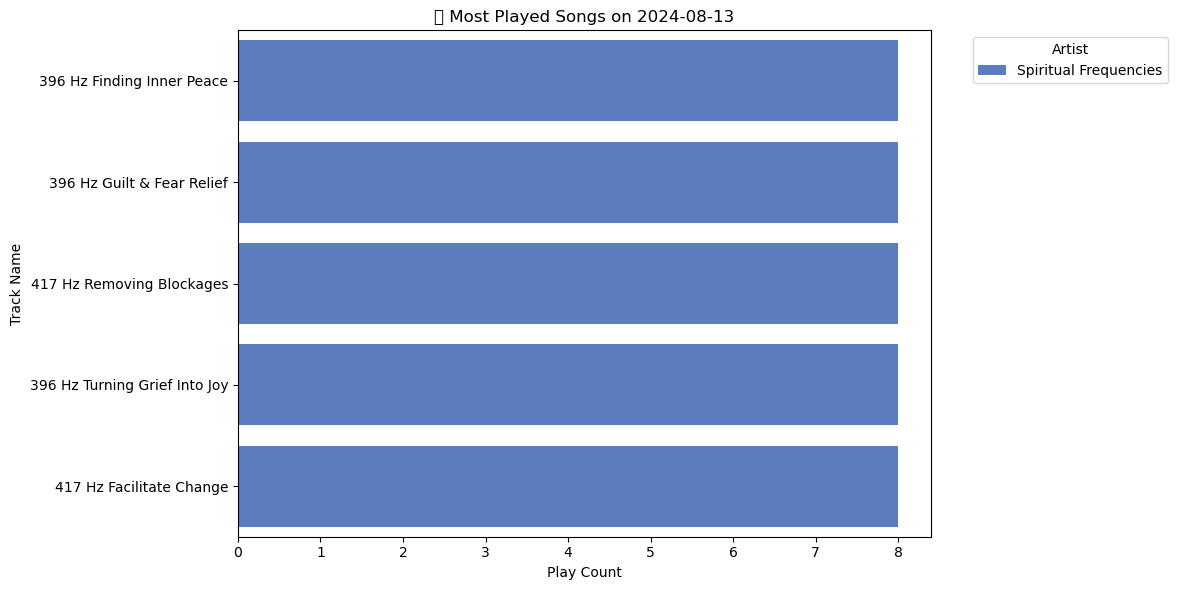

In [148]:
# Convert endTime to datetime if it isn't already
spotify_df['endTime'] = pd.to_datetime(spotify_df['endTime'])

# Extract the date
spotify_df['date'] = spotify_df['endTime'].dt.date

# Find the day with the most listening activity
most_active_day = spotify_df['date'].value_counts().idxmax()
print("📅 Most active listening day:", most_active_day)


# Filter songs played on the most active day
top_day_df = spotify_df[spotify_df['date'] == most_active_day]

# Group by track and artist, count plays
most_played_tracks = (
    top_day_df
    .groupby(['trackName', 'artistName'])
    .size()
    .reset_index(name='play_count')
    .sort_values(by='play_count', ascending=False)
)

print("🎶 Top songs and artists on that day:")
print(most_played_tracks.head(5))

# Plot bar chart of top played tracks
plt.figure(figsize=(12, 6))
sns.barplot(
    data=most_played_tracks.head(5),
    x='play_count',
    y='trackName',
    hue='artistName',
    dodge=False,
    palette='muted'
)

plt.title(f"🎵 Most Played Songs on {most_active_day}")
plt.xlabel("Play Count")
plt.ylabel("Track Name")
plt.legend(title='Artist', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



# Location API

# GEMINI AI API

In [149]:
import sys
print(sys.path)

['/Users/alexnnadi/anaconda3/envs/Exp/lib/python312.zip', '/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12', '/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/lib-dynload', '', '/Users/alexnnadi/anaconda3/envs/Exp/lib/python3.12/site-packages']


In [150]:
import os
from dotenv import load_dotenv

# Load variables from .env file
load_dotenv()

# Access your API key
GEMINI_API = os.getenv("Gemini_API")

#print(GEMINI_API)  # Just to confirm it's loading correctly


# Summarizing my Weather and Spotify API with GeminiAI API

# Summer Dairy Summary

In [242]:
# 🎵 Spotify Summary - Top 3 Genres by Listening Time in Summer
spotify_summary = spotify_df[spotify_df['season'] == 'Summer'] \
    .groupby('main_genre')['msPlayed'].sum() \
    .sort_values(ascending=False).head(3)

# Convert msPlayed to minutes for display
spotify_summary_minutes = (spotify_summary / 60000).round(2)
print("🎧 Top 3 Most Listened Genres in Summer (by Minutes):")
print(spotify_summary_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🎤 Top 3 Most Listened Artists in Summer
top_artists_summer = spotify_df[spotify_df['season'] == 'Summer'] \
    .groupby('artistName')['msPlayed'].sum() \
    .sort_values(ascending=False).head(3)
top_artists_minutes = (top_artists_summer / 60000).round(2)

print("🎤 Top 3 Most Listened Artists in Summer:")
print(top_artists_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🎶 Top 3 Most Listened Songs in Summer
top_songs_summer = spotify_df[spotify_df['season'] == 'Summer'] \
    .groupby('trackName')['msPlayed'].sum() \
    .sort_values(ascending=False).head(3)
top_songs_minutes = (top_songs_summer / 60000).round(2)

print("🎶 Top 3 Most Listened Songs in Summer:")
print(top_songs_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🌦️ Weather Summary - Avg Temp, Precip, Windspeed in Summer for Berlin only
weather_summary = weather_df[
    (weather_df['season'] == 'Summer') &
    (weather_df['city'].str.lower().str.strip() == 'berlin')
].groupby('city')[['temp', 'precip', 'windspeed']].mean()

print("🌞 Average Summer Weather in Berlin:")
print(weather_summary.to_string(float_format='%.1f'))

# 👕 Clothing Recommendation (from dataset) - Summer in Berlin
clothing_recs = weather_df[
    (weather_df['season'] == 'Summer') &
    (weather_df['city'].str.lower().str.strip() == 'berlin')
]['clothing_recommendation'].dropna().unique()

print("\n🧥 Clothing Recommendation for Berlin in Summer:")
for rec in clothing_recs:
    print(f"- {rec}")



🎧 Top 3 Most Listened Genres in Summer (by Minutes):
main_genre
Unknown          11687.71
afrobeats          588.60
organic house      230.88

--------------------------------------------------

🎤 Top 3 Most Listened Artists in Summer:
artistName
Spiritual Frequencies    7403.64
Calmly                   1250.40
Dhyana Dan                887.84

--------------------------------------------------

🎶 Top 3 Most Listened Songs in Summer:
trackName
528 Hz Great Awareness            189.40
639 Hz Raising Positive Energy    183.53
639 Hz Love Tone                  181.35

--------------------------------------------------

🌞 Average Summer Weather in Berlin:
        temp  precip  windspeed
city                           
Berlin  68.0     0.1       11.9

🧥 Clothing Recommendation for Berlin in Summer:
- 👕 T-shirt, jeans/skirt, light sneakers ☔ (Umbrella recommended) 🕶️ (Sunscreen & sunglasses)
- 👕 T-shirt, jeans/skirt, light sneakers 🕶️ (Sunscreen & sunglasses)
- 🧶 Hoodie or light jacket, jean

In [157]:
summary_text = f"""
🎧 **Top Music Genres in Summer** (by msPlayed):
{spotify_summary.to_string()}

🎤 **Top 3 Artists in Summer**:
{top_artists_summer.to_string()}

🎶 **Top 3 Songs in Summer**:
{top_songs_summer.to_string()}

🌞 **Average Summer Weather in Berlin**:
{weather_summary.to_string(float_format='%.1f')}
"""

print(summary_text)



🎧 **Top Music Genres in Summer** (by msPlayed):
main_genre
Unknown          701262787
afrobeats         35316135
organic house     13852952

🎤 **Top 3 Artists in Summer**:
artistName
Spiritual Frequencies    444218426
Calmly                    75023900
Dhyana Dan                53270670

🎶 **Top 3 Songs in Summer**:
trackName
528 Hz Great Awareness            11364065
639 Hz Raising Positive Energy    11011680
639 Hz Love Tone                  10881058

🌞 **Average Summer Weather in Berlin**:
        temp  precip  windspeed
city                           
Berlin  68.0     0.1       11.9



In [243]:
import os
import pandas as pd
from datetime import datetime
from google import generativeai as genai
from dotenv import load_dotenv

# Load API key from .env
load_dotenv()

GEMINI_API = os.getenv("Gemini_API")


genai.configure(api_key=GEMINI_API)

model = genai.GenerativeModel("gemini-1.5-flash")

prompt = f"""
Write a personal summer diary entry based on this data:

🎧 Top Genres in Summer:
{spotify_summary.to_string()}

🎤 Top 3 Artists in Summer:
{top_artists_summer.to_string()}

🎶 Top 3 Songs in Summer:
{top_songs_summer.to_string()}

🌞 Weather Summary (Berlin):
{weather_summary.to_string(float_format='%.1f')}

👕 Clothing Recommendations for Summer in Berlin:
{clothing_recs}

Make it casual, reflective, and maybe a bit poetic!
"""

response = model.generate_content(prompt)

print(response.text)


July 14th, Berlin

Another Berlin summer day melting into the evening.  The air hung thick and sweet, a 68-degree hug with a playful 11.9 mph wind teasing my hair.  A tiny sprinkle – barely enough to call it rain – just enough to make the city shimmer.  My playlist?  A chaotic mix, reflecting the summer itself.  It started with the soothing frequencies of Spiritual Frequencies –  perfect for those lazy afternoons lost in a good book – and then somehow spiralled into a vibrant burst of Afrobeats that had me dancing in my tiny apartment.  

I’ve been living off of the “528 Hz Great Awareness” track lately. It’s my little pocket of calm amidst the buzzing city.   Funny, how music can encapsulate a feeling so completely.  These summer sounds, this weather – they all seem to merge into this hazy, beautiful whole.

The day started with a T-shirt, jeans, and those light sneakers I love so much, a quick grab for my sunglasses and a sigh of relief when I realised I'd grabbed my umbrella too!  B

## Autumn Dairy Summery

In [245]:
# 🎵 Spotify Summary - Top 3 Genres by Listening Time in Autumn
spotify_autumn = spotify_df[spotify_df['season'] == 'Autumn'] \
    .groupby('main_genre')['msPlayed'].sum() \
    .sort_values(ascending=False).head(3)

# Convert msPlayed to minutes for display
spotify_autumn_minutes = (spotify_autumn / 60000).round(2)
print("🎧 Top 3 Most Listened Genres in Autumn (by Minutes):")
print(spotify_autumn_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🎤 Top 3 Most Listened Artists in Autumn
top_artists_autumn = spotify_df[spotify_df['season'] == 'Autumn'] \
    .groupby('artistName')['msPlayed'].sum() \
    .sort_values(ascending=False).head(3)
top_artists_autumn_minutes = (top_artists_autumn / 60000).round(2)

print("🎤 Top 3 Most Listened Artists in Autumn:")
print(top_artists_autumn_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🎶 Top 3 Most Listened Songs in Autumn
top_songs_autumn = spotify_df[spotify_df['season'] == 'Autumn'] \
    .groupby('trackName')['msPlayed'].sum() \
    .sort_values(ascending=False).head(3)
top_songs_autumn_minutes = (top_songs_autumn / 60000).round(2)

print("🎶 Top 3 Most Listened Songs in Autumn:")
print(top_songs_autumn_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🌦️ Weather Summary - Avg Temp, Precip, Windspeed in Autumn for Berlin only
weather_summary_autumn = weather_df[
    (weather_df['season'] == 'Autumn') &
    (weather_df['city'].str.lower().str.strip() == 'berlin')
].groupby('city')[['temp', 'precip', 'windspeed']].mean()

print("🌦️ Average Autumn Weather in Berlin:")
print(weather_summary_autumn.to_string(float_format='%.1f'))

# 👕 Clothing Recommendation (from dataset) - Summer in Berlin
clothing_Autumn = weather_df[
    (weather_df['season'] == 'Autumn') &
    (weather_df['city'].str.lower().str.strip() == 'berlin')
]['clothing_recommendation'].dropna().unique()

print("\n🧥 Clothing Recommendation for Berlin in Autumn:")
for rec in clothing_Autumn:
    print(f"- {rec}")


🎧 Top 3 Most Listened Genres in Autumn (by Minutes):
main_genre
Unknown            21258.87
afrobeats           3187.74
gregorian chant     1700.15

--------------------------------------------------

🎤 Top 3 Most Listened Artists in Autumn:
artistName
Calmly             2354.80
Gregorian          1688.70
Kamari & Manvir    1055.58

--------------------------------------------------

🎶 Top 3 Most Listened Songs in Autumn:
trackName
Chakra's Awakening        677.20
Metara (Metamorphosis)    520.09
Losing My Religion        377.83

--------------------------------------------------

🌦️ Average Autumn Weather in Berlin:
        temp  precip  windspeed
city                           
Berlin  51.0     0.1       12.6

🧥 Clothing Recommendation for Berlin in Autumn:
- 🧶 Hoodie or light jacket, jeans ☔ (Umbrella recommended) 🕶️ (Sunscreen & sunglasses)
- 👕 T-shirt, jeans/skirt, light sneakers
- 👕 T-shirt, jeans/skirt, light sneakers ☔ (Umbrella recommended)
- 🧶 Hoodie or light jacket, jeans 🕶️

In [247]:
summary_Autumn = f"""
🎧 **Top Music Genres in Autumn** (by Minutes):
{spotify_autumn_minutes.to_string()}

🎤 **Top 3 Artists in Autumn**:
{top_artists_autumn_minutes.to_string()}

🎶 **Top 3 Songs in Autumn**:
{top_songs_autumn_minutes.to_string()}

🌦️ **Average Autumn Weather in Berlin**:
{weather_summary_autumn.to_string(float_format='%.1f')}

"""

print(summary_text)



🎧 **Top Music Genres in Summer** (by msPlayed):
main_genre
Unknown          701262787
afrobeats         35316135
organic house     13852952

🎤 **Top 3 Artists in Summer**:
artistName
Spiritual Frequencies    444218426
Calmly                    75023900
Dhyana Dan                53270670

🎶 **Top 3 Songs in Summer**:
trackName
528 Hz Great Awareness            11364065
639 Hz Raising Positive Energy    11011680
639 Hz Love Tone                  10881058

🌞 **Average Summer Weather in Berlin**:
        temp  precip  windspeed
city                           
Berlin  68.0     0.1       11.9



In [248]:
#AUTUMN GEMINI API

import google.generativeai as genai

# Make sure GEMINI_API is defined
genai.configure(api_key=GEMINI_API)

# Load Gemini model
model = genai.GenerativeModel("gemini-2.0-flash")

# Create the Autumn prompt
prompt = f"""
Write a personal autumn diary entry based on this data:

🎧 Top Genres in Autumn:
{spotify_autumn_minutes.to_string()}

🎤 Top 3 Artists in Autumn:
{top_artists_autumn_minutes.to_string()}

🎶 Top 3 Songs in Autumn:
{top_songs_autumn_minutes.to_string()}

🌦️ Weather Summary (Berlin):
{weather_summary_autumn.to_string(float_format='%.1f')}

👕 Clothing Recommendations for Autumn in Berlin:
{clothing_Autumn}

Make it casual, reflective, and maybe a bit poetic!
"""

# Generate response from Gemini
response = model.generate_content(prompt)

# Display diary entry
print(response.text)


October 27th

The leaves are really doing their thing now. Berlin is awash in that classic autumn palette - rusty reds, burnt oranges, and the perpetually damp browns that seep into everything, even my mood, sometimes. The air is sharp, that kind of sharp that nips at your cheeks and makes you want to bury yourself in a scarf. The weather report doesn't lie – 51 degrees, a little sprinkle of rain, and a wind that bites. Hoodie weather, definitely. Or maybe even coat weather soon, if the creeping chill is anything to go by. Time to dig out the thermals, just in case!

Music-wise, my autumn has been…weird. A lot of “unknown” genres, which probably means I've been letting the algorithm take over. But there's been a surprising amount of Afrobeats sneaking in, which makes sense, I guess. Trying to hold onto some summer vibes. And then, out of nowhere, Gregorian chant? I think that's my soul yearning for something a bit more…spiritual. Gregorian's definitely been a go-to. Maybe the grey skie

## Winter Dairy Summery 

In [251]:
# 🎵 Spotify Summary - Top 3 Genres by Listening Time in Winter
spotify_winter = spotify_df[spotify_df['season'] == 'Winter'] \
    .groupby('main_genre')['msPlayed'].sum() \
    .sort_values(ascending=False).head(3)

# Convert msPlayed to minutes for display
spotify_winter_minutes = (spotify_winter / 60000).round(2)
print("🎧 Top 3 Most Listened Genres in Winter (by Minutes):")
print(spotify_winter_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🎤 Top 3 Most Listened Artists in Winter
top_artists_winter = spotify_df[spotify_df['season'] == 'Winter'] \
    .groupby('artistName')['msPlayed'].sum() \
    .sort_values(ascending=False).head(3)
top_artists_winter_minutes = (top_artists_winter / 60000).round(2)

print("🎤 Top 3 Most Listened Artists in Winter:")
print(top_artists_winter_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🎶 Top 3 Most Listened Songs in Winter
top_songs_winter = spotify_df[spotify_df['season'] == 'Winter'] \
    .groupby('trackName')['msPlayed'].sum() \
    .sort_values(ascending=False).head(3)
top_songs_winter_minutes = (top_songs_winter / 60000).round(2)

print("🎶 Top 3 Most Listened Songs in Winter:")
print(top_songs_winter_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🌦️ Weather Summary - Avg Temp, Precip, Windspeed in Winter for Berlin only
weather_summary_winter = weather_df[
    (weather_df['season'] == 'Winter') &
    (weather_df['city'].str.lower().str.strip() == 'berlin')
].groupby('city')[['temp', 'precip', 'windspeed']].mean()

print("🌨️ Average Winter Weather in Berlin:")
print(weather_summary_winter.to_string(float_format='%.1f'))

# 👕 Clothing Recommendation (from dataset) - Summer in Berlin
clothing_winter = weather_df[
    (weather_df['season'] == 'Winter') &
    (weather_df['city'].str.lower().str.strip() == 'berlin')
]['clothing_recommendation'].dropna().unique()

print("\n🧥 Clothing Recommendation for Berlin in Winter:")
for clothing in clothing_winter:
    print(f"- {clothing}")


🎧 Top 3 Most Listened Genres in Winter (by Minutes):
main_genre
Unknown      22485.74
afrobeats     2448.88
afrobeat       674.59

--------------------------------------------------

🎤 Top 3 Most Listened Artists in Winter:
artistName
Calmly    1418.53
Darpan    1250.68
Peia       565.65

--------------------------------------------------

🎶 Top 3 Most Listened Songs in Winter:
trackName
Metara (Metamorphosis)    445.43
Chakra's Awakening        407.34
Ma Baker                  318.77

--------------------------------------------------

🌨️ Average Winter Weather in Berlin:
        temp  precip  windspeed
city                           
Berlin  38.4     0.1       13.5

🧥 Clothing Recommendation for Berlin in Winter:
- 🧥 Heavy coat, thermal wear, gloves, boots
- 🧥 Heavy coat, thermal wear, gloves, boots ☔ (Umbrella recommended) ❄️ (Snow boots suggested)
- 🧥 Heavy coat, thermal wear, gloves, boots ☔ (Umbrella recommended)
- 🧥 Coat or insulated jacket, boots ☔ (Umbrella recommended)
- 🧥 Co

In [174]:
summary_Winter = f"""
🎧 **Top Music Genres in Winter** (by Minutes):
{spotify_winter_minutes.to_string()}

🎤 **Top 3 Artists in Winter**:
{top_artists_winter_minutes.to_string()}

🎶 **Top 3 Songs in Winter**:
{top_songs_winter_minutes.to_string()}

🌨️ **Average Winter Weather in Berlin**:
{weather_summary_winter.to_string(float_format='%.1f')}
"""

print(summary_Winter)



🎧 **Top Music Genres in Winter** (by Minutes):
main_genre
Unknown      22485.74
afrobeats     2448.88
afrobeat       674.59

🎤 **Top 3 Artists in Winter**:
artistName
Calmly    1418.53
Darpan    1250.68
Peia       565.65

🎶 **Top 3 Songs in Winter**:
trackName
Metara (Metamorphosis)    445.43
Chakra's Awakening        407.34
Ma Baker                  318.77

🌨️ **Average Winter Weather in Berlin**:
        temp  precip  windspeed
city                           
Berlin  38.4     0.1       13.5



In [252]:
# WINTER GEMINI API

import google.generativeai as genai

# Make sure GEMINI_API is defined
genai.configure(api_key=GEMINI_API)

# Load Gemini model
model = genai.GenerativeModel("gemini-2.0-flash")

# Create the Winter prompt
prompt = f"""
Write a personal winter diary entry based on this data:

🎧 Top Genres in Winter:
{spotify_winter_minutes.to_string()}

🎤 Top 3 Artists in Winter:
{top_artists_winter_minutes.to_string()}

🎶 Top 3 Songs in Winter:
{top_songs_winter_minutes.to_string()}

🌨️ Weather Summary (Berlin):
{weather_summary_winter.to_string(float_format='%.1f')}

👕 Clothing Recommendations for Winter in Berlin:
{clothing_winter}

Make it casual, reflective, and maybe a bit poetic!
"""

# Generate response from Gemini
response = model.generate_content(prompt)

# Display diary entry
print(response.text)


## January 27th, Berlin

The wind howls outside, a constant 13.5 mph reminder that winter isn't playing games. According to my phone, it’s 38.4°F (feels colder, naturally) and spitting a pathetic excuse for rain. My weather app is practically screaming at me to wear my heaviest coat, thermal wear, gloves, and of course, the snow boots. Not that I need much convincing to cocoon myself in wool and fleece.

Inside, though, it’s a different story. The radiator’s humming, and my ears are lost in the strange and wonderful world of “Unknown” – apparently, my music library has a lot of songs without genre tags. It’s a sonic black hole, filled with forgotten treasures and random finds. Maybe that's fitting for winter. It feels like everything slows down, everything gets a bit… unknown. A time for rediscovering things you thought you'd lost.

Calmly, Darpan, and Peia have been my constant companions these last few months. Their melodies weave a gentle magic against the starkness outside. Darpan'

## Spring Dairy Summery

In [253]:
# 🎵 Spotify Summary - Top 3 Genres by Listening Time in Spring
spotify_spring = spotify_df[spotify_df['season'] == 'Spring'] \
    .groupby('main_genre')['msPlayed'].sum() \
    .sort_values(ascending=False).head(3)

# Convert msPlayed to minutes for display
spotify_spring_minutes = (spotify_spring / 60000).round(2)
print("🎧 Top 3 Most Listened Genres in Spring (by Minutes):")
print(spotify_spring_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🎤 Top 3 Most Listened Artists in Spring
top_artists_spring = spotify_df[spotify_df['season'] == 'Spring'] \
    .groupby('artistName')['msPlayed'].sum() \
    .sort_values(ascending=False).head(3)
top_artists_spring_minutes = (top_artists_spring / 60000).round(2)

print("🎤 Top 3 Most Listened Artists in Spring:")
print(top_artists_spring_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🎶 Top 3 Most Listened Songs in Spring
top_songs_spring = spotify_df[spotify_df['season'] == 'Spring'] \
    .groupby('trackName')['msPlayed'].sum() \
    .sort_values(ascending=False).head(3)
top_songs_spring_minutes = (top_songs_spring / 60000).round(2)

print("🎶 Top 3 Most Listened Songs in Spring:")
print(top_songs_spring_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🌦️ Weather Summary - Avg Temp, Precip, Windspeed in Spring for Berlin only
weather_summary_spring = weather_df[
    (weather_df['season'] == 'Spring') &
    (weather_df['city'].str.lower().str.strip() == 'berlin')
].groupby('city')[['temp', 'precip', 'windspeed']].mean()

print("🌸 Average Spring Weather in Berlin:")
print(weather_summary_spring.to_string(float_format='%.1f'))

# 👕 Clothing Recommendation (from dataset) - Summer in Berlin
clothing_spring = weather_df[
    (weather_df['season'] == 'Spring') &
    (weather_df['city'].str.lower().str.strip() == 'berlin')
]['clothing_recommendation'].dropna().unique()

print("\n🧥 Clothing Recommendation for Berlin in Winter:")
for clothing in clothing_spring:
    print(f"- {clothing}")


🎧 Top 3 Most Listened Genres in Spring (by Minutes):
main_genre
Unknown            5137.97
afrobeats          1315.70
gregorian chant     761.96

--------------------------------------------------

🎤 Top 3 Most Listened Artists in Spring:
artistName
Gregorian                729.81
Burna Boy                322.25
Spiritual Frequencies    297.66

--------------------------------------------------

🎶 Top 3 Most Listened Songs in Spring:
trackName
Sing          383.53
Without Me    236.28
Update        186.95

--------------------------------------------------

🌸 Average Spring Weather in Berlin:
        temp  precip  windspeed
city                           
Berlin  51.8     0.0       12.5

🧥 Clothing Recommendation for Berlin in Winter:
- 🧥 Coat or insulated jacket, boots
- 🧥 Coat or insulated jacket, boots ☔ (Umbrella recommended)
- 🧶 Hoodie or light jacket, jeans
- 🧥 Coat or insulated jacket, boots 🕶️ (Sunscreen & sunglasses)
- 🧥 Heavy coat, thermal wear, gloves, boots 🕶️ (Sunscreen & 

In [177]:
summary_Spring = f"""
🎧 **Top Music Genres in Spring** (by Minutes):
{spotify_spring_minutes.to_string()}

🎤 **Top 3 Artists in Spring**:
{top_artists_spring_minutes.to_string()}

🎶 **Top 3 Songs in Spring**:
{top_songs_spring_minutes.to_string()}

🌸 **Average Spring Weather in Berlin**:
{weather_summary_spring.to_string(float_format='%.1f')}
"""

print(summary_Spring)



🎧 **Top Music Genres in Spring** (by Minutes):
main_genre
Unknown            5137.97
afrobeats          1315.70
gregorian chant     761.96

🎤 **Top 3 Artists in Spring**:
artistName
Gregorian                729.81
Burna Boy                322.25
Spiritual Frequencies    297.66

🎶 **Top 3 Songs in Spring**:
trackName
Sing          383.53
Without Me    236.28
Update        186.95

🌸 **Average Spring Weather in Berlin**:
        temp  precip  windspeed
city                           
Berlin  51.8     0.0       12.5



In [254]:
# SPRING GEMINI API

import google.generativeai as genai

# Make sure GEMINI_API is defined
genai.configure(api_key=GEMINI_API)

# Load Gemini model
model = genai.GenerativeModel("gemini-2.0-flash")

# Create the Spring prompt
prompt = f"""
Write a personal spring diary entry based on this data:

🎧 Top Genres in Spring:
{spotify_spring_minutes.to_string()}

🎤 Top 3 Artists in Spring:
{top_artists_spring_minutes.to_string()}

🎶 Top 3 Songs in Spring:
{top_songs_spring_minutes.to_string()}

🌸 Weather Summary (Berlin):
{weather_summary_spring.to_string(float_format='%.1f')}

👕 Clothing Recommendations for Spring in Berlin:
{clothing_spring}

Make it casual, reflective, and maybe a bit poetic!
"""

# Generate response from Gemini
response = model.generate_content(prompt)

# Display diary entry
print(response.text)


April 17th, Berlin

Ugh, another day, another confusing Berlin spring day. 51 degrees Fahrenheit and a windspeed of 12.5? Honestly, the weather feels like it’s personally mocking me. I consulted the “experts” again on what to wear and the suggestions range from thermal wear and gloves to…a t-shirt? Seriously? I think I’ll stick with the hoodie and hope for the best. At least I remembered my umbrella today – feels like it’s been perpetually threatening to rain for weeks.

My ears have been even more confused than my closet lately. Apparently, a huge chunk of my spring listening falls into the "Unknown" genre. What *is* that? Am I subconsciously curating a soundtrack of existential dread? Maybe.

On a brighter note (literally!), I've been enjoying a lot of Afrobeats. Burna Boy keeps popping up, specifically. There’s something about his music that just shakes off the Berlin gloom. His song "Update" is actually in the top 3 this season! And then, completely contrasting, I seem to be in a G

## YEAR Diary Summery

In [255]:
# 🎵 Spotify Summary - Top 3 Genres by Listening Time in the Year
spotify_year = spotify_df.groupby('main_genre')['msPlayed'].sum() \
    .sort_values(ascending=False).head(3)

spotify_year_minutes = (spotify_year / 60000).round(2)
print("🎧 Top 3 Most Listened Genres in the Year (by Minutes):")
print(spotify_year_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🎤 Top 3 Most Listened Artists in the Year
top_artists_year = spotify_df.groupby('artistName')['msPlayed'].sum() \
    .sort_values(ascending=False).head(3)

top_artists_year_minutes = (top_artists_year / 60000).round(2)
print("🎤 Top 3 Most Listened Artists in the Year:")
print(top_artists_year_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🎶 Top 3 Most Listened Songs in the Year
top_songs_year = spotify_df.groupby('trackName')['msPlayed'].sum() \
    .sort_values(ascending=False).head(3)

top_songs_year_minutes = (top_songs_year / 60000).round(2)
print("🎶 Top 3 Most Listened Songs in the Year:")
print(top_songs_year_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🌍 Weather Summary - Avg Temp, Precip, Windspeed for Berlin (All Year)
weather_summary_year = weather_df[
    weather_df['city'].str.lower().str.strip() == 'berlin'
].groupby('city')[['temp', 'precip', 'windspeed']].mean()

print("🌦️ Average Yearly Weather in Berlin:")
print(weather_summary_year.to_string(float_format='%.1f'))

# 👕 Clothing Recommendation - Full Year in Berlin
clothing_year = weather_df[
    weather_df['city'].str.lower().str.strip() == 'berlin'
]['clothing_recommendation'].dropna().unique()

print("👕 Clothing Recommendations for the Year in Berlin:")
for rec in clothing_year:
    print(f"- {rec}")



🎧 Top 3 Most Listened Genres in the Year (by Minutes):
main_genre
Unknown            60570.29
afrobeats           7540.93
gregorian chant     2489.50

--------------------------------------------------

🎤 Top 3 Most Listened Artists in the Year:
artistName
Spiritual Frequencies    8541.27
Calmly                   5023.73
Gregorian                2445.90

--------------------------------------------------

🎶 Top 3 Most Listened Songs in the Year:
trackName
Chakra's Awakening        1113.47
Metara (Metamorphosis)     986.95
Ide Were Were              420.71

--------------------------------------------------

🌦️ Average Yearly Weather in Berlin:
        temp  precip  windspeed
city                           
Berlin  49.9     0.1       12.7
👕 Clothing Recommendations for the Year in Berlin:
- 🧶 Hoodie or light jacket, jeans ☔ (Umbrella recommended) 🕶️ (Sunscreen & sunglasses)
- 👕 T-shirt, jeans/skirt, light sneakers
- 👕 T-shirt, jeans/skirt, light sneakers ☔ (Umbrella recommended)
- 🧶 Hoo

In [183]:
summary_year = f"""
🎧 **Top Music Genres in Year** (by Minutes):
{(spotify_year_minutes.to_string())}

🎤 **Top 3 Artists in Year**:
{top_artists_year_minutes.to_string()}

🎶 **Top 3 Songs in Year**:
{top_songs_year_minutes.to_string()}

 **Average Year Weather in Berlin**:
{weather_summary_year.to_string(float_format='%.1f')}
"""

print(summary_year)



🎧 **Top Music Genres in Year** (by Minutes):
main_genre
Unknown            60570.29
afrobeats           7540.93
gregorian chant     2489.50

🎤 **Top 3 Artists in Year**:
artistName
Spiritual Frequencies    8541.27
Calmly                   5023.73
Gregorian                2445.90

🎶 **Top 3 Songs in Year**:
trackName
Chakra's Awakening        1113.47
Metara (Metamorphosis)     986.95
Ide Were Were              420.71

 **Average Year Weather in Berlin**:
        temp  precip  windspeed
city                           
Berlin  49.9     0.1       12.7



In [257]:
# YEAR GEMINI API

import google.generativeai as genai

# Make sure GEMINI_API is defined
genai.configure(api_key=GEMINI_API)

# Load Gemini model
model = genai.GenerativeModel("gemini-2.0-flash")

# Create the Spring prompt
prompt = f"""
Write a personal Year diary entry based on this data:

🎧 Top Genres in Year:
{spotify_year_minutes.to_string()}

🎤 Top 3 Artists in Year:
{top_artists_year_minutes.to_string()}

🎶 Top 3 Songs in Year:
{top_songs_year_minutes.to_string()}

🌸 Weather Summary (Berlin):
{weather_summary_spring.to_string(float_format='%.1f')}

👕 Clothing Recommendations for Year in Berlin:
{clothing_year}

Make it casual, reflective, and maybe a bit poetic!
"""

# Generate response from Gemini
response = model.generate_content(prompt)

# Display diary entry
print(response.text)


## December 31st

Well, another year bites the dust. Honestly, looking back, it's been… interesting. My year in music has been a real journey, and maybe a little strange. According to my listening data, most of it's categorized as "Unknown." What does *that* even *mean*?! Am I discovering sounds that are truly beyond categorization? Or am I just bad at tagging my music? Either way, it’s kinda cool, makes me feel like I’m exploring the sonic wilderness.

Beyond the unknown, I clearly found solace in the spiritual. Afrobeats made a decent showing, bringing some sunshine and rhythm to the Berlin gloom, but mostly, it was all about calm frequencies and Gregorian chants. Spiritual Frequencies was my most listened to artist, followed by Calmly. Seems like I spent a lot of time seeking inner peace this year, and honestly, I needed it.

My top song? "Chakra's Awakening." Says it all, really. A year of trying to center myself, unlock potential, find balance. Metara (Metamorphosis) was up there 

## Monthly Diary Summary

In [ ]:
# Step 1: Extract the current month from the dataset
current_month = spotify_df['month'].max()  # Assumes month column contains month names like 'April'

# Filter Spotify data for the current month
spotify_current_month = spotify_df[spotify_df['month'] == current_month]

# 🎵 Spotify Summary - Top 3 Genres by Listening Time in the Current Month
spotify_current_month_genres = spotify_current_month.groupby('main_genre')['msPlayed'].sum() \
    .sort_values(ascending=False).head(3)

spotify_current_month_genres_minutes = (spotify_current_month_genres / 60000).round(2)
print(f"🎧 Top 3 Most Listened Genres in {current_month} (by Minutes):")
print(spotify_current_month_genres_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🎤 Top 3 Most Listened Artists in the Current Month
top_artists_current_month = spotify_current_month.groupby('artistName')['msPlayed'].sum() \
    .sort_values(ascending=False).head(3)

top_artists_current_month_minutes = (top_artists_current_month / 60000).round(2)
print(f"🎤 Top 3 Most Listened Artists in {current_month}:")
print(top_artists_current_month_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🎶 Top 3 Most Listened Songs in the Current Month
top_songs_current_month = spotify_current_month.groupby('trackName')['msPlayed'].sum() \
    .sort_values(ascending=False).head(3)

top_songs_current_month_minutes = (top_songs_current_month / 60000).round(2)
print(f"🎶 Top 3 Most Listened Songs in {current_month}:")
print(top_songs_current_month_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🌦️ Weather Summary - Avg Temp, Precip, Windspeed for Berlin in the Current Month
weather_current_month = weather_df[
    (weather_df['city'].str.lower().str.strip() == 'berlin') &
    (weather_df['month'] == current_month)
].groupby('city')[['temp', 'precip', 'windspeed']].mean()

print(f"🌦️ Average Weather in Berlin during {current_month}:")
print(weather_current_month.to_string(float_format='%.1f'))

print("\n" + "-"*50 + "\n")

# 👕 Clothing Recommendation - Berlin in the Current Month
clothing_month = weather_df[
    (weather_df['city'].str.lower().str.strip() == 'berlin') &
    (weather_df['month'] == current_month)
]['clothing_recommendation'].dropna().unique()

print(f"👕 Clothing Recommendations for Berlin in {current_month}:")
for rec in clothing_month:
    print(f"- {rec}")


🎧 Top 3 Most Listened Genres in September (by Minutes):
main_genre
Unknown      6987.24
afrobeats    1433.44
afrobeat      825.82

--------------------------------------------------

🎤 Top 3 Most Listened Artists in September:
artistName
Spiritual Frequencies    839.97
Gregorian                698.38
Calmly                   524.19

--------------------------------------------------

🎶 Top 3 Most Listened Songs in September:
trackName
Losing My Religion     196.48
Chakra's Awakening     190.98
Kothbiro-Jaya Radhe    166.52

--------------------------------------------------

🌦️ Average Weather in Berlin during September:
        temp  precip  windspeed
city                           
Berlin  63.5     0.1       13.8

--------------------------------------------------

👕 Clothing Recommendations for Berlin in September:
- 👕 T-shirt, jeans/skirt, light sneakers 🕶️ (Sunscreen & sunglasses)
- 🩳 Shorts, tank top, hat, sunglasses 🕶️ (Sunscreen & sunglasses)
- 👕 T-shirt, jeans/skirt, light sne

In [260]:
# # Month GEMINI API

# import google.generativeai as genai

# # Make sure GEMINI_API is defined
# genai.configure(api_key=GEMINI_API)

# # Load Gemini model
# model = genai.GenerativeModel("gemini-2.0-flash")

# # Create the Month prompt
# prompt = f"""
# Write a personal Year diary entry based on this data:

# 🎧 Top Genres in Current Month:
# {spotify_current_month_genres_minutes.to_string()}

# 🎤 Top 3 Artists in Current Month:
# {top_artists_current_month_minutes.to_string()}

# 🎶 Top 3 Songs in Current Month:
# {top_songs_current_month_minutes.to_string()}

# Weather Summary Current Month in (Berlin):
# {weather_current_month.to_string(float_format='%.1f')}

# 👕 Clothing Recommendations for Month in Berlin:
# {clothing_month}

# Make it casual, reflective, and maybe a bit poetic!
# """

# # Generate response from Gemini
# response = model.generate_content(prompt)

# # Display diary entry
# print(response.text)


import google.generativeai as genai

# Make sure GEMINI_API is defined
genai.configure(api_key=GEMINI_API)

# Load Gemini model
model = genai.GenerativeModel("gemini-2.0-flash")

# Convert clothing recommendations array to a bullet-point string
clothing_text = "\n".join(f"- {item}" for item in clothing_month)

# Create the prompt with the current month name
prompt = f"""
Write a personal diary entry based on this data from {current_month}:

🎧 Top Genres in {current_month}:
{spotify_current_month_genres_minutes.to_string()}

🎤 Top 3 Artists in {current_month}:
{top_artists_current_month_minutes.to_string()}

🎶 Top 3 Songs in {current_month}:
{top_songs_current_month_minutes.to_string()}

🌦️ Weather Summary in Berlin during {current_month}:
{weather_current_month.to_string(float_format='%.1f')}

👕 Clothing Recommendations for Berlin in {current_month}:
{clothing_text}

Make it casual, reflective, and maybe a bit poetic!
"""

# Generate response from Gemini
response = model.generate_content(prompt)

# Display diary entry
print("\n📖 Gemini Diary Entry:\n")
print(response.text)




📖 Gemini Diary Entry:

September 30th

Well, another month bites the dust. Autumn is definitely breathing down Berlin's neck now. The weather has been... indecisive, to say the least. One minute it's shorts and sunshine, the next I'm reaching for my hoodie, convinced I'll be needing a coat any day now. I swear I've packed and unpacked three different outfits *every* morning just trying to anticipate what mood the sky will be in. Sunglasses and umbrellas are practically permanent fixtures in my bag at this point.

Listening habits have been… interesting. Apparently, a hefty chunk of my listening is classified as "Unknown." Makes me wonder what algorithmic rabbit hole I've fallen into. Maybe that's where all the truly weird and wonderful stuff lives, beyond easy categorization. The rest? A nice splash of Afrobeats and Afrobeat – keeping the summer vibes alive a little longer, I guess.

And then there's the rest. Spiritual Frequencies, Gregorian chants... definitely not my usual pop fare

## Week Diary Summary 

In [220]:
import pandas as pd

# Get the last date in the dataset
last_date = spotify_df['date'].max()

# Align to the last full Sunday
end_of_week = last_date - pd.to_timedelta(last_date.weekday() % 7, unit='D') + pd.Timedelta(days=6)
start_of_week = end_of_week - pd.Timedelta(days=6)

# Only call .date() if the object is a datetime
print(f"📅 Week range: {start_of_week} to {end_of_week}")


📅 Week range: 2025-03-31 to 2025-04-06


In [261]:
import pandas as pd

import pandas as pd

# Step 1: Get the last date and align to the most recent full Sunday–Saturday week
last_date = spotify_df['date'].max()
end_of_week = last_date - pd.to_timedelta(last_date.weekday() % 7, unit='D') + pd.Timedelta(days=6)
start_of_week = end_of_week - pd.Timedelta(days=6)

# Filter Spotify data for the current (last full) week
spotify_week = spotify_df[
    (spotify_df['date'] >= start_of_week) & (spotify_df['date'] <= end_of_week)
]

# 🎧 Spotify Summary - Top 3 Genres by Listening Time in the Current Week
spotify_week_genres = spotify_week.groupby('main_genre')['msPlayed'].sum().sort_values(ascending=False).head(3)
spotify_week_genres_minutes = (spotify_week_genres / 60000).round(2)

print(f"📅 Week Range: {start_of_week.strftime('%Y-%m-%d')} to {end_of_week.strftime('%Y-%m-%d')}")
print(f"🎧 Top 3 Most Listened Genres This Week (Minutes):")
print(spotify_week_genres_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🎤 Top 3 Most Listened Artists This Week
top_artists_week = spotify_week.groupby('artistName')['msPlayed'].sum().sort_values(ascending=False).head(3)
top_artists_week_minutes = (top_artists_week / 60000).round(2)

print(f"🎤 Top 3 Most Listened Artists This Week:")
print(top_artists_week_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🎶 Top 3 Most Listened Songs This Week
top_songs_week = spotify_week.groupby('trackName')['msPlayed'].sum().sort_values(ascending=False).head(3)
top_songs_week_minutes = (top_songs_week / 60000).round(2)

print(f"🎶 Top 3 Most Listened Songs This Week:")
print(top_songs_week_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🌦️ Weather Summary - Avg Temp, Precip, Windspeed for Berlin in the Current Week
weather_week = weather_df[
    (weather_df['city'].str.lower().str.strip() == 'berlin') &
    (weather_df['date'] >= start_of_week) & (weather_df['date'] <= end_of_week)
]

weather_week_summary = weather_week.groupby('city')[['temp', 'precip', 'windspeed']].mean()

print(f"🌦️ Average Weather in Berlin ({start_of_week.strftime('%Y-%m-%d')} to {end_of_week.strftime('%Y-%m-%d')}):")
print(weather_week_summary.to_string(float_format='%.1f'))

# 👕 Clothing Recommendation for the Most Recent Week in Berlin
clothing_week = weather_week['clothing_recommendation'].dropna().unique()

print(f"👕 Clothing Recommendations for Berlin ({start_of_week.strftime('%Y-%m-%d')} to {end_of_week.strftime('%Y-%m-%d')}):")
if len(clothing_week) > 0:
    for item in clothing_week:
        print(f"- {item}")
else:
    print("- No clothing recommendation found for the week.")



📅 Week Range: 2025-03-31 to 2025-04-06
🎧 Top 3 Most Listened Genres This Week (Minutes):
main_genre
afrobeats    233.39
Unknown      176.85
alté         139.06

--------------------------------------------------

🎤 Top 3 Most Listened Artists This Week:
artistName
Prettyboy D-O    124.47
El Deux           82.21
Burna Boy         77.62

--------------------------------------------------

🎶 Top 3 Most Listened Songs This Week:
trackName
Computer Mädchen    82.21
Sing                76.12
Shame On You        71.97

--------------------------------------------------

🌦️ Average Weather in Berlin (2025-03-31 to 2025-04-06):
        temp  precip  windspeed
city                           
Berlin  48.0     0.0       13.6
👕 Clothing Recommendations for Berlin (2025-03-31 to 2025-04-06):
- 🧥 Coat or insulated jacket, boots ☔ (Umbrella recommended)
- 🧥 Coat or insulated jacket, boots 🕶️ (Sunscreen & sunglasses)
- 🧶 Hoodie or light jacket, jeans 🕶️ (Sunscreen & sunglasses)
- 🧥 Heavy coat, thermal 

In [ ]:
# Prepare clothing recommendations string
clothing_recs_text = "\n".join(f"- {rec}" for rec in clothing_week) if len(clothing_week) > 0 else "- No clothing recommendations available."

# Create the updated prompt
prompt = f"""
Write a personal weekly diary entry based on this data:

🗓️ Week: {start_of_week.strftime('%Y-%m-%d')} to {end_of_week.strftime('%Y-%m-%d')}

🎧 Top Genres of the Week:
{spotify_week_genres_minutes.to_string()}

🎤 Top 3 Artists of the Week:
{top_artists_week_minutes.to_string()}

🎶 Top 3 Songs of the Week:
{top_songs_week_minutes.to_string()}

🌦️ Weather in Berlin this Week:
{weather_week_summary.to_string(float_format='%.1f')}

👕 Clothing Recommendations in Berlin this Week:
{clothing_recs_text}

Make it casual, reflective, and maybe a bit poetic!
"""

# Generate Gemini response
response = model.generate_content(prompt)

# Output the diary entry
print("\n📖 Weekly Diary Entry:\n")
print(response.text)



📖 Weekly Diary Entry:

**Sunday, April 6th, 2025**

Okay, deep breath. Another week bites the dust. Or rather, another week has been consumed by the algorithms of my digital self. My Spotify Wrapped, or at least, a glimpse into its future 2025 incarnation, just arrived. According to the data, this week was…Afrobeats and introspection. Go figure.

The numbers don’t lie. 233.39 minutes of Afrobeats. Prettyboy D-O dominated my ears. “Sing” by… some unknown artist… burrowed its way into my subconscious. And strangely, “Computer Mädchen” by El Deux. Still not entirely sure what that one is about, but it's catchy in a uniquely German way. Maybe it's the algorithm suggesting that I spend more time listening to them, or maybe it's just a sign that I have to start looking into more German music.

It's interesting how music becomes the soundtrack to your life. This week felt…transient. Like a constant state of almost-arriving. The Berlin weather reflected that perfectly: perpetually hovering ar

## Day Dairy Summery 

In [263]:
# Step 1: Get the most recent date in the dataset
latest_date = spotify_df['date'].max()

# Filter Spotify and Weather data for the most recent day
spotify_today = spotify_df[spotify_df['date'] == latest_date]
weather_today = weather_df[
    (weather_df['date'] == latest_date) &
    (weather_df['city'].str.lower().str.strip() == 'berlin')
]

# 🎧 Spotify Summary - Top 3 Genres by Listening Time Today
spotify_today_genres = spotify_today.groupby('main_genre')['msPlayed'].sum().sort_values(ascending=False).head(3)
spotify_today_genres_minutes = (spotify_today_genres / 60000).round(2)
print(f"🎧 Top 3 Most Listened Genres on {latest_date.strftime('%Y-%m-%d')} (by Minutes):")
print(spotify_today_genres_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🎤 Top 3 Artists Today
top_artists_today = spotify_today.groupby('artistName')['msPlayed'].sum().sort_values(ascending=False).head(3)
top_artists_today_minutes = (top_artists_today / 60000).round(2)
print(f"🎤 Top 3 Most Listened Artists on {latest_date.strftime('%Y-%m-%d')}:")
print(top_artists_today_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🎶 Top 3 Songs Today
top_songs_today = spotify_today.groupby('trackName')['msPlayed'].sum().sort_values(ascending=False).head(3)
top_songs_today_minutes = (top_songs_today / 60000).round(2)
print(f"🎶 Top 3 Most Listened Songs on {latest_date.strftime('%Y-%m-%d')}:")
print(top_songs_today_minutes.to_string())

print("\n" + "-"*50 + "\n")

# 🌦️ Weather Summary for Berlin Today
weather_today_summary = weather_today.groupby('city')[['temp', 'precip', 'windspeed']].mean()
print(f"🌦️ Weather in Berlin on {latest_date.strftime('%Y-%m-%d')}:")
print(weather_today_summary.to_string(float_format='%.1f'))

# 👕 Clothing Recommendation for Berlin Today
clothing_today = weather_today['clothing_recommendation'].dropna().unique()
print(f"\n👕 Clothing Recommendations for Berlin on {latest_date.strftime('%Y-%m-%d')}:")
if clothing_today.size > 0:
    for rec in clothing_today:
        print(f"- {rec}")
else:
    print("- No clothing recommendation available.")


🎧 Top 3 Most Listened Genres on 2025-04-06 (by Minutes):
main_genre
Unknown      136.66
afrobeats     22.04
rap           16.90

--------------------------------------------------

🎤 Top 3 Most Listened Artists on 2025-04-06:
artistName
Kamari & Manvir     14.42
Doug Hream Blunt    12.90
Darpan              11.44

--------------------------------------------------

🎶 Top 3 Most Listened Songs on 2025-04-06:
trackName
Chakra's Awakening        14.42
Metara (Metamorphosis)    10.76
Ide Were Were              7.21

--------------------------------------------------

🌦️ Weather in Berlin on 2025-04-06:
        temp  precip  windspeed
city                           
Berlin  39.8     0.0       16.3

👕 Clothing Recommendations for Berlin on 2025-04-06:
- 🧥 Heavy coat, thermal wear, gloves, boots 🕶️ (Sunscreen & sunglasses)


In [264]:
# 👕 Clothing Recommendation for Berlin Today
clothing_today = weather_today['clothing_recommendation'].dropna().unique()
clothing_text = "\n".join(f"- {rec}" for rec in clothing_today) if len(clothing_today) > 0 else "- No recommendation available."

# Prompt for Gemini
prompt = f"""
Write a personal daily diary entry based on this data:

🗓️ Date: {latest_date.strftime('%Y-%m-%d')}

🎧 Top Genres Today:
{spotify_today_genres_minutes.to_string()}

🎤 Top 3 Artists Today:
{top_artists_today_minutes.to_string()}

🎶 Top 3 Songs Today:
{top_songs_today_minutes.to_string()}

🌤️ Weather in Berlin:
{weather_today_summary.to_string(float_format='%.1f')}

👕 Clothing Recommendations:
{clothing_text}

Make it casual, reflective, and maybe a bit poetic!
"""

# Step 5: Generate and print diary entry
response = model.generate_content(prompt)
print("\n📖 Daily Diary Entry:\n")
print(response.text)



📖 Daily Diary Entry:

**April 6th, 2025**

Well, another day down. Berlin remains… perplexing. According to the data, it's practically freezing, a biting wind howling through the streets, warranting a full-on Arctic expedition wardrobe. Yet, they recommend sunglasses? The mind boggles. It’s like the city itself is in a perpetual state of internal contradiction, mirroring something deep within me, perhaps.

Musically, my day was even stranger. "Unknown" reigns supreme, a nebulous genre swallowing up over 136 minutes of my listening time. What IS that? Am I listening to static? White noise meditation? Need to investigate. The rest was a curious mix: a dose of vibrant Afrobeats, some grounding rap, and a sprinkle of the utterly unique Kamari & Manvir with "Chakra's Awakening" – which, ironically, might be exactly what I need to figure out this weather and my listening habits.

Doug Hream Blunt, you beautiful oddity, snuck into my top artists again. There's something so raw and genuine ab